# Library

In [1]:
import re
import os
import cv2
import torch
import random
import json
import copy
import time
import torchvision
import torch_optimizer
import numpy as np
import seaborn as sns
import torch.nn as nn
import albumentations as A
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm
from functools import partial
from glob import glob
from PIL import Image
from torch import Tensor
from enum import Enum
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import resnet152, ResNet152_Weights
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.models import densenet121, DenseNet121_Weights
from torchvision.models import squeezenet1_1, SqueezeNet1_1_Weights
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from torchvision.models import wide_resnet101_2, Wide_ResNet101_2_Weights
from torchvision.models import maxvit_t, MaxVit_T_Weights
from torchvision.models import mnasnet0_5, MNASNet0_5_Weights
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights

from torchvision.models import alexnet, AlexNet_Weights
from typing import Callable, Any, Optional, Tuple, List, TypeVar, Dict, Mapping, Union
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix as sk_confusion_matrix  # Explicit alias for safety
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

/home/huy/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
torch.cuda.is_available()
torch.cuda.device_count()
torch.cuda.device(0)
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 4090'

In [3]:
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seeding(11)

In [4]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
batch_size = 16
num_classes = 2
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [5]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [6]:
def augment_data(images, category, save_path, augment=True):
    """
    Augment the dataset for classification (lesion, normal).
    
    Args:
    images (list): List of image paths.
    category (str): Either 'lesion' or 'normal'.
    save_path (str): Base directory to save augmented images.
    augment (bool): Whether to apply augmentation.
    """
    size = (960, 960)  # Standardize images to this size
    category_path = os.path.join(save_path, category)  # Path for specific category (lesion/normal)
    
    create_dir(category_path)

    for idx, x in tqdm(enumerate(images), total=len(images)):
        """ Extracting the name """
        name = os.path.basename(x).split(".")[0]

        """ Reading image """
        x = cv2.imread(x, cv2.IMREAD_COLOR)

        """ Resize image to ensure consistency """
        x = cv2.resize(x, size, interpolation=cv2.INTER_LINEAR)

        if augment:
            """ Define Augmentations """
            X = [x]

            aug = A.Compose([A.HorizontalFlip(p=0.5)], is_check_shapes=False)
            X.append(aug(image=x)["image"])

            aug = A.Compose([A.VerticalFlip(p=0.3)], is_check_shapes=False)
            X.append(aug(image=x)["image"])

            # aug = A.Compose([A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5)], is_check_shapes=False)
            # X.append(aug(image=x)["image"])
            
            # aug = A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5)], is_check_shapes=False)
            # X.append(aug(image=x)["image"])

            aug = A.Compose([A.CLAHE(clip_limit=2, tile_grid_size=(8,8), p=0.5)], is_check_shapes=False)
            X.append(aug(image=x)["image"])

            # aug = A.Compose([A.GaussNoise(var_limit=(10, 50), p=0.3)], is_check_shapes=False)
            # X.append(aug(image=x)["image"])

            # aug = A.Compose([A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=0.3)], is_check_shapes=False)
            # X.append(aug(image=x)["image"])

        else:
            X = [x]

        """ Save Augmented Images """
        for index, i in enumerate(X):
            tmp_image_name = f"{name}_{index}.png"
            image_path = os.path.join(category_path, tmp_image_name)
            cv2.imwrite(image_path, i)

In [7]:
class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Custom dataset that includes image file paths.
    Extends torchvision.datasets.ImageFolder to return image paths as well.
    """
    def __getitem__(self, index):
        # Original tuple: (image, label)
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)

        # Add the image file path
        path = self.imgs[index][0]
        return (*original_tuple, path)

In [8]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths and data directories
data_dir = "Hospital_dataset2+Hospital_dataset1/"

# Data augmentation and preprocessing
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "internal_test": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "external_test": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [9]:
# Custom Dataset to include image paths
class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Custom dataset that includes image file paths.
    Extends torchvision.datasets.ImageFolder to return image paths as well.
    """
    def __getitem__(self, index):
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        path = self.imgs[index][0]
        return (*original_tuple, path)

# Force lesion = 1, normal = 0
custom_class_to_idx = {'Normal': 0, 'Lesion': 1}

# Load datasets with forced class mapping
image_datasets = {}
for x in ["train", "val","internal_test", "external_test"]:
    dataset = ImageFolderWithPaths(os.path.join(data_dir, x), transform=data_transforms[x])

    # Override class_to_idx and class list
    dataset.class_to_idx = custom_class_to_idx
    dataset.classes = ['Normal', 'Lesion']

    # Fix samples: use folder name from path to reassign labels
    fixed_samples = []
    for path, _ in dataset.samples:
        class_name = os.path.basename(os.path.dirname(path))  # e.g., 'normal' or 'lesion'
        label = custom_class_to_idx[class_name]
        fixed_samples.append((path, label))
    dataset.samples = dataset.imgs = fixed_samples

    image_datasets[x] = dataset

    # ✅ Print check
    print(f"\n==> [{x.upper()} SET] class_to_idx:", dataset.class_to_idx)
    print(f"Sample images in {x} set (label 0 = normal, 1 = lesion):")
    for i in range(min(5, len(dataset.samples))):
        img_path, label = dataset.samples[i]
        print(f"  {os.path.basename(img_path)} -> label: {label}")

# Define dataloaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=(x == "train"), num_workers=4)
    for x in ["train", "val","internal_test", "external_test"]
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val","internal_test", "external_test"]}
class_names = image_datasets["train"].classes


==> [TRAIN SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in train set (label 0 = normal, 1 = lesion):
  B2-10.jpg -> label: 1
  B2-11.jpg -> label: 1
  B2-13.jpg -> label: 1
  B2-16.jpg -> label: 1
  B2-17.jpg -> label: 1

==> [VAL SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in val set (label 0 = normal, 1 = lesion):
  B2-12.jpg -> label: 1
  B2-14.jpg -> label: 1
  B2-15.jpg -> label: 1
  B2-2.jpg -> label: 1
  B2-5.jpg -> label: 1

==> [INTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in internal_test set (label 0 = normal, 1 = lesion):
  Lesion 1.png -> label: 1
  Lesion 10.png -> label: 1
  Lesion 11.png -> label: 1
  Lesion 12.png -> label: 1
  Lesion 13.png -> label: 1

==> [EXTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in external_test set (label 0 = normal, 1 = lesion):
  fastMRI_breast_001_MIP.png -> label: 1
  fastMRI_breast_004_MIP.png -> label: 1
  fastMRI_breast_005_MIP.png -> label: 1
  fa

In [10]:
def load_model_weights(model, weight_path, device):
    """
    Loads the saved model weights into the model.
    
    Args:
        model: The model architecture to load the weights into.
        weight_path: Path to the saved weights.
        device: The device to map the model to (e.g., "cuda" or "cpu").
    """
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
        print(f"Model weights loaded from {weight_path}")
    else:
        print(f"Weight file not found at {weight_path}")
    return model

In [11]:
def disable_inplace_relu(model):
    """
    Grad-CAM hooks break when a ReLU (or similar) does an in-place op
    on the tensor being watched. This recursively turns off `inplace`
    on every ReLU/ReLU6 in the model so hooks are safe. Doesn't change
    outputs, only whether intermediate tensors are modified in place.
    """
    for module in model.modules():
        if isinstance(module, (torch.nn.ReLU, torch.nn.ReLU6)):
            module.inplace = False
    return model

In [12]:
def clear_all_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()
    return model

# ResNet50

In [13]:
seeding(7)

## Model

In [14]:
# Define the model
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Define optimizer, scheduler, and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [15]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the ResNet50 model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses and accuracies
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backpropagation and optimization during training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model weights
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)  # Save the best model weights
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Evaluate Function

In [16]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [17]:
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to count model parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count and print parameters
count_parameters(model)

Total Parameters: 23,512,130
Trainable Parameters: 23,512,130
Non-Trainable Parameters: 0


In [18]:
# Key Details of ResNet50:
# Base Parameters:
# The ResNet-50 architecture has ~25.6 million parameters when using the default 1,000-class fc layer for ImageNet.
# Change to Binary Classification:
# The default fc layer has 2048×1000+1000=2,049,000
# 2048×1000+1000=2,049,000 parameters.
# Replacing it with an fc layer for 2 classes results in:
# New FC Parameters=2048×2+2=4,098 parameters.
# Base ResNet-50 Parameters without fc:
# 25,557,032−2,049,000=23,508,032.
# Add the new binary fc layer:
# 23,508,032+4,098=23,512,130.

## Train

Epoch 1/100
----------
Train Loss: 0.7243 Acc: 0.5556
Val Loss: 0.6350 Acc: 0.6719
Best model weights saved to results_100_epochs_lesion_normal/models/resnet50.pth
Epoch 2/100
----------
Train Loss: 0.7164 Acc: 0.5625
Val Loss: 0.8989 Acc: 0.5781
Epoch 3/100
----------
Train Loss: 0.5243 Acc: 0.7292
Val Loss: 0.6463 Acc: 0.6406
Epoch 4/100
----------
Train Loss: 0.3827 Acc: 0.8403
Val Loss: 0.5791 Acc: 0.7031
Best model weights saved to results_100_epochs_lesion_normal/models/resnet50.pth
Epoch 5/100
----------
Train Loss: 0.3558 Acc: 0.8611
Val Loss: 0.5255 Acc: 0.7500
Best model weights saved to results_100_epochs_lesion_normal/models/resnet50.pth
Epoch 6/100
----------
Train Loss: 0.2245 Acc: 0.9653
Val Loss: 0.5346 Acc: 0.7188
Epoch 7/100
----------
Train Loss: 0.1054 Acc: 1.0000
Val Loss: 0.4805 Acc: 0.7969
Best model weights saved to results_100_epochs_lesion_normal/models/resnet50.pth
Epoch 8/100
----------
Train Loss: 0.0981 Acc: 1.0000
Val Loss: 0.5288 Acc: 0.7500
Epoch 9/100


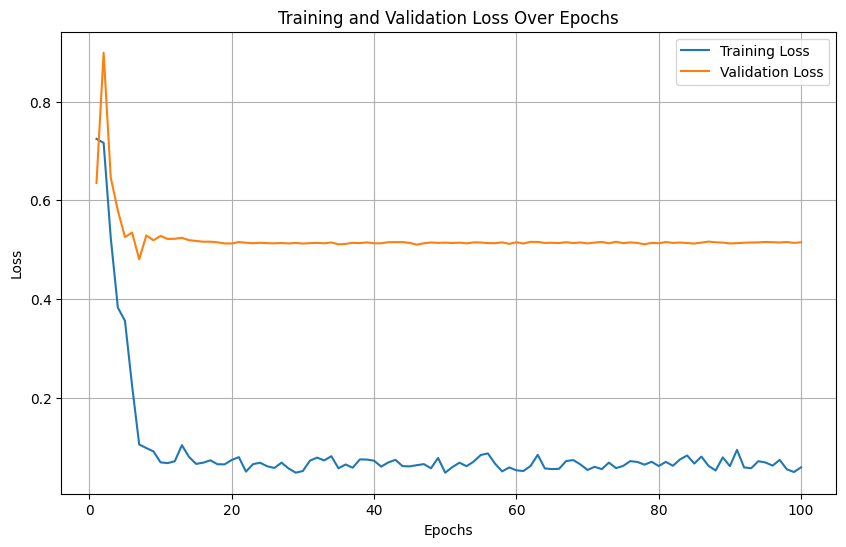

In [19]:
os.makedirs("results_100_epochs_lesion_normal/models", exist_ok=True)
save_path = "results_100_epochs_lesion_normal/models/resnet50.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Validation

### Internal test

Model weights loaded from results_100_epochs_lesion_normal/models/resnet50.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Les

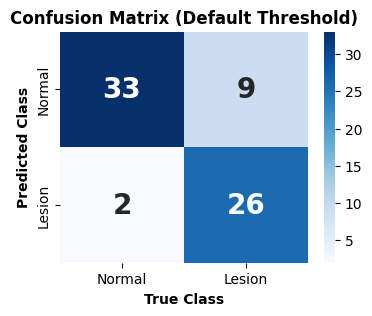


Adjusted Threshold (100% Recall): 0.0900

Adjusted Accuracy: 0.6571
Adjusted Precision: 0.5932
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7447

Adjusted Confusion Matrix:
[[11  0]
 [24 35]]


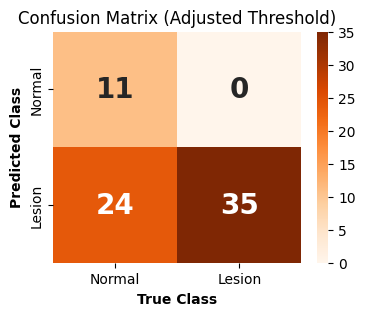

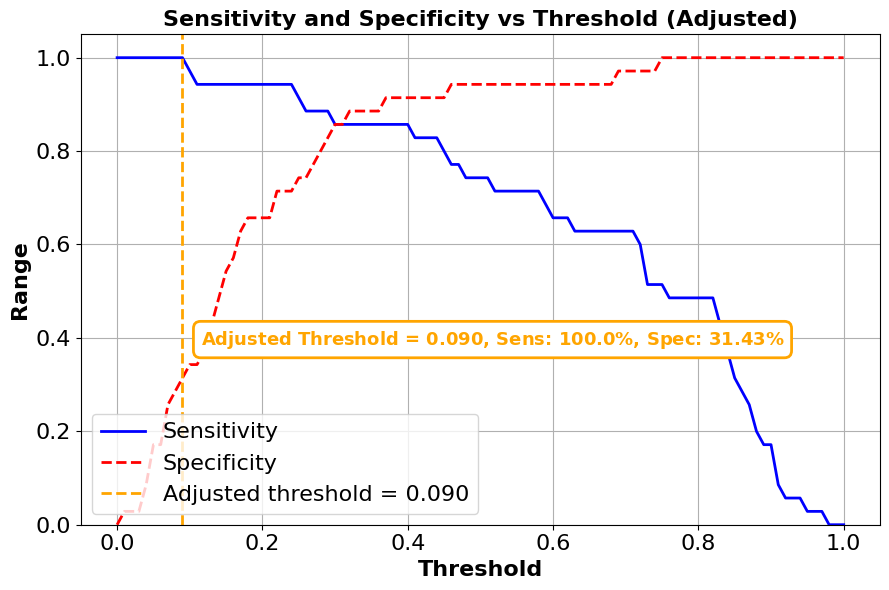


Saved ROC data to: results_100_epochs_lesion_normal/json/resnet50.json


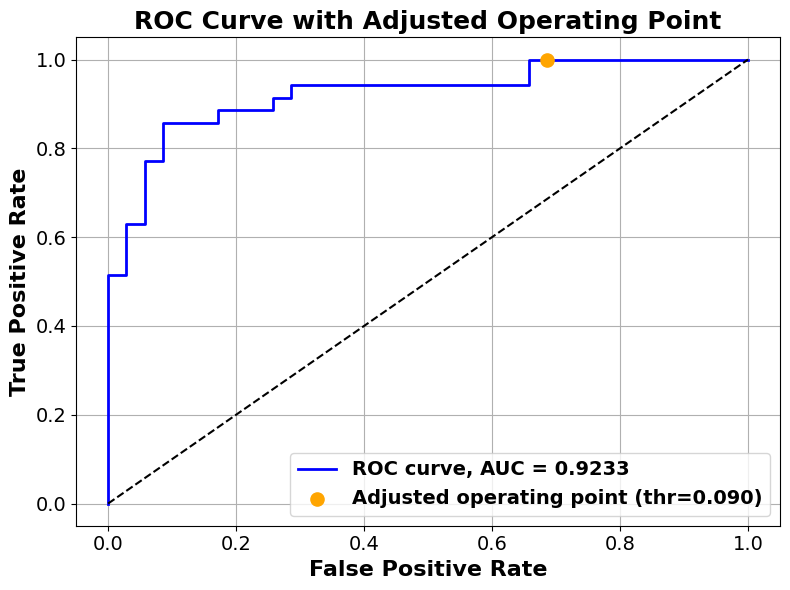

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/resnet50/


In [20]:
# Load the saved weights
model = clear_all_hooks(model)
os.makedirs("results_100_epochs_lesion_normal/internal_test/json", exist_ok=True)
weight_path = "results_100_epochs_lesion_normal/models/resnet50.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="resnet50")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1], 
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/resnet50/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/resnet50.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(De

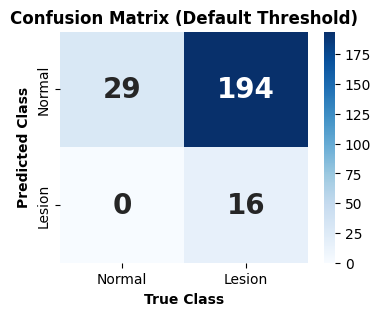


Adjusted Threshold (100% Recall): 0.0700

Adjusted Accuracy: 0.8828
Adjusted Precision: 0.8824
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9375

Adjusted Confusion Matrix:
[[  1   0]
 [ 28 210]]


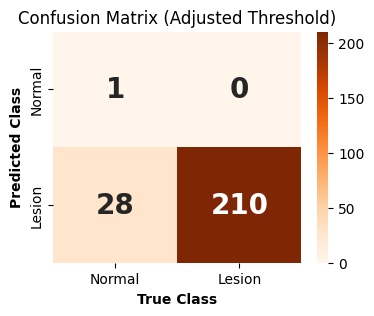

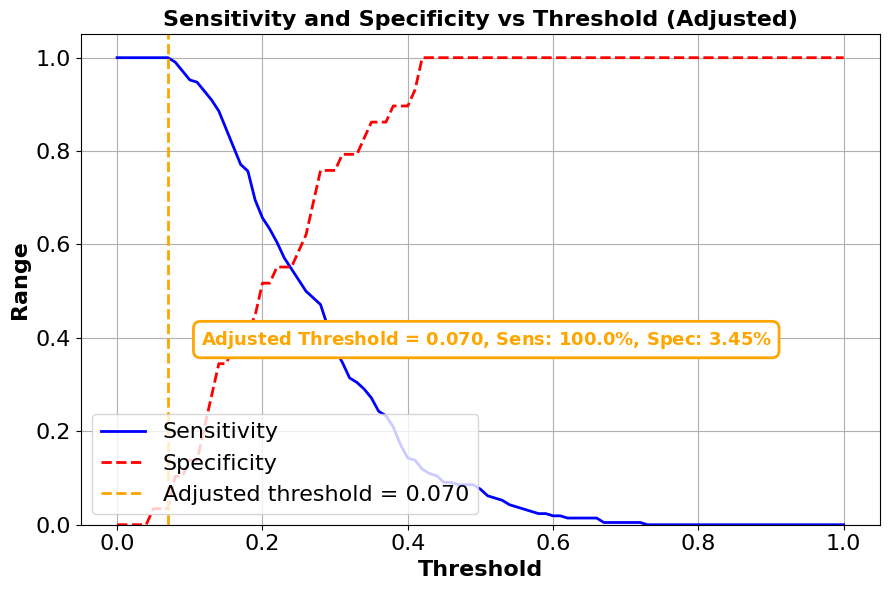


Saved ROC data to: results_100_epochs_lesion_normal/json/resnet50.json


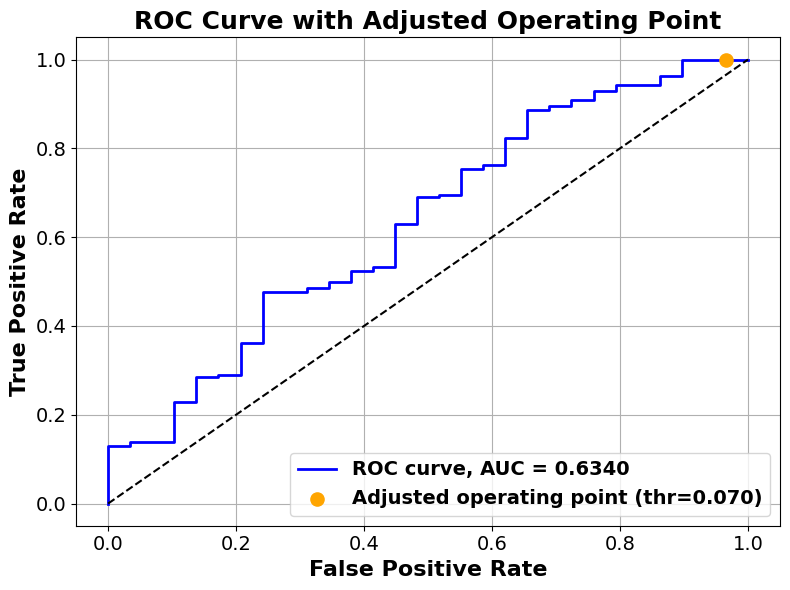

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/resnet50/


In [21]:
# Load the saved weights
model = clear_all_hooks(model)
os.makedirs("results_100_epochs_lesion_normal/external_test/json", exist_ok=True)
weight_path = "results_100_epochs_lesion_normal/models/resnet50.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="resnet50")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1], 
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/resnet50/"
)

# ResNet152

## Model

In [22]:
# Define the model
model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Define optimizer, scheduler, and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [23]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the resnet152 model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses and accuracies
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backpropagation and optimization during training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model weights
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)  # Save the best model weights
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Evaluate Function

In [24]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print Params

In [25]:
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to count model parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count and print parameters
count_parameters(model)

Total Parameters: 58,147,906
Trainable Parameters: 58,147,906
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6584 Acc: 0.6250
Val Loss: 0.6573 Acc: 0.5625
Best model weights saved to results_100_epochs_lesion_normal/models/resnet152.pth
Epoch 2/100
----------
Train Loss: 0.5842 Acc: 0.7222
Val Loss: 0.8412 Acc: 0.5781
Best model weights saved to results_100_epochs_lesion_normal/models/resnet152.pth
Epoch 3/100
----------
Train Loss: 0.5422 Acc: 0.7222
Val Loss: 0.6331 Acc: 0.6562
Best model weights saved to results_100_epochs_lesion_normal/models/resnet152.pth
Epoch 4/100
----------
Train Loss: 0.4574 Acc: 0.8125
Val Loss: 0.6227 Acc: 0.6875
Best model weights saved to results_100_epochs_lesion_normal/models/resnet152.pth
Epoch 5/100
----------
Train Loss: 0.2930 Acc: 0.9028
Val Loss: 0.6346 Acc: 0.6406
Epoch 6/100
----------
Train Loss: 0.1982 Acc: 0.9583
Val Loss: 0.6284 Acc: 0.7344
Best model weights saved to results_100_epochs_lesion_normal/models/resnet152.pth
Epoch 7/100
----------
Train Loss: 0.1363 Acc: 0.9931
Val Loss: 0.6137 Acc: 0.7188
Epoch 8/1

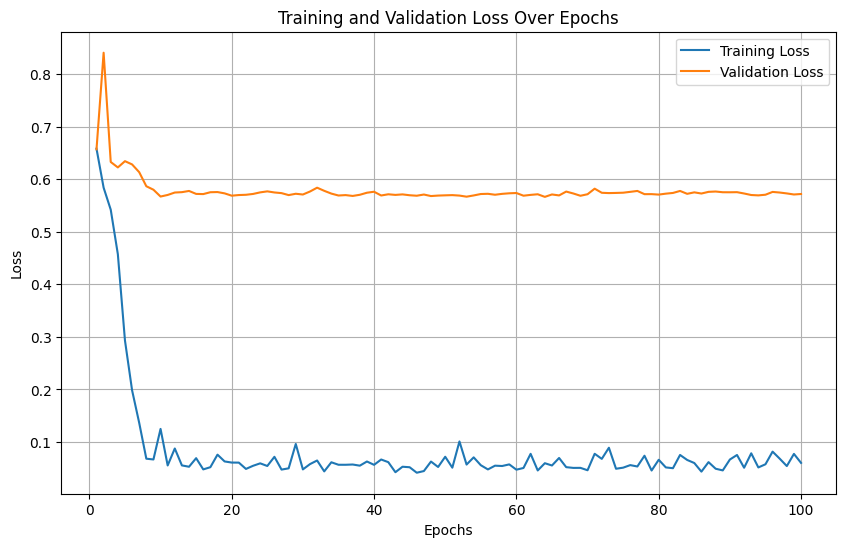

In [26]:
os.makedirs("results_100_epochs_lesion_normal/models", exist_ok=True)
save_path = "results_100_epochs_lesion_normal/models/resnet152.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Validation

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/resnet152.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Le

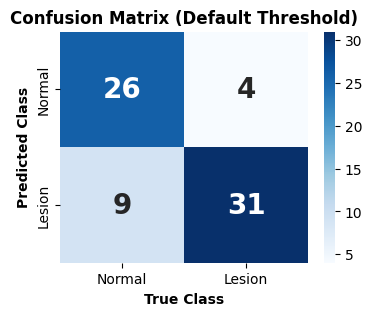


Adjusted Threshold (100% Recall): 0.1200

Adjusted Accuracy: 0.5571
Adjusted Precision: 0.5303
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.6931

Adjusted Confusion Matrix:
[[ 4  0]
 [31 35]]


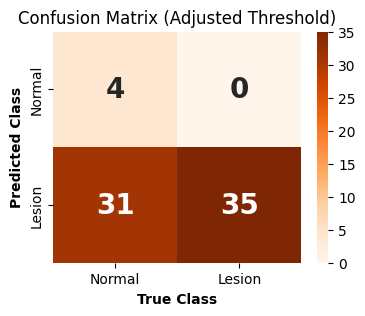

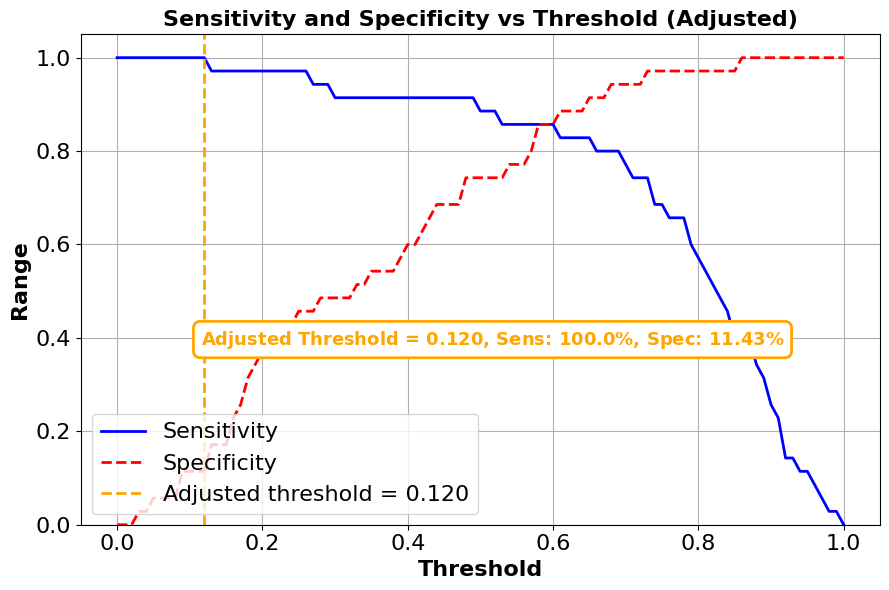


Saved ROC data to: results_100_epochs_lesion_normal/json/resnet152.json


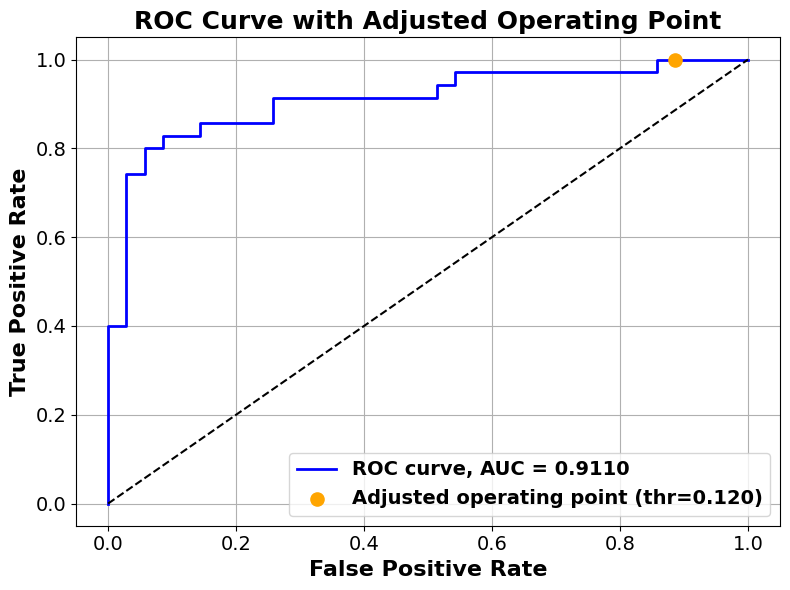

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/resnet152/


In [27]:
model = clear_all_hooks(model)
# Load the saved weights
os.makedirs("results_100_epochs_lesion_normal/internal_test/json", exist_ok=True)
weight_path = "results_100_epochs_lesion_normal/models/resnet152.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="resnet152")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/resnet152/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/resnet152.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(D

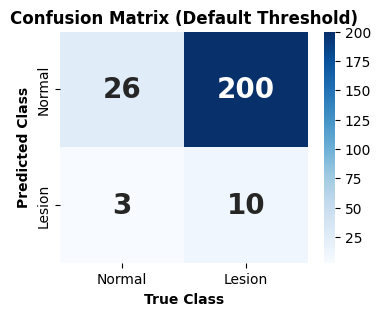


Adjusted Threshold (100% Recall): 0.0700

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


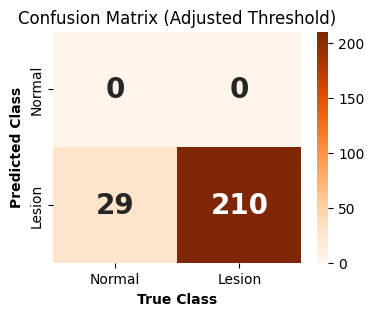

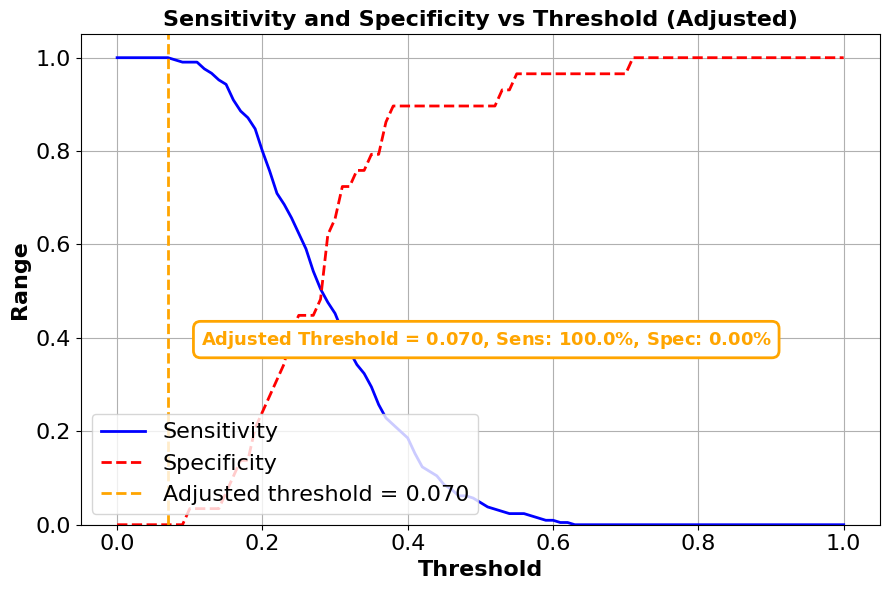


Saved ROC data to: results_100_epochs_lesion_normal/json/resnet152.json


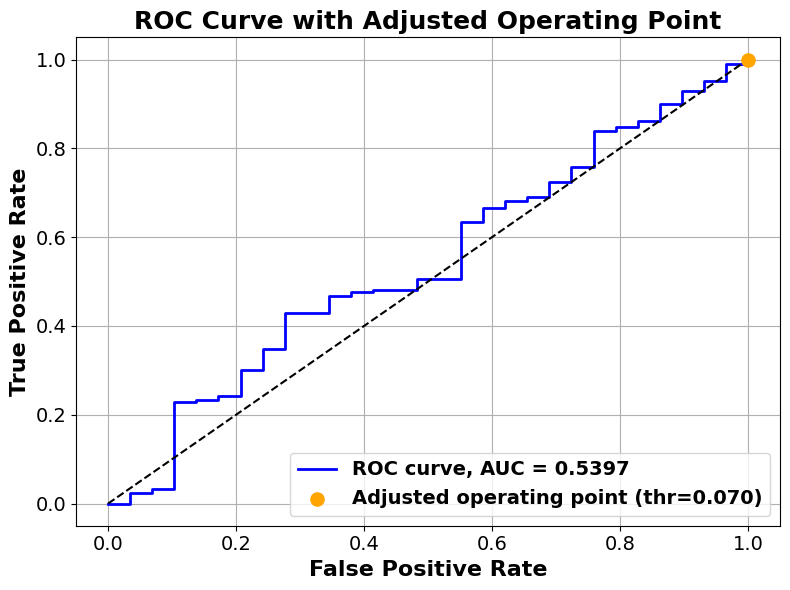

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/resnet152/


In [28]:
model = clear_all_hooks(model)
# Load the saved weights
os.makedirs("results_100_epochs_lesion_normal/external_test/json", exist_ok=True)
weight_path = "results_100_epochs_lesion_normal/models/resnet152.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="resnet152")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/resnet152/"
)

# Inception_v3

## Model

In [29]:
# Define the model
model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Define optimizer, scheduler, and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [30]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=200, is_inception=False, save_path="best_model.pth"):
    """
    Trains the model and evaluates it at each epoch.
    Supports both regular models and Inception V3 with auxiliary outputs.
    Saves the best model weights to a file.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0


    # Track losses and accuracies
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == "train"):
                    if is_inception and phase == "train":
                        # Inception V3 requires special handling for training due to auxiliary outputs
                        outputs = model(inputs)
                        logits = outputs.logits
                        aux_logits = outputs.aux_logits

                        _, preds = torch.max(logits, 1)
                        loss1 = criterion(logits, labels)
                        loss2 = criterion(aux_logits, labels)
                        loss = loss1 + 0.4 * loss2  # Weighted sum of main and auxiliary losses
                    else:
                        # Standard forward pass
                        outputs = model(inputs)
                        if isinstance(outputs, tuple):  # Handle cases like Inception V3 in eval mode
                            outputs = outputs.logits
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                # Calculate epoch loss and accuracy
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())
                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Save the best model
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)  # Save the best model weights
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()
    return model




## Evaluate Function

In [31]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [32]:


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 25,116,362
Trainable Parameters: 25,116,362
Non-Trainable Parameters: 0


## Train

Training the model...
Epoch 1/100
----------
train Loss: 3.6072 Acc: 0.5000
val Loss: 0.6708 Acc: 0.5625
Best model weights saved to results_100_epochs_lesion_normal/models/inception_v3.pth
Epoch 2/100
----------
train Loss: 1.9355 Acc: 0.6458
val Loss: 0.6399 Acc: 0.7188
Best model weights saved to results_100_epochs_lesion_normal/models/inception_v3.pth
Epoch 3/100
----------
train Loss: 1.0744 Acc: 0.7708
val Loss: 0.5886 Acc: 0.7031
Epoch 4/100
----------
train Loss: 0.6213 Acc: 0.7847
val Loss: 0.5684 Acc: 0.6875
Epoch 5/100
----------
train Loss: 0.4410 Acc: 0.8819
val Loss: 0.5245 Acc: 0.7656
Best model weights saved to results_100_epochs_lesion_normal/models/inception_v3.pth
Epoch 6/100
----------
train Loss: 0.2419 Acc: 0.9861
val Loss: 0.5298 Acc: 0.7188
Epoch 7/100
----------
train Loss: 0.1423 Acc: 1.0000
val Loss: 0.4770 Acc: 0.7188
Epoch 8/100
----------
train Loss: 0.1332 Acc: 0.9931
val Loss: 0.4661 Acc: 0.7500
Epoch 9/100
----------
train Loss: 0.1107 Acc: 0.9931
val L

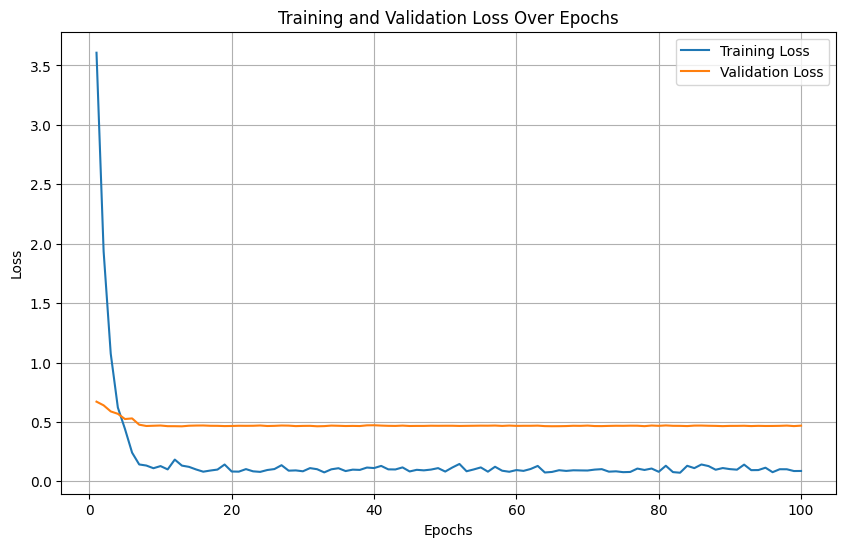

In [33]:
save_path = "results_100_epochs_lesion_normal/models/inception_v3.pth"

print("Training the model...")
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    is_inception=True,
    save_path=save_path  
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/inception_v3.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual =

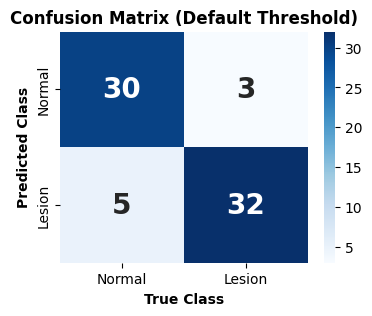


Adjusted Threshold (100% Recall): 0.2400

Adjusted Accuracy: 0.6857
Adjusted Precision: 0.6140
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7609

Adjusted Confusion Matrix:
[[13  0]
 [22 35]]


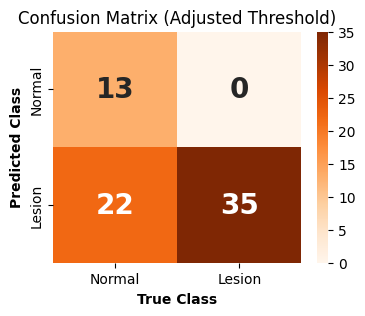

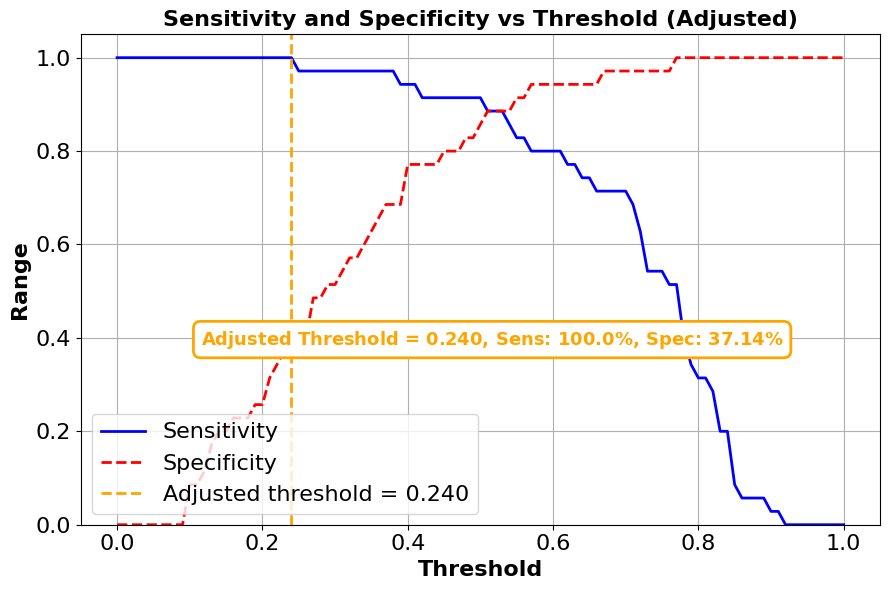


Saved ROC data to: results_100_epochs_lesion_normal/json/inception_v3.json


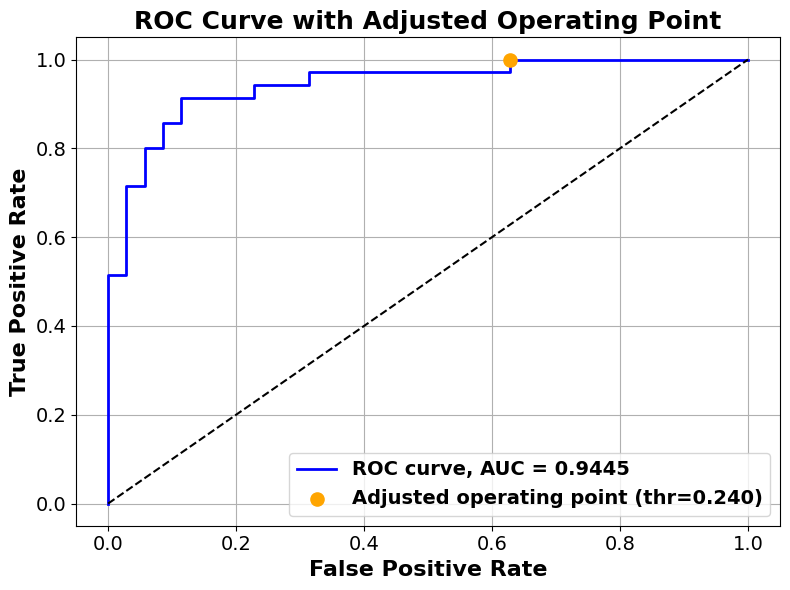

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/inception_v3/


In [34]:
model = clear_all_hooks(model)
# Load the saved weights
os.makedirs("results_100_epochs_lesion_normal/internal_test/json", exist_ok=True)
weight_path = "results_100_epochs_lesion_normal/models/inception_v3.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="inception_v3")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.Mixed_7c,  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/inception_v3/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/inception_v3.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pre

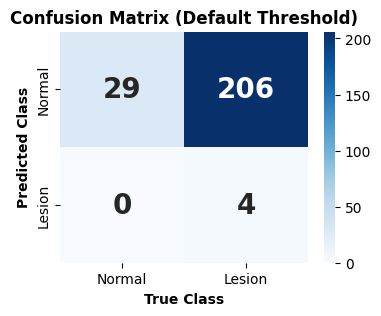


Adjusted Threshold (100% Recall): 0.1500

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


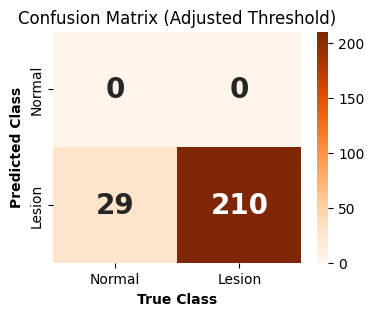

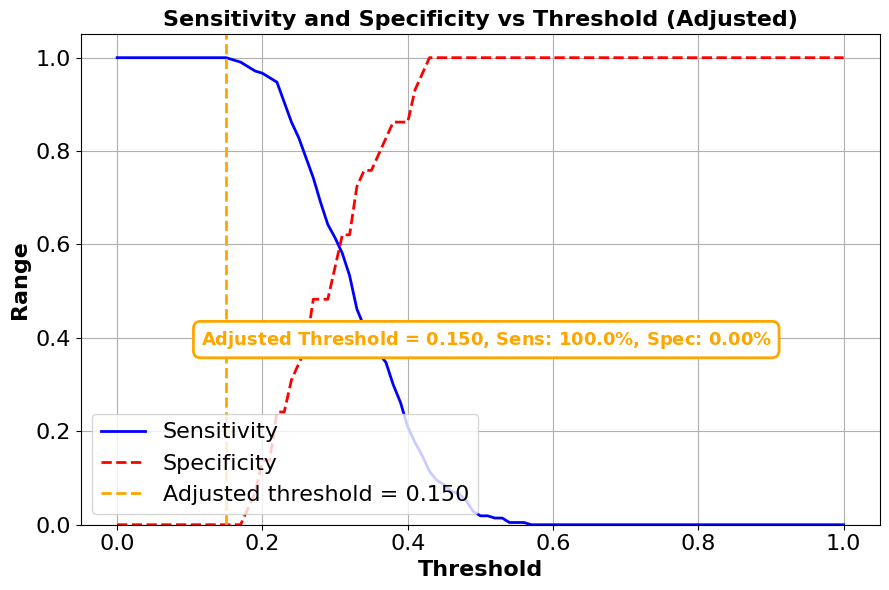


Saved ROC data to: results_100_epochs_lesion_normal/json/inception_v3.json


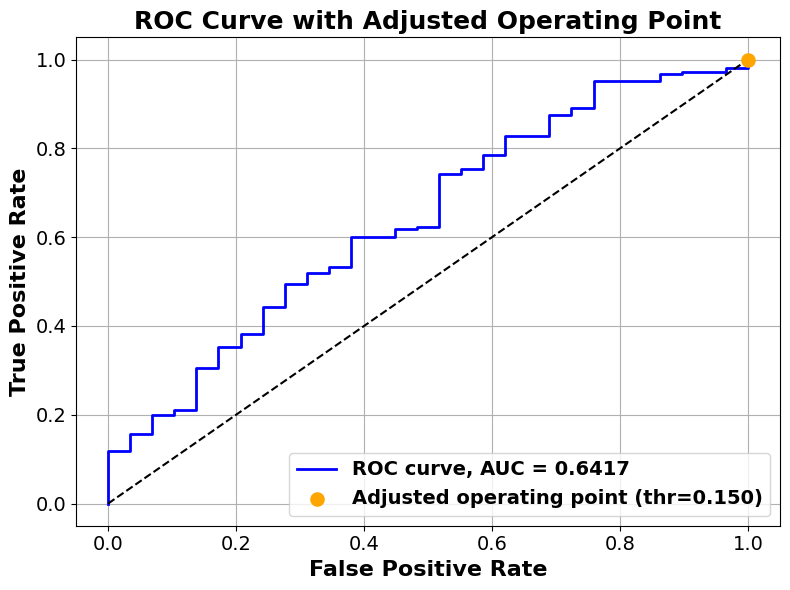

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/inception_v3/


In [35]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/inception_v3.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="inception_v3")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.Mixed_7c,  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/inception_v3/"
)

# AlexNet

## Model

In [36]:
# Load AlexNet and update the classifier
model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

# Update the final layer for your number of classes
num_ftrs = model.classifier[6].in_features
model.classifier[6] = torch.nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Define the criterion, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [37]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the AlexNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path.
    Visualizes the training and validation loss and accuracy.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track loss and accuracy
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            # Save the best model weights
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize the training and validation loss and accuracy
    plt.figure(figsize=(10, 6))

    # Plot Loss
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()



    plt.tight_layout()
    plt.show()

    return model


## Eval Function

In [38]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [39]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 57,012,034
Trainable Parameters: 57,012,034
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.8035 Acc: 0.5972
Val Loss: 0.6811 Acc: 0.7031
Best model weights saved to results_100_epochs_lesion_normal/models/alexnet.pth
Epoch 2/100
----------
Train Loss: 0.6125 Acc: 0.6458
Val Loss: 0.6233 Acc: 0.6719
Epoch 3/100
----------
Train Loss: 0.6594 Acc: 0.7153
Val Loss: 0.6766 Acc: 0.5625
Epoch 4/100
----------
Train Loss: 0.6363 Acc: 0.6042
Val Loss: 0.6146 Acc: 0.6562
Epoch 5/100
----------
Train Loss: 0.5704 Acc: 0.7431
Val Loss: 0.5966 Acc: 0.7031
Epoch 6/100
----------
Train Loss: 0.5419 Acc: 0.7361
Val Loss: 0.4949 Acc: 0.7812
Best model weights saved to results_100_epochs_lesion_normal/models/alexnet.pth
Epoch 7/100
----------
Train Loss: 0.4810 Acc: 0.7708
Val Loss: 0.4462 Acc: 0.7969
Best model weights saved to results_100_epochs_lesion_normal/models/alexnet.pth
Epoch 8/100
----------
Train Loss: 0.3818 Acc: 0.8472
Val Loss: 0.4387 Acc: 0.7969
Epoch 9/100
----------
Train Loss: 0.3881 Acc: 0.8333
Val Loss: 0.4371 Acc: 0.8281
Best model we

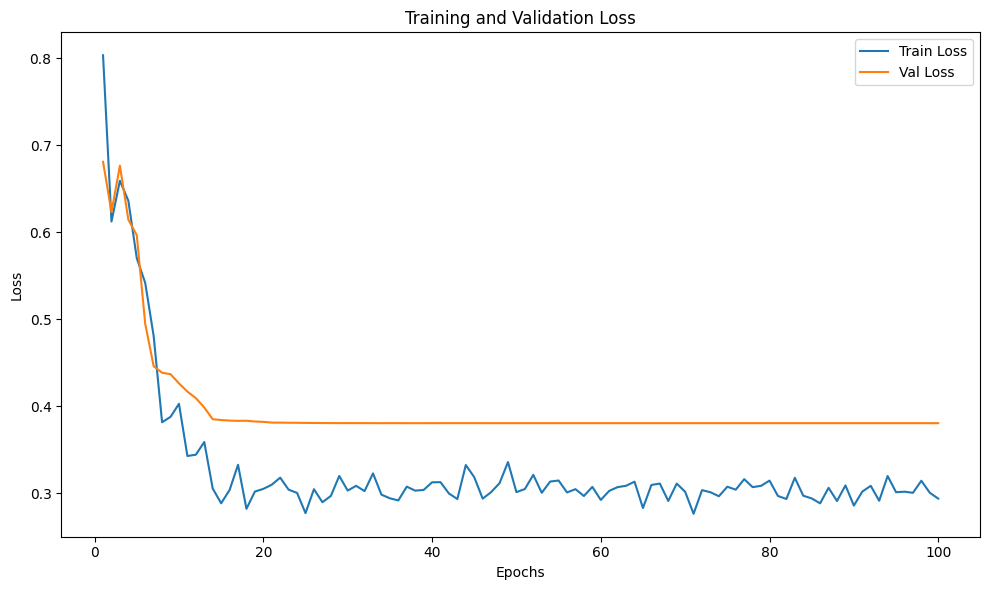

In [40]:
save_path = "results_100_epochs_lesion_normal/models/alexnet.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/alexnet.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesi

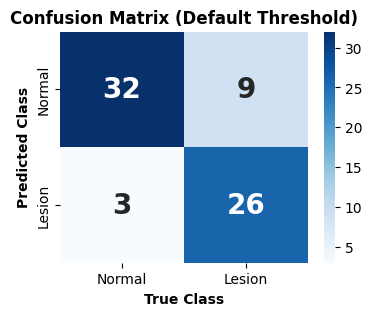


Adjusted Threshold (100% Recall): 0.2000

Adjusted Accuracy: 0.8143
Adjusted Precision: 0.7292
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.8434

Adjusted Confusion Matrix:
[[22  0]
 [13 35]]


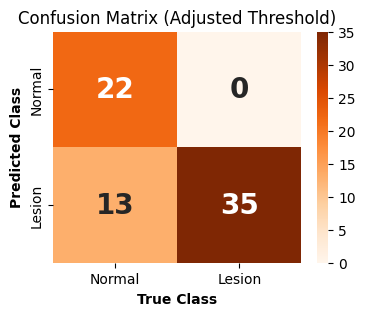

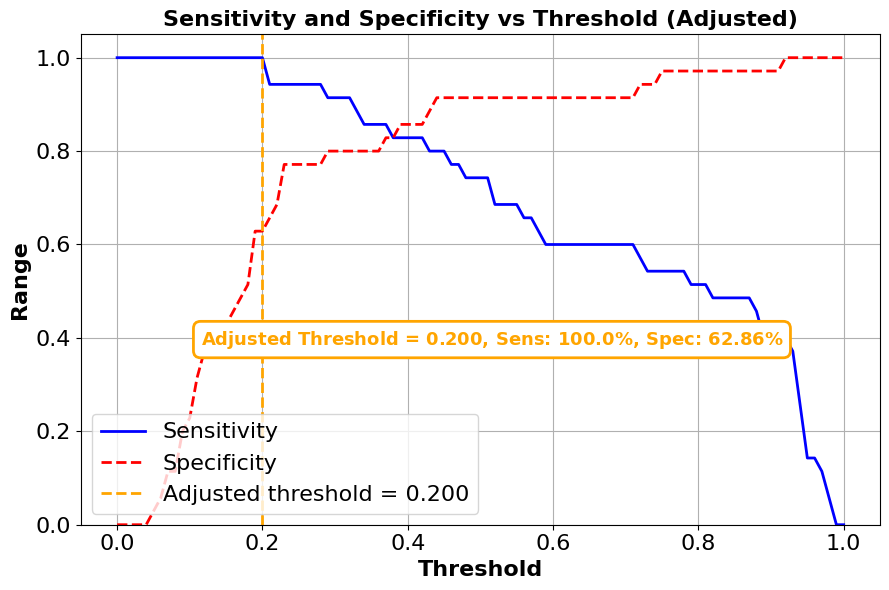


Saved ROC data to: results_100_epochs_lesion_normal/json/alexnet.json


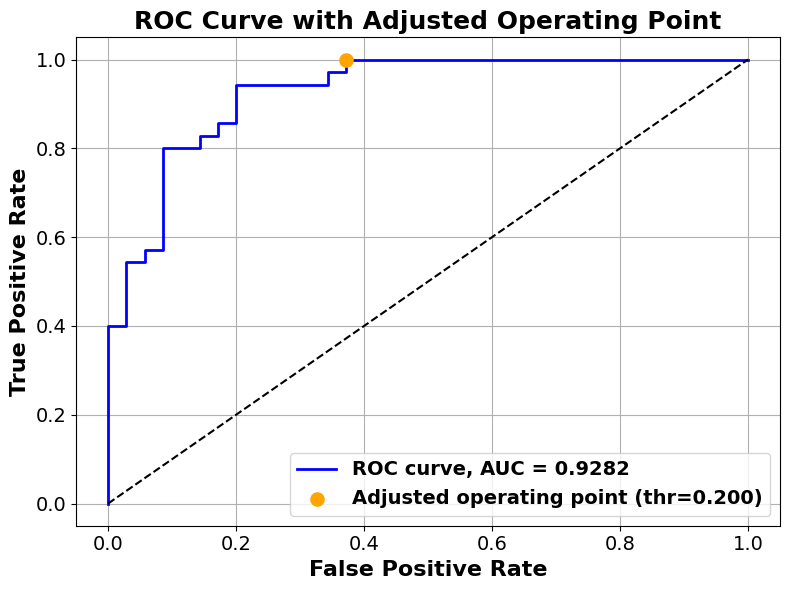

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/alexnet/


In [41]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/alexnet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="alexnet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features[-1], 
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/alexnet/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/alexnet.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(Def

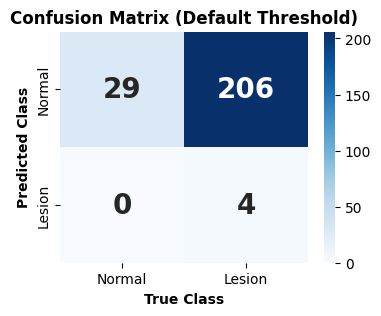


Adjusted Threshold (100% Recall): 0.0700

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


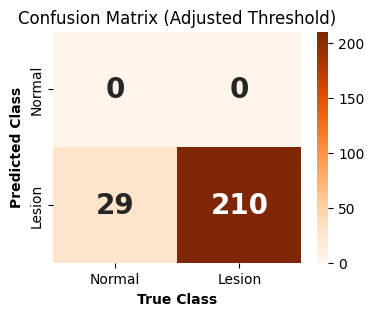

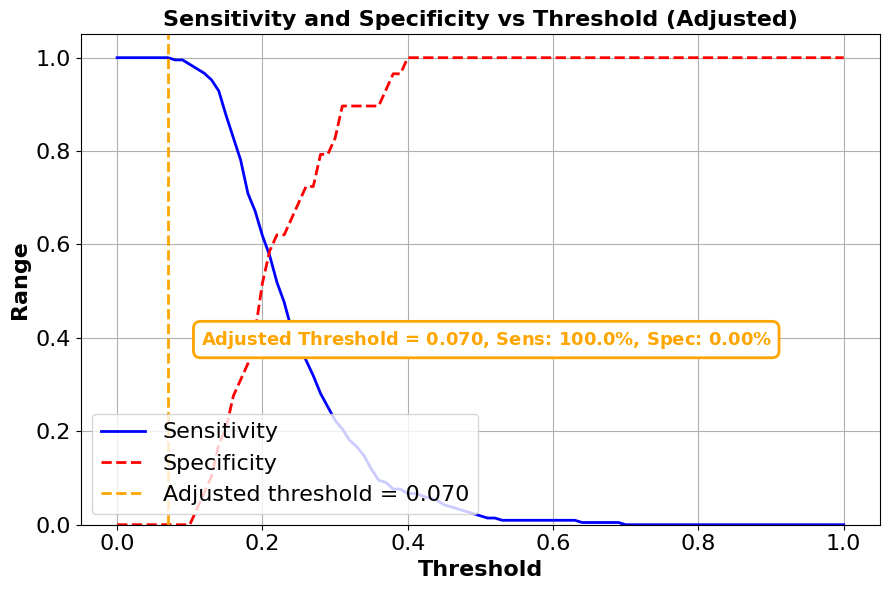


Saved ROC data to: results_100_epochs_lesion_normal/json/alexnet.json


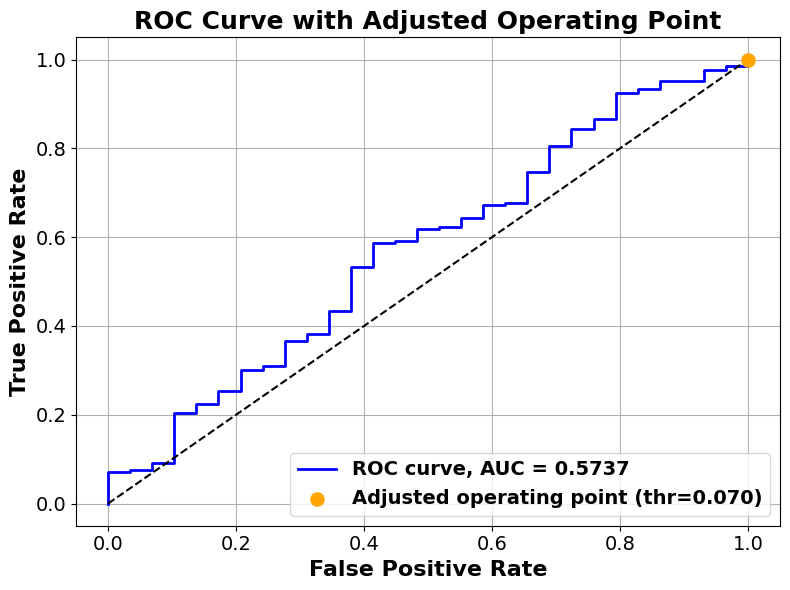

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/alexnet/


In [42]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/alexnet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="alexnet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/alexnet/"
)

# DenseNet

## Model

In [43]:
# Define the model

model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_ftrs = model.classifier.in_features  # DenseNet uses 'classifier' instead of 'fc'
model.classifier = torch.nn.Linear(num_ftrs, len(class_names))  # Replace the classifier
model = model.to(device)

# Define optimizer, scheduler, and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [44]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the DenseNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path.
    Visualizes training and validation loss over epochs.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over the data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimization (training phase only)
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # Update statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Step scheduler at the end of the training phase
            if phase == "train":
                scheduler.step()

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses
            if phase == "train":
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            # Save the best model weights during validation
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    # Training summary
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [45]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [46]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 6,955,906
Trainable Parameters: 6,955,906
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6388 Acc: 0.6667
Val Loss: 0.6527 Acc: 0.5625
Best model weights saved to results_100_epochs_lesion_normal/models/densenet.pth
Epoch 2/100
----------
Train Loss: 0.5328 Acc: 0.7361
Val Loss: 0.6203 Acc: 0.6406
Best model weights saved to results_100_epochs_lesion_normal/models/densenet.pth
Epoch 3/100
----------
Train Loss: 0.4087 Acc: 0.8403
Val Loss: 0.5552 Acc: 0.7031
Best model weights saved to results_100_epochs_lesion_normal/models/densenet.pth
Epoch 4/100
----------
Train Loss: 0.2882 Acc: 0.9167
Val Loss: 0.5398 Acc: 0.7188
Best model weights saved to results_100_epochs_lesion_normal/models/densenet.pth
Epoch 5/100
----------
Train Loss: 0.1959 Acc: 0.9653
Val Loss: 0.5173 Acc: 0.7031
Epoch 6/100
----------
Train Loss: 0.1210 Acc: 0.9931
Val Loss: 0.5820 Acc: 0.6875
Epoch 7/100
----------
Train Loss: 0.0616 Acc: 1.0000
Val Loss: 0.6148 Acc: 0.7031
Epoch 8/100
----------
Train Loss: 0.0465 Acc: 1.0000
Val Loss: 0.6101 Acc: 0.7188
Epoch 9/100


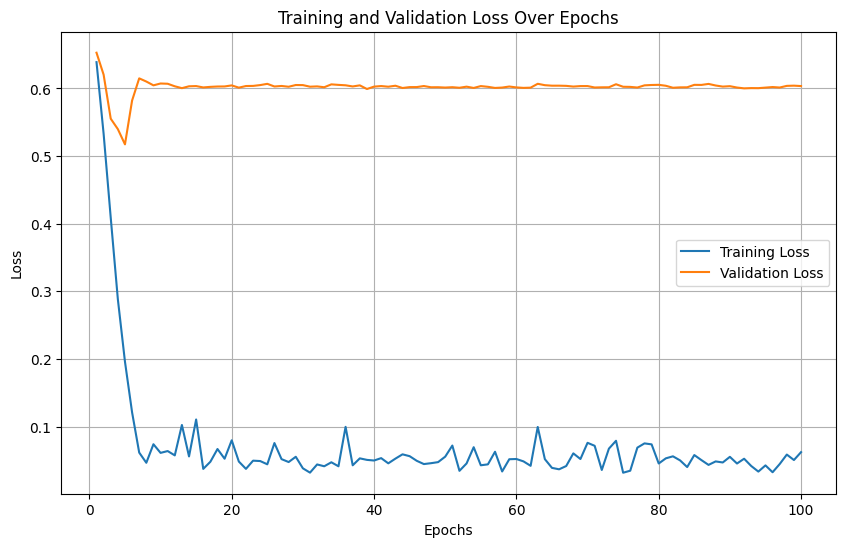

In [47]:
save_path = "results_100_epochs_lesion_normal/models/densenet.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/densenet.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Les

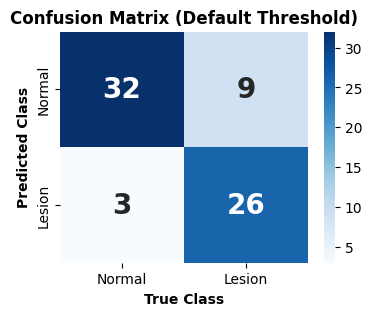


Adjusted Threshold (100% Recall): 0.0900

Adjusted Accuracy: 0.6286
Adjusted Precision: 0.5738
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7292

Adjusted Confusion Matrix:
[[ 9  0]
 [26 35]]


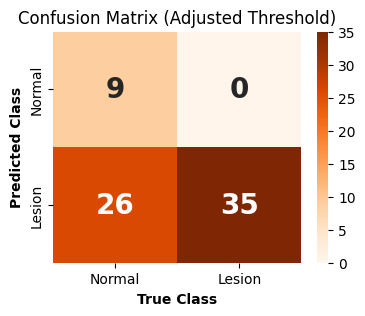

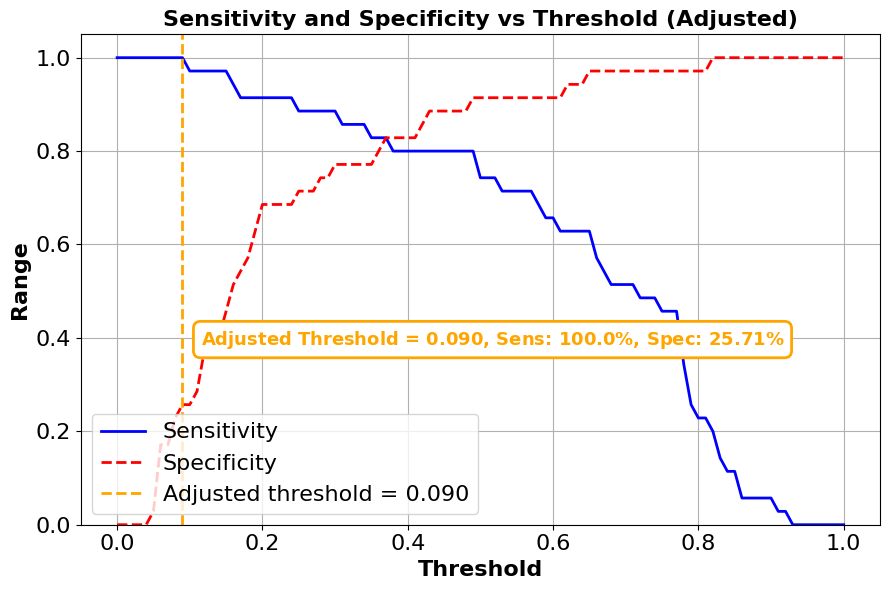


Saved ROC data to: results_100_epochs_lesion_normal/json/densenet.json


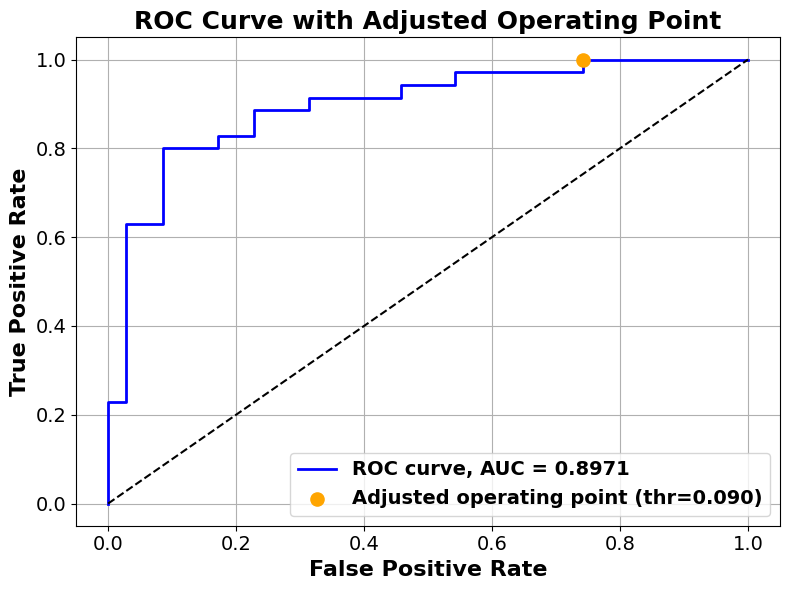

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/densenet/


In [48]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/densenet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="densenet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features.denseblock4, 
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/densenet/"
)

### Exnternal Test

Model weights loaded from results_100_epochs_lesion_normal/models/densenet.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(De

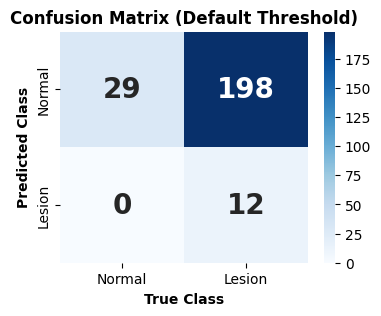


Adjusted Threshold (100% Recall): 0.1600

Adjusted Accuracy: 0.8828
Adjusted Precision: 0.8824
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9375

Adjusted Confusion Matrix:
[[  1   0]
 [ 28 210]]


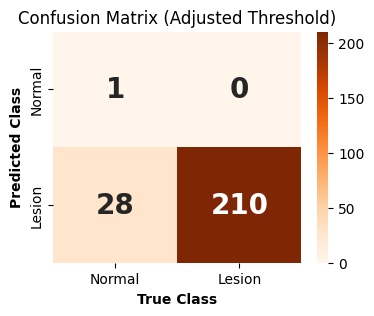

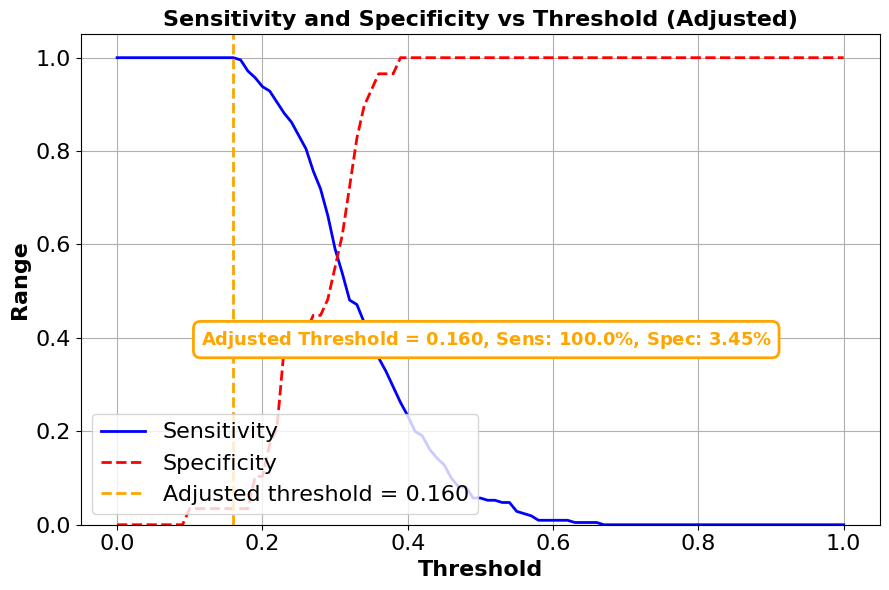


Saved ROC data to: results_100_epochs_lesion_normal/json/densenet.json


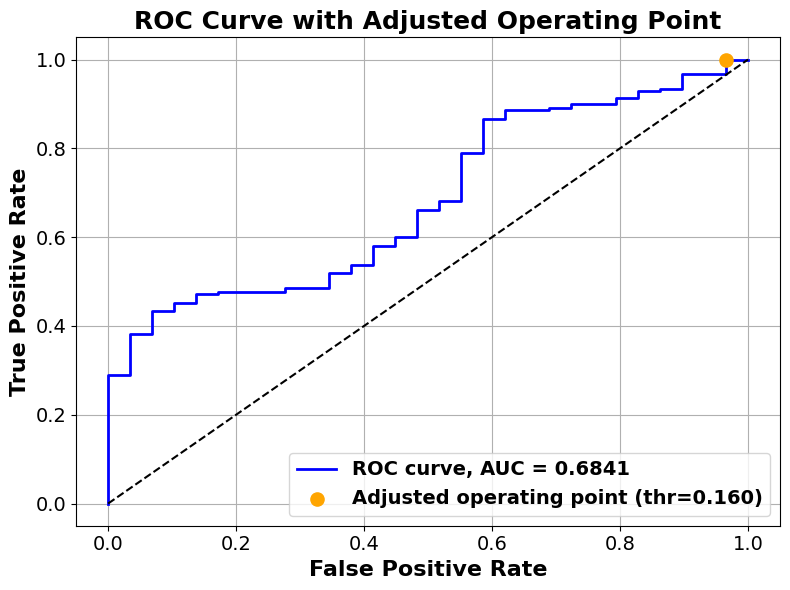

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/densenet/


In [49]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/densenet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="densenet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features.denseblock4,  
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/densenet/"
)

# SqueezeNet

## Model

In [50]:

model = squeezenet1_1(weights=SqueezeNet1_1_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_classes = len(class_names)  # Number of output classes
model.classifier[1] = torch.nn.Conv2d(512, num_classes, kernel_size=1)  # Replace Conv2d layer
model.num_classes = num_classes  # Update num_classes

# Move model to device
model = model.to(device)

# Define optimizer, scheduler, and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [51]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the SqueezeNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path.
    Visualizes training and validation loss over epochs.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over the data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    outputs = outputs.squeeze(-1).squeeze(-1)  # Remove extra dimensions (for Conv2d output)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimization (training phase only)
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # Update statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Step scheduler at the end of the training phase
            if phase == "train":
                scheduler.step()

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses
            if phase == "train":
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            # Save the best model weights during validation
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    # Training summary
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [52]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [53]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 723,522
Trainable Parameters: 723,522
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.7034 Acc: 0.6250
Val Loss: 0.6440 Acc: 0.6562
Best model weights saved to results_100_epochs_lesion_normal/models/squeezenet.pth
Epoch 2/100
----------
Train Loss: 0.5898 Acc: 0.7014
Val Loss: 0.6354 Acc: 0.6562
Epoch 3/100
----------
Train Loss: 0.5562 Acc: 0.7361
Val Loss: 0.6260 Acc: 0.6562
Epoch 4/100
----------
Train Loss: 0.5075 Acc: 0.7708
Val Loss: 0.6687 Acc: 0.6562
Epoch 5/100
----------
Train Loss: 0.5062 Acc: 0.7292
Val Loss: 0.6548 Acc: 0.6406
Epoch 6/100
----------
Train Loss: 0.4759 Acc: 0.7847
Val Loss: 0.6427 Acc: 0.6875
Best model weights saved to results_100_epochs_lesion_normal/models/squeezenet.pth
Epoch 7/100
----------
Train Loss: 0.4461 Acc: 0.7778
Val Loss: 0.6448 Acc: 0.6719
Epoch 8/100
----------
Train Loss: 0.3785 Acc: 0.8264
Val Loss: 0.6159 Acc: 0.7031
Best model weights saved to results_100_epochs_lesion_normal/models/squeezenet.pth
Epoch 9/100
----------
Train Loss: 0.3682 Acc: 0.8333
Val Loss: 0.6223 Acc: 0.6875
Epoc

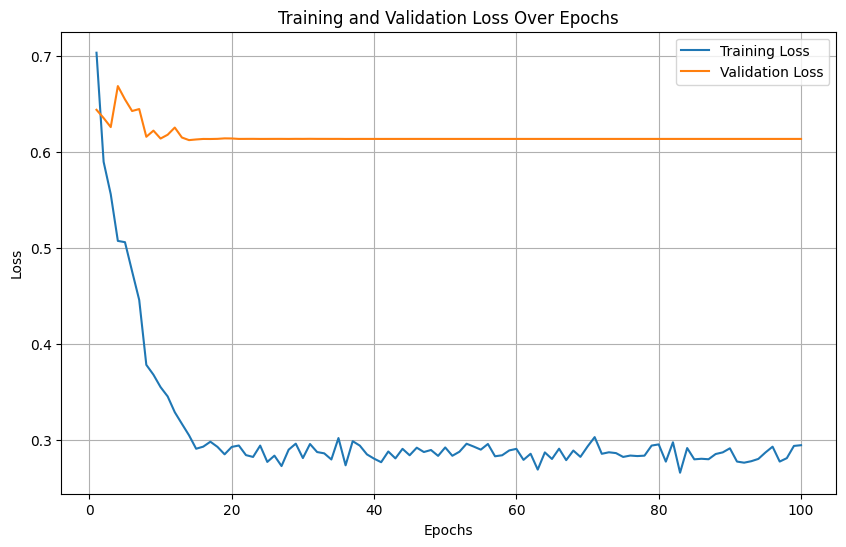

In [54]:
save_path = "results_100_epochs_lesion_normal/models/squeezenet.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/squeezenet.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = L

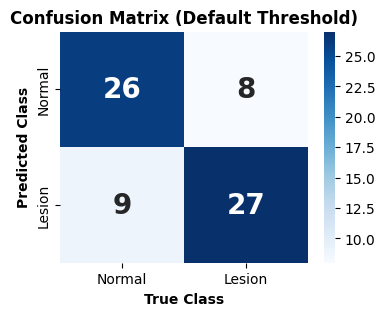


Adjusted Threshold (100% Recall): 0.0300

Adjusted Accuracy: 0.5429
Adjusted Precision: 0.5224
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.6863

Adjusted Confusion Matrix:
[[ 3  0]
 [32 35]]


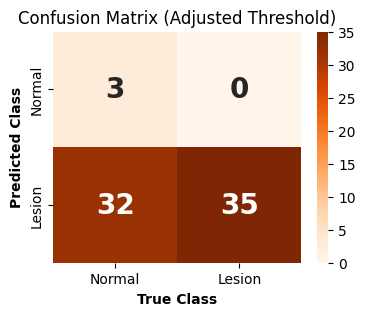

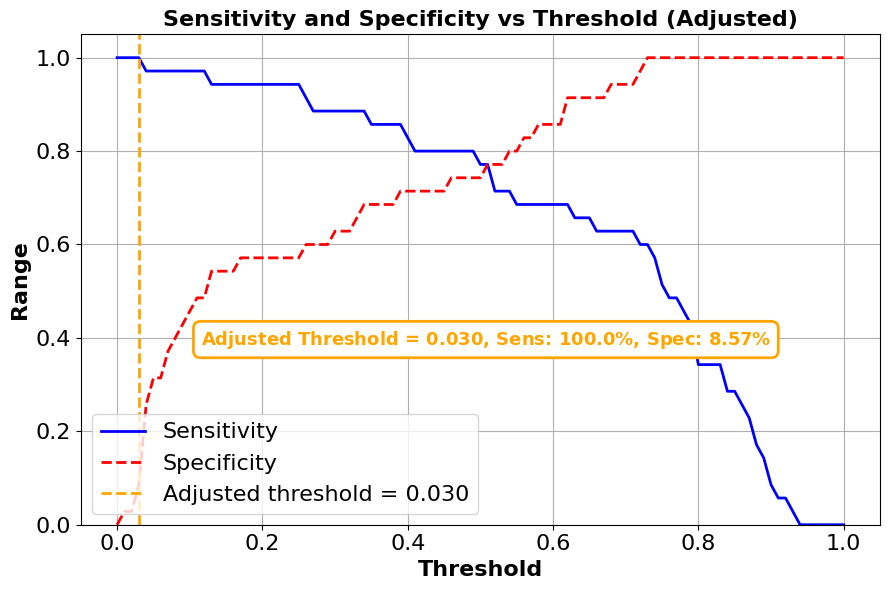


Saved ROC data to: results_100_epochs_lesion_normal/json/squeezenet.json


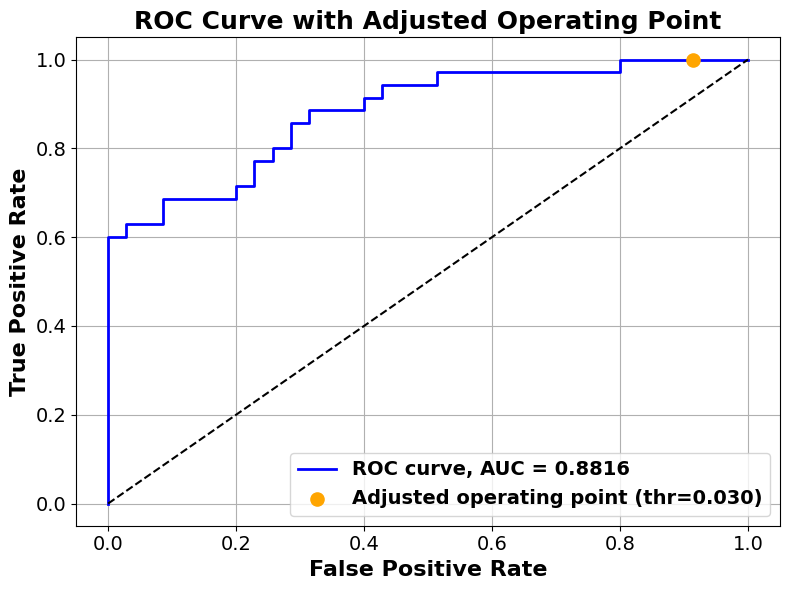

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/squeezenet/


In [55]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/squeezenet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="squeezenet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/squeezenet/"
)

### Exnternal Test

Model weights loaded from results_100_epochs_lesion_normal/models/squeezenet.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(

/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


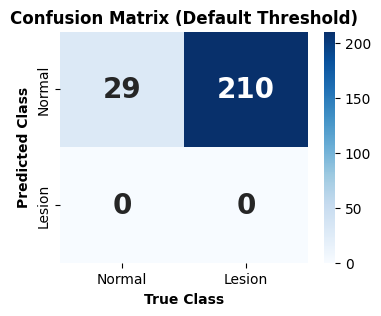


Adjusted Threshold (100% Recall): 0.0100

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


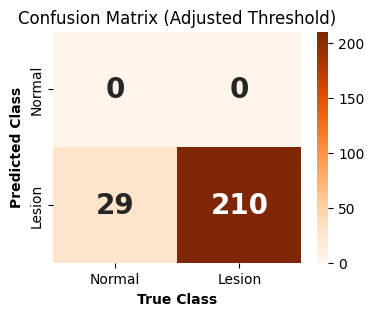

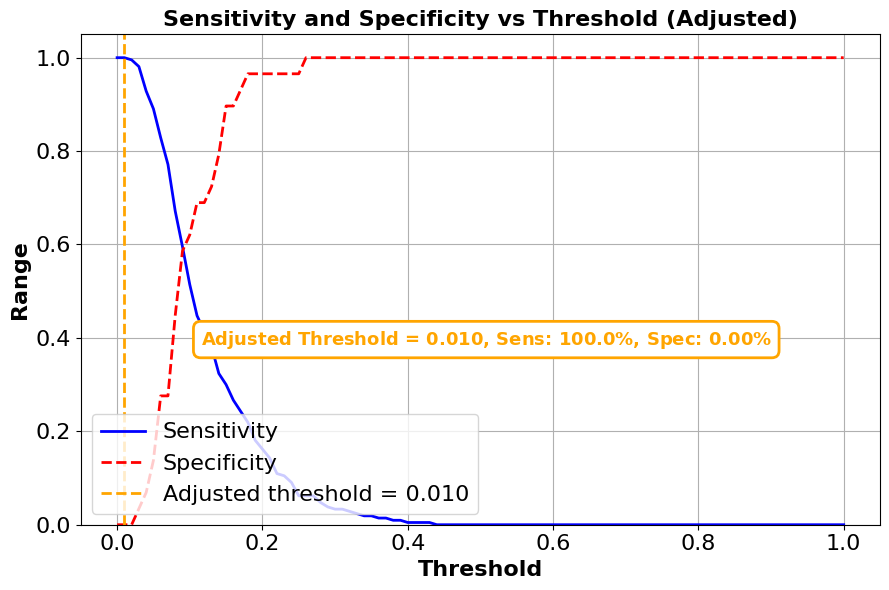


Saved ROC data to: results_100_epochs_lesion_normal/json/squeezenet.json


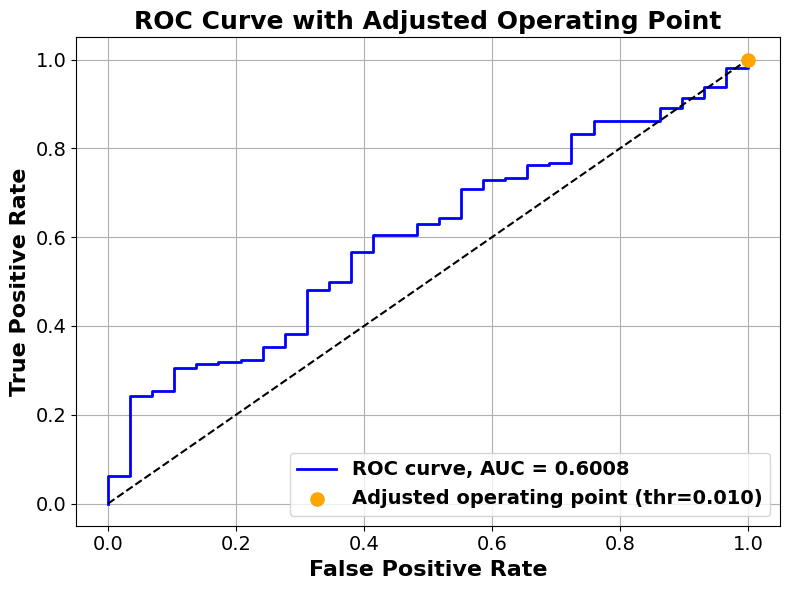

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/squeezenet/


In [56]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/squeezenet.pth"
model = load_model_weights(model, weight_path, device)

# Evaluate the loaded model
print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="squeezenet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.features[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/squeezenet/"
)

# WideResnet50

## Model

In [57]:
model = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1)  # Initialize WideResNet-50-2 without pretrained weights

# Update the final classification layer
num_classes = len(class_names)  # Number of output classes
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))  # Replace with the number of output classes

# Move the model to the specified device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [58]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the WideResNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes training and validation loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # WideResNet forward pass
                    _, preds = torch.max(outputs, 1)  # Get predicted classes
                    loss = criterion(outputs, labels)  # Compute loss

                    # Backward pass and optimization in training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model based on validation accuracy
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [59]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [60]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 66,838,338
Trainable Parameters: 66,838,338
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6817 Acc: 0.5972
Val Loss: 0.6607 Acc: 0.5781
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet50.pth
Epoch 2/100
----------
Train Loss: 0.5812 Acc: 0.6736
Val Loss: 0.6266 Acc: 0.5938
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet50.pth
Epoch 3/100
----------
Train Loss: 0.4911 Acc: 0.7778
Val Loss: 0.5918 Acc: 0.6875
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet50.pth
Epoch 4/100
----------
Train Loss: 0.4454 Acc: 0.8056
Val Loss: 0.5994 Acc: 0.6406
Epoch 5/100
----------
Train Loss: 0.3405 Acc: 0.8681
Val Loss: 0.5309 Acc: 0.7344
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet50.pth
Epoch 6/100
----------
Train Loss: 0.2416 Acc: 0.9583
Val Loss: 0.5589 Acc: 0.6719
Epoch 7/100
----------
Train Loss: 0.1466 Acc: 0.9931
Val Loss: 0.5552 Acc: 0.7500
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet5

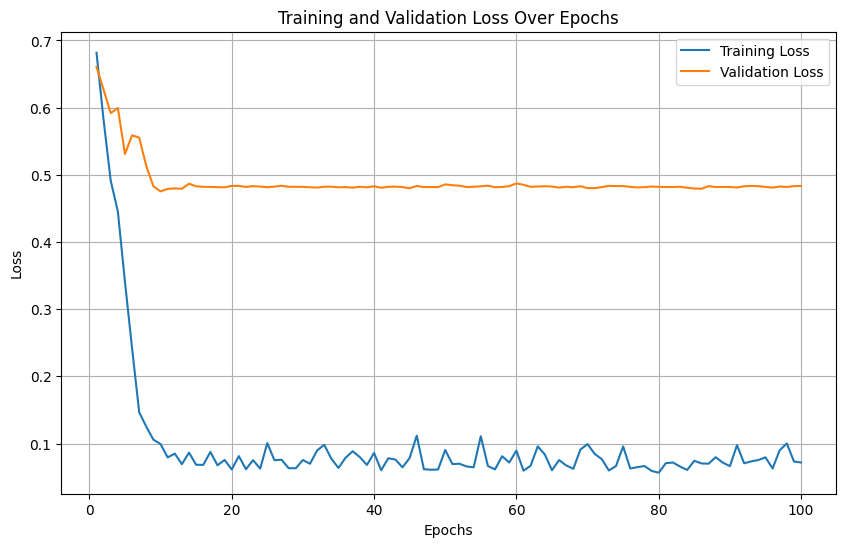

In [61]:
save_path = "results_100_epochs_lesion_normal/models/wideresnet50.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/wideresnet50.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual =

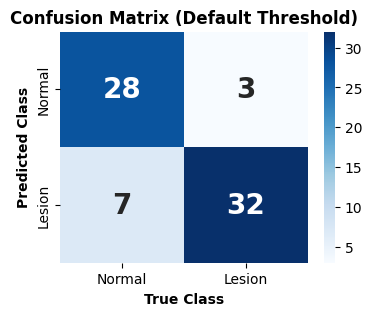


Adjusted Threshold (100% Recall): 0.3000

Adjusted Accuracy: 0.7429
Adjusted Precision: 0.6604
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7955

Adjusted Confusion Matrix:
[[17  0]
 [18 35]]


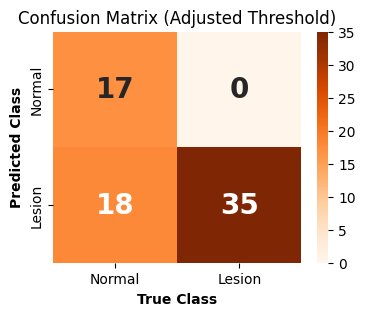

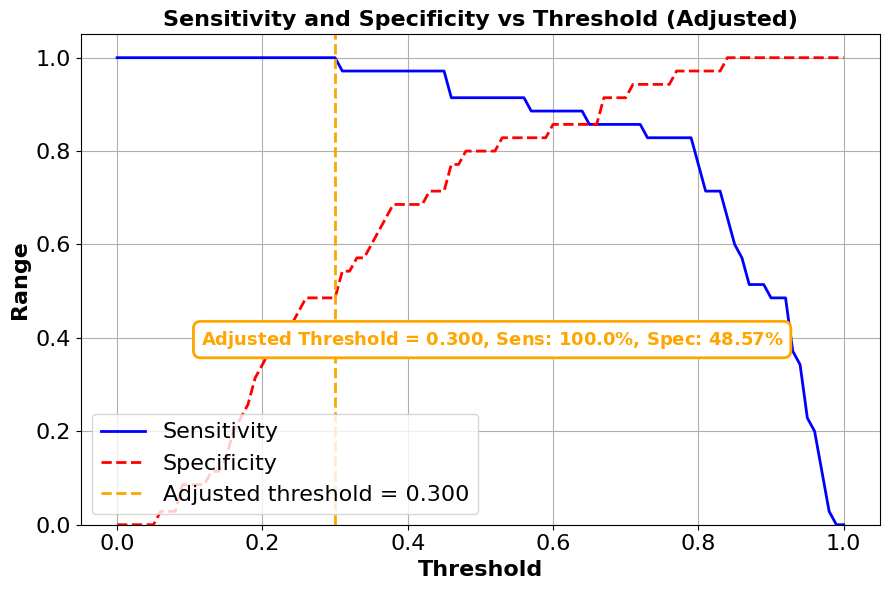


Saved ROC data to: results_100_epochs_lesion_normal/json/wideresnet50.json


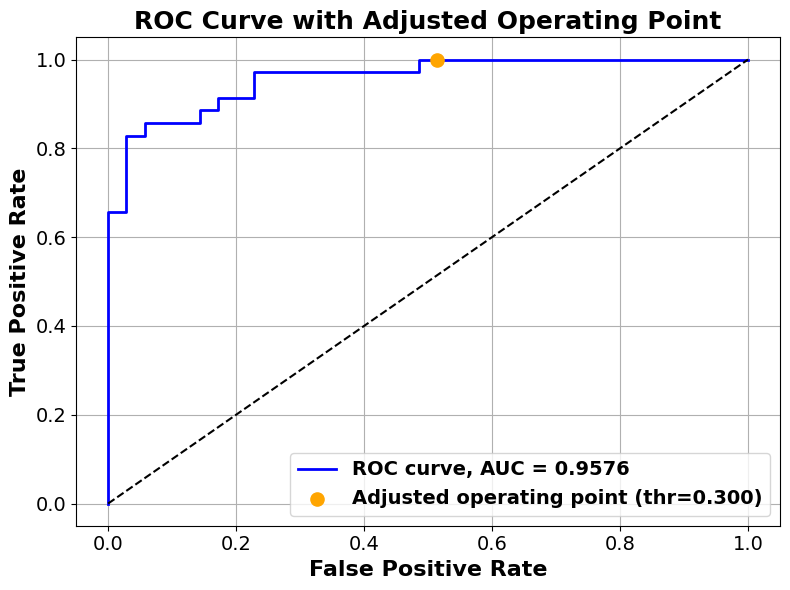

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/wideresnet50/


In [62]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/wideresnet50.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="wideresnet50")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1], 
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/wideresnet50/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/wideresnet50.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pre

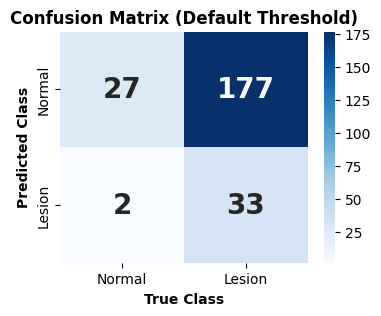


Adjusted Threshold (100% Recall): 0.1400

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


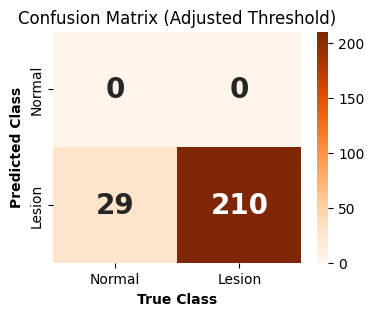

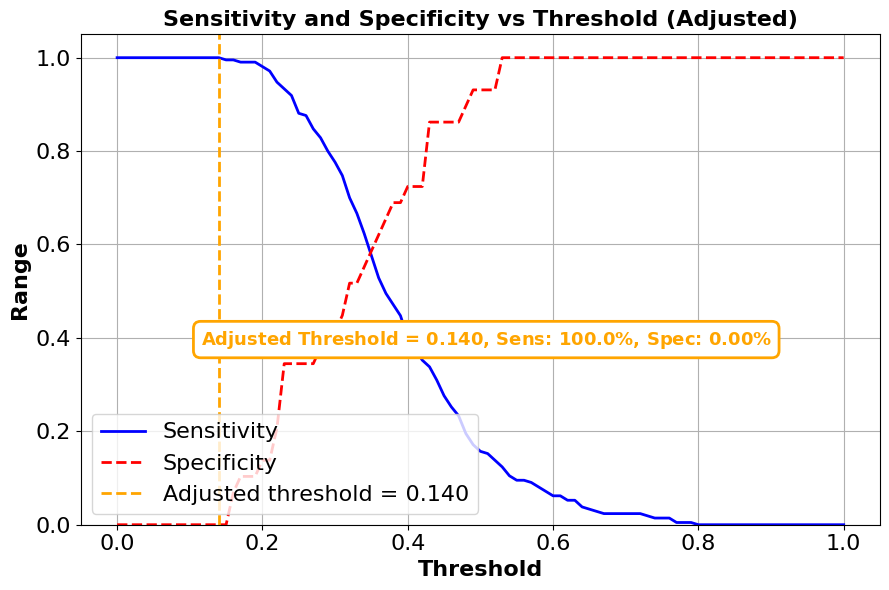


Saved ROC data to: results_100_epochs_lesion_normal/json/wideresnet50.json


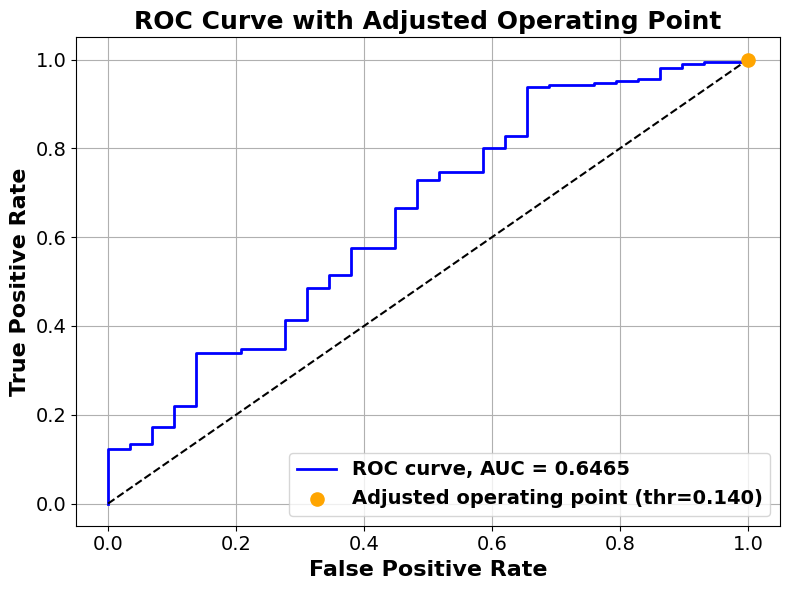

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/wideresnet50/


In [63]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/wideresnet50.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="wideresnet50")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1], 
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/wideresnet50/"
)

# WideResnet101_2

In [94]:
seeding(3)

## Model

In [95]:
model = wide_resnet101_2(weights=Wide_ResNet101_2_Weights.IMAGENET1K_V1)  # Initialize WideResNet-50-2 without pretrained weights

# Update the final classification layer
num_classes = len(class_names)  # Number of output classes
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))  # Replace with the number of output classes

# Move the model to the specified device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [96]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the WideResNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes training and validation loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # WideResNet forward pass
                    _, preds = torch.max(outputs, 1)  # Get predicted classes
                    loss = criterion(outputs, labels)  # Compute loss

                    # Backward pass and optimization in training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model based on validation accuracy
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Evaluate Function

In [97]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print Params

In [98]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 124,841,794
Trainable Parameters: 124,841,794
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6919 Acc: 0.5139
Val Loss: 0.7225 Acc: 0.5781
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet101.pth
Epoch 2/100
----------
Train Loss: 0.5706 Acc: 0.7292
Val Loss: 0.6296 Acc: 0.6562
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet101.pth
Epoch 3/100
----------
Train Loss: 0.4982 Acc: 0.7292
Val Loss: 0.6136 Acc: 0.6562
Epoch 4/100
----------
Train Loss: 0.3823 Acc: 0.8056
Val Loss: 0.6164 Acc: 0.6094
Epoch 5/100
----------
Train Loss: 0.2877 Acc: 0.9236
Val Loss: 0.5683 Acc: 0.6875
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet101.pth
Epoch 6/100
----------
Train Loss: 0.2186 Acc: 0.9583
Val Loss: 0.5211 Acc: 0.7188
Best model weights saved to results_100_epochs_lesion_normal/models/wideresnet101.pth
Epoch 7/100
----------
Train Loss: 0.1523 Acc: 0.9931
Val Loss: 0.5210 Acc: 0.7188
Epoch 8/100
----------
Train Loss: 0.1103 Acc: 1.0000
Val Loss: 0.5157 Acc:

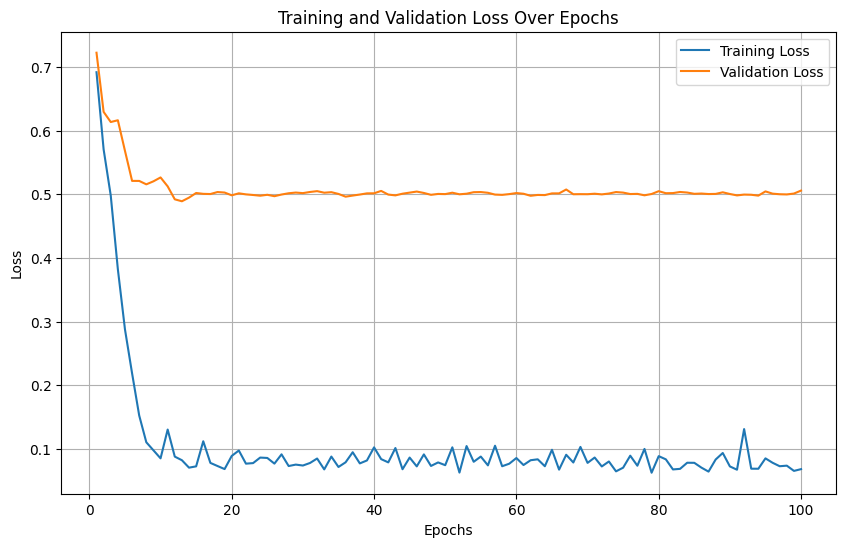

In [99]:
save_path = "results_100_epochs_lesion_normal/models/wideresnet101.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/wideresnet101.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual 

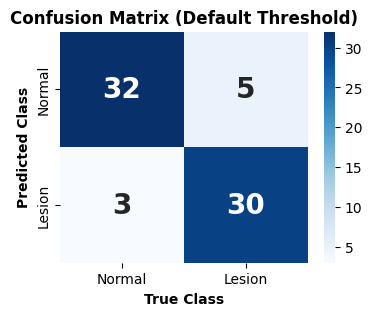


Adjusted Threshold (100% Recall): 0.0300

Adjusted Accuracy: 0.5286
Adjusted Precision: 0.5147
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.6796

Adjusted Confusion Matrix:
[[ 2  0]
 [33 35]]


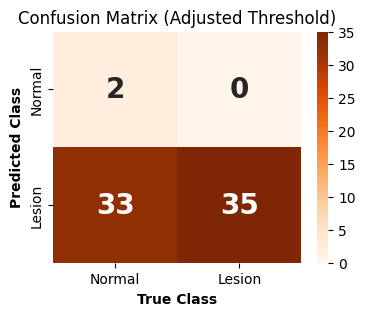

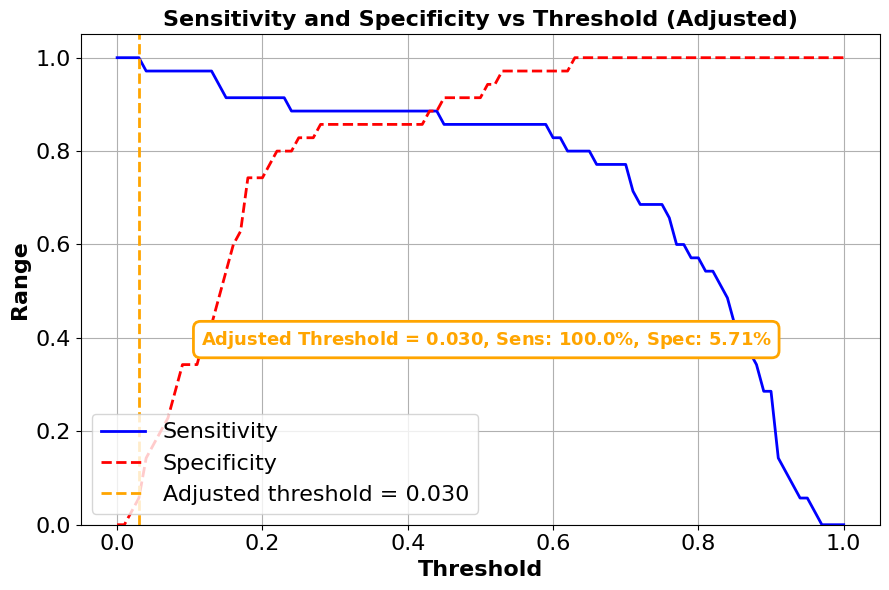


Saved ROC data to: results_100_epochs_lesion_normal/json/wideresnet101.json


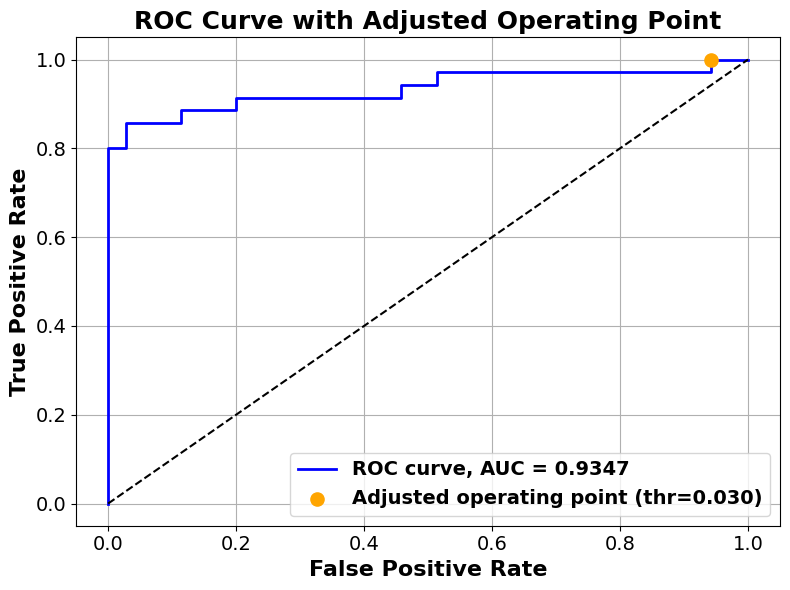

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/wideresnet101/


In [100]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/wideresnet101.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="wideresnet101")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1],  
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/wideresnet101/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/wideresnet101.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pr

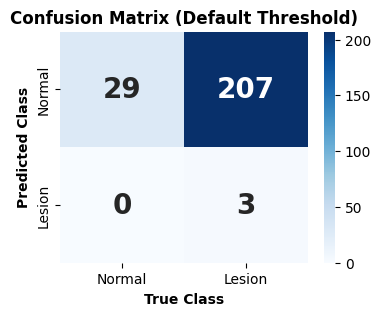


Adjusted Threshold (100% Recall): 0.0800

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


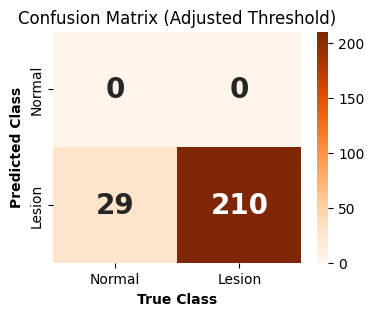

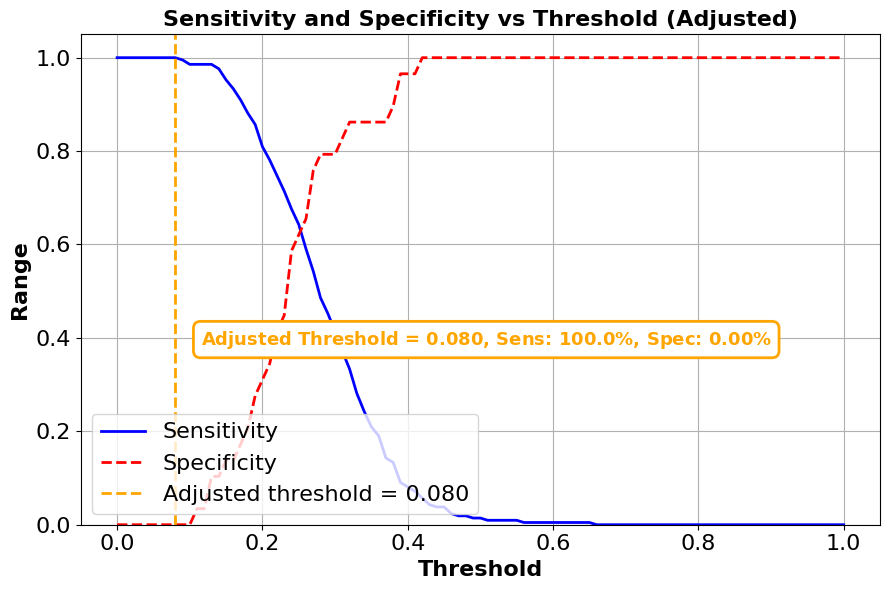


Saved ROC data to: results_100_epochs_lesion_normal/json/wideresnet101.json


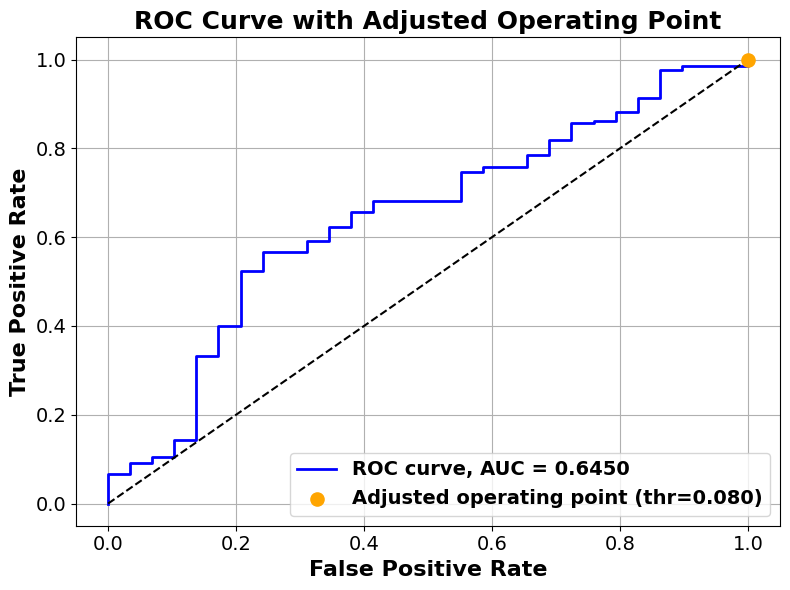

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/wideresnet101/


In [101]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/wideresnet101.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="wideresnet101")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer=model.layer4[-1],  # đổi theo kiến trúc bạn đang dùng
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/wideresnet101/"
)

# MaxVit

In [71]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths and data directories
data_dir = "Hospital_dataset2+Hospital_dataset1/"

# Data augmentation and preprocessing
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "internal_test": transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "external_test": transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [72]:
# Custom Dataset to include image paths
class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Custom dataset that includes image file paths.
    Extends torchvision.datasets.ImageFolder to return image paths as well.
    """
    def __getitem__(self, index):
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        path = self.imgs[index][0]
        return (*original_tuple, path)

# Force lesion = 1, normal = 0
custom_class_to_idx = {'Normal': 0, 'Lesion': 1}

# Load datasets with forced class mapping
image_datasets = {}
for x in ["train", "val","internal_test", "external_test"]:
    dataset = ImageFolderWithPaths(os.path.join(data_dir, x), transform=data_transforms[x])

    # Override class_to_idx and class list
    dataset.class_to_idx = custom_class_to_idx
    dataset.classes = ['Normal', 'Lesion']

    # Fix samples: use folder name from path to reassign labels
    fixed_samples = []
    for path, _ in dataset.samples:
        class_name = os.path.basename(os.path.dirname(path))  # e.g., 'normal' or 'lesion'
        label = custom_class_to_idx[class_name]
        fixed_samples.append((path, label))
    dataset.samples = dataset.imgs = fixed_samples

    image_datasets[x] = dataset

    # ✅ Print check
    print(f"\n==> [{x.upper()} SET] class_to_idx:", dataset.class_to_idx)
    print(f"Sample images in {x} set (label 0 = normal, 1 = lesion):")
    for i in range(min(5, len(dataset.samples))):
        img_path, label = dataset.samples[i]
        print(f"  {os.path.basename(img_path)} -> label: {label}")

# Define dataloaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=(x == "train"), num_workers=4)
    for x in ["train", "val","internal_test", "external_test"]
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val","internal_test", "external_test"]}
class_names = image_datasets["train"].classes


==> [TRAIN SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in train set (label 0 = normal, 1 = lesion):
  B2-10.jpg -> label: 1
  B2-11.jpg -> label: 1
  B2-13.jpg -> label: 1
  B2-16.jpg -> label: 1
  B2-17.jpg -> label: 1

==> [VAL SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in val set (label 0 = normal, 1 = lesion):
  B2-12.jpg -> label: 1
  B2-14.jpg -> label: 1
  B2-15.jpg -> label: 1
  B2-2.jpg -> label: 1
  B2-5.jpg -> label: 1

==> [INTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in internal_test set (label 0 = normal, 1 = lesion):
  Lesion 1.png -> label: 1
  Lesion 10.png -> label: 1
  Lesion 11.png -> label: 1
  Lesion 12.png -> label: 1
  Lesion 13.png -> label: 1

==> [EXTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in external_test set (label 0 = normal, 1 = lesion):
  fastMRI_breast_001_MIP.png -> label: 1
  fastMRI_breast_004_MIP.png -> label: 1
  fastMRI_breast_005_MIP.png -> label: 1
  fa

## Model

In [73]:
model = maxvit_t(weights=MaxVit_T_Weights.IMAGENET1K_V1)
# Update the final classification layer
num_classes = len(class_names)  # Number of output classes
num_ftrs = model.classifier[-1].in_features
model.classifier[-1] = torch.nn.Linear(num_ftrs, num_classes)

# Move the model to the specified device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/home/huy/.local/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Train Function

In [74]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the WideResNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes training and validation loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # WideResNet forward pass
                    _, preds = torch.max(outputs, 1)  # Get predicted classes
                    loss = criterion(outputs, labels)  # Compute loss

                    # Backward pass and optimization in training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model based on validation accuracy
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [75]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print Params

In [76]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 30,408,650
Trainable Parameters: 30,408,650
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.7522 Acc: 0.3889
Val Loss: 0.7102 Acc: 0.5469
Best model weights saved to results_100_epochs_lesion_normal/models/MaxVit.pth
Epoch 2/100
----------
Train Loss: 0.6510 Acc: 0.6042
Val Loss: 0.6922 Acc: 0.5938
Best model weights saved to results_100_epochs_lesion_normal/models/MaxVit.pth
Epoch 3/100
----------
Train Loss: 0.5847 Acc: 0.6875
Val Loss: 0.6619 Acc: 0.6406
Best model weights saved to results_100_epochs_lesion_normal/models/MaxVit.pth
Epoch 4/100
----------
Train Loss: 0.5352 Acc: 0.7292
Val Loss: 0.6571 Acc: 0.6562
Best model weights saved to results_100_epochs_lesion_normal/models/MaxVit.pth
Epoch 5/100
----------
Train Loss: 0.5452 Acc: 0.7500
Val Loss: 0.6545 Acc: 0.6406
Epoch 6/100
----------
Train Loss: 0.5144 Acc: 0.7639
Val Loss: 0.6483 Acc: 0.6406
Epoch 7/100
----------
Train Loss: 0.4977 Acc: 0.7708
Val Loss: 0.6435 Acc: 0.6562
Epoch 8/100
----------
Train Loss: 0.4372 Acc: 0.8333
Val Loss: 0.6413 Acc: 0.6562
Epoch 9/100
--------

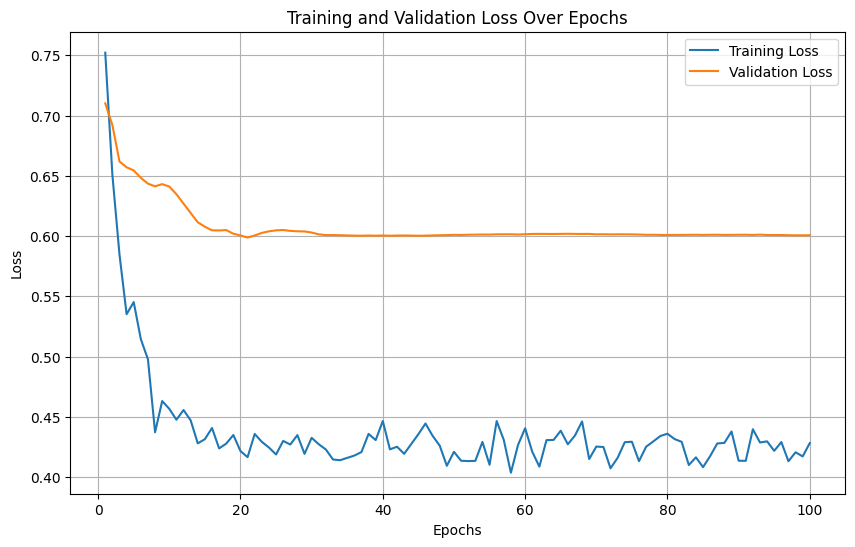

In [77]:
save_path = "results_100_epochs_lesion_normal/models/MaxVit.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/MaxVit.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesio

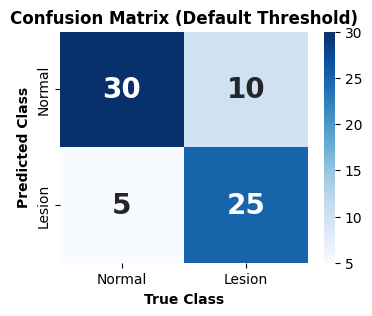


Adjusted Threshold (100% Recall): 0.2100

Adjusted Accuracy: 0.6571
Adjusted Precision: 0.5932
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7447

Adjusted Confusion Matrix:
[[11  0]
 [24 35]]


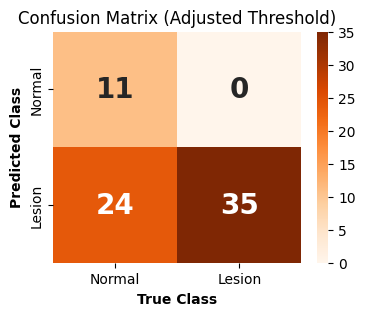

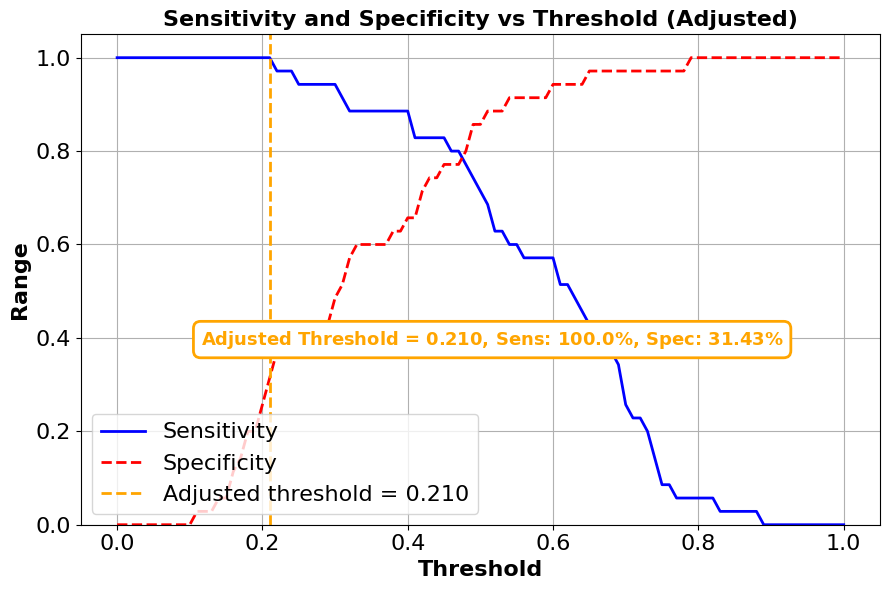


Saved ROC data to: results_100_epochs_lesion_normal/json/MaxVit.json


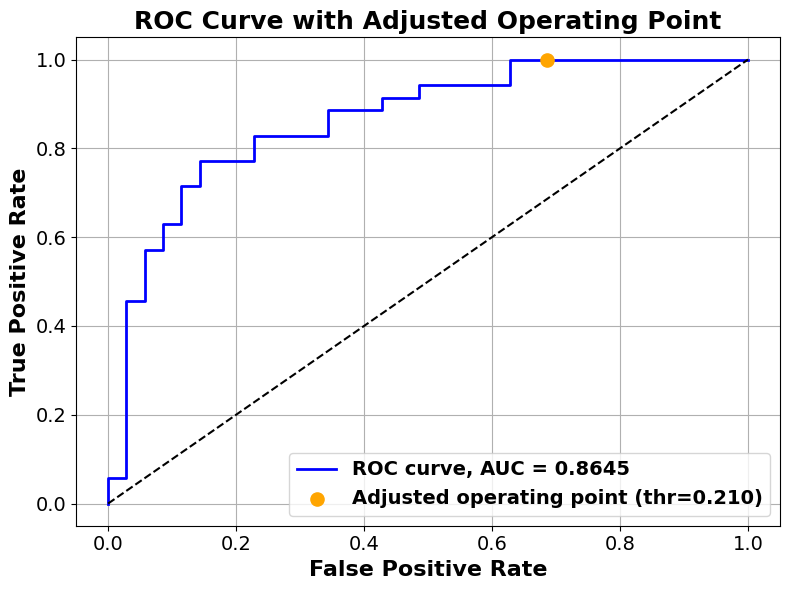

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/MaxVit/


In [78]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/MaxVit.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="MaxVit")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.blocks[-1],  
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/MaxVit/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/MaxVit.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(Defa

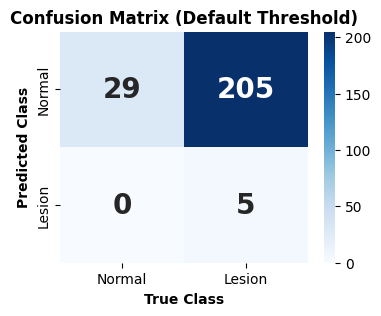


Adjusted Threshold (100% Recall): 0.1000

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


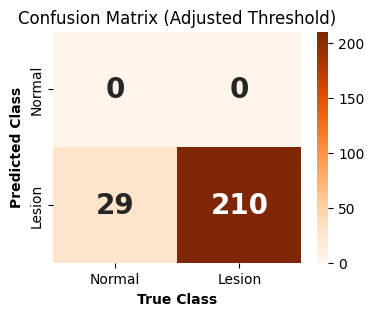

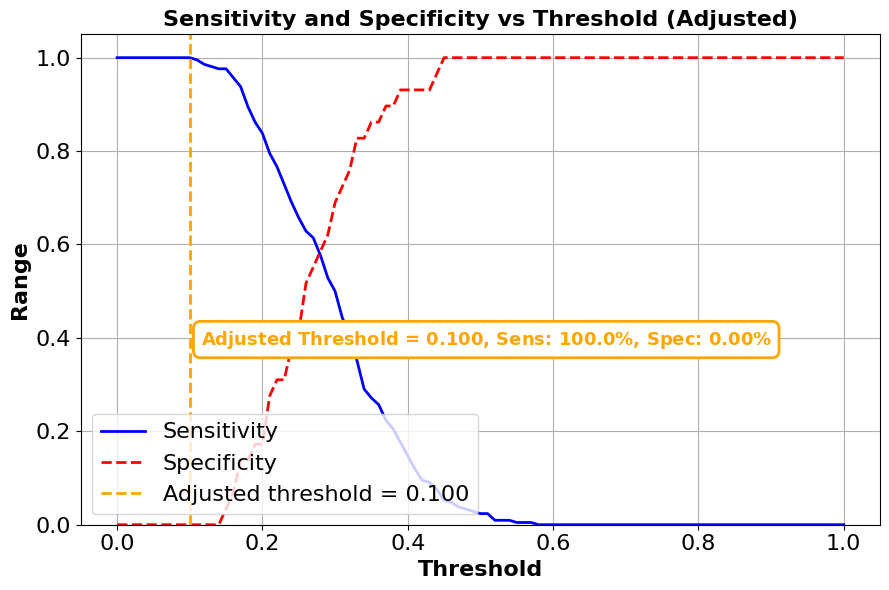


Saved ROC data to: results_100_epochs_lesion_normal/json/MaxVit.json


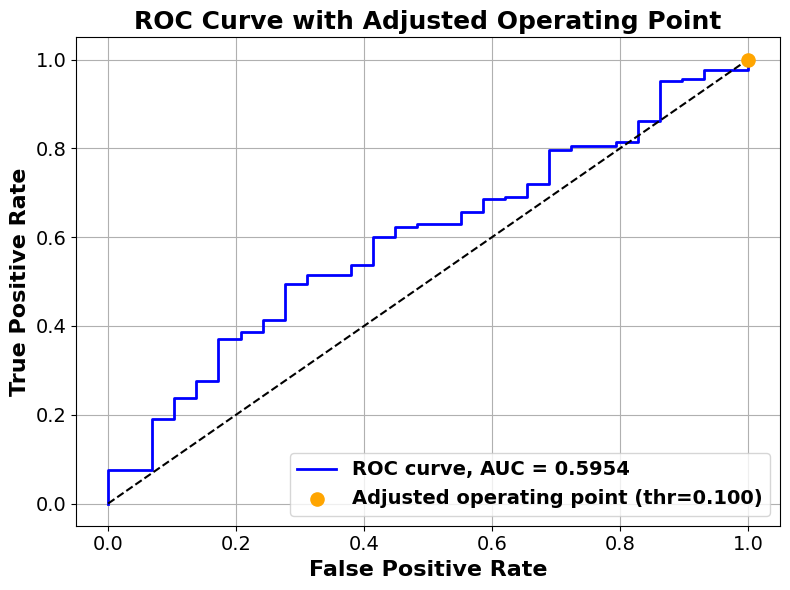

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/MaxVit/


In [79]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/MaxVit.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="MaxVit")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.blocks[-1],  
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/MaxVit/"
)

# MNASNet

## Model

In [80]:
model = mnasnet0_5(weights=MNASNet0_5_Weights.IMAGENET1K_V1)

# Update the final classification layer
num_classes = len(class_names)  # Number of output classes
num_ftrs = model.classifier[-1].in_features
model.classifier[-1] = torch.nn.Linear(num_ftrs, num_classes)
# Move the model to the specified device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [81]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the WideResNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes training and validation loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # WideResNet forward pass
                    _, preds = torch.max(outputs, 1)  # Get predicted classes
                    loss = criterion(outputs, labels)  # Compute loss

                    # Backward pass and optimization in training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model based on validation accuracy
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [82]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print Params

In [83]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 940,074
Trainable Parameters: 940,074
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6863 Acc: 0.6597
Val Loss: 0.6953 Acc: 0.4375
Best model weights saved to results_100_epochs_lesion_normal/models/MNASNet.pth
Epoch 2/100
----------
Train Loss: 0.6860 Acc: 0.5972
Val Loss: 0.6917 Acc: 0.5312
Best model weights saved to results_100_epochs_lesion_normal/models/MNASNet.pth
Epoch 3/100
----------
Train Loss: 0.6796 Acc: 0.6250
Val Loss: 0.6875 Acc: 0.5781
Best model weights saved to results_100_epochs_lesion_normal/models/MNASNet.pth
Epoch 4/100
----------
Train Loss: 0.6709 Acc: 0.6250
Val Loss: 0.6848 Acc: 0.5781
Epoch 5/100
----------
Train Loss: 0.6659 Acc: 0.6250
Val Loss: 0.6822 Acc: 0.5781
Epoch 6/100
----------
Train Loss: 0.6614 Acc: 0.6042
Val Loss: 0.6792 Acc: 0.5781
Epoch 7/100
----------
Train Loss: 0.6542 Acc: 0.6111
Val Loss: 0.6769 Acc: 0.5781
Epoch 8/100
----------
Train Loss: 0.6498 Acc: 0.6250
Val Loss: 0.6766 Acc: 0.5781
Epoch 9/100
----------
Train Loss: 0.6518 Acc: 0.6111
Val Loss: 0.6764 Acc: 0.5781
Epoch 10/100


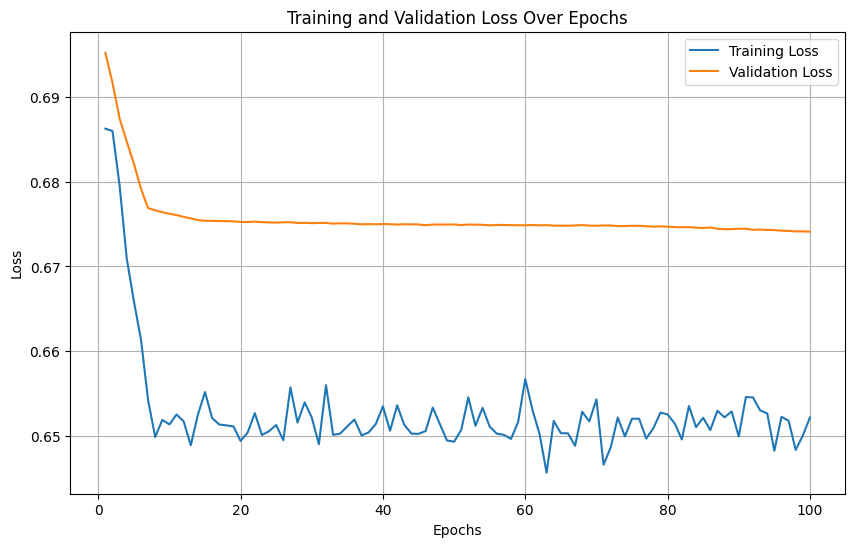

In [84]:
save_path = "results_100_epochs_lesion_normal/models/MNASNet.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/MNASNet.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesi

/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


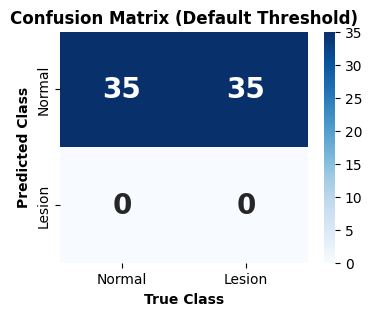


Adjusted Threshold (100% Recall): 0.4400

Adjusted Accuracy: 0.5000
Adjusted Precision: 0.5000
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.6667

Adjusted Confusion Matrix:
[[ 0  0]
 [35 35]]


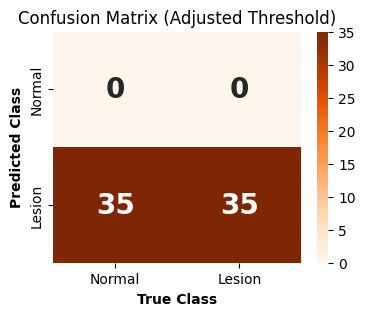

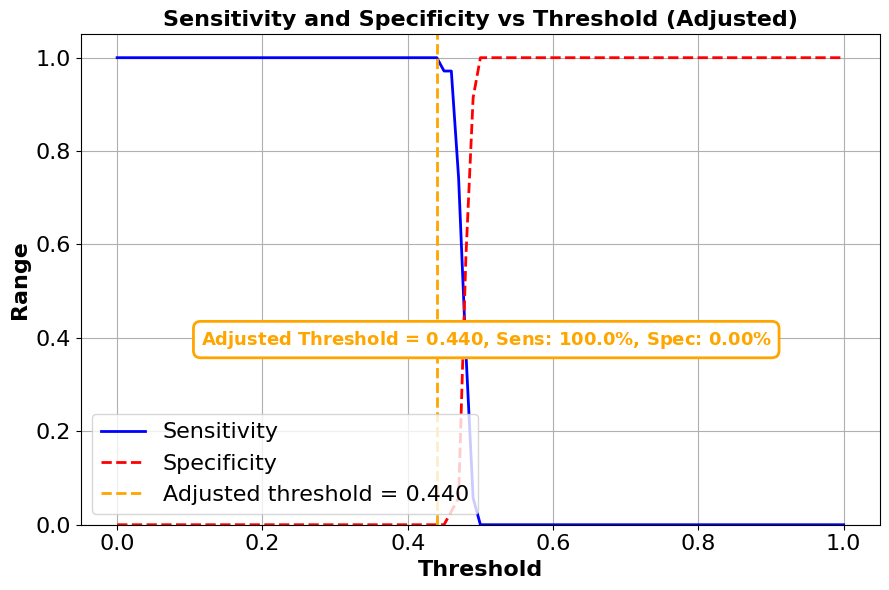


Saved ROC data to: results_100_epochs_lesion_normal/json/MNASNet.json


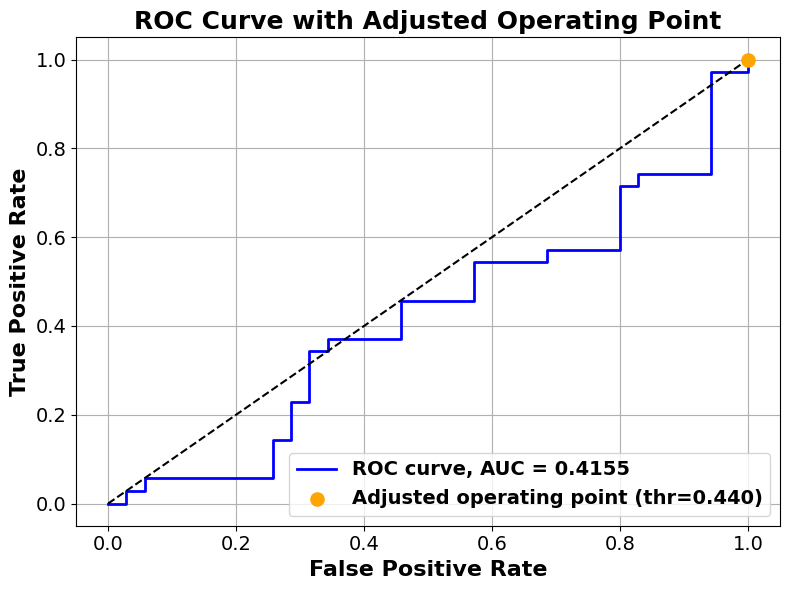

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/MNASNet/


In [85]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/MNASNet.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="MNASNet")

model = disable_inplace_relu(model)

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.layers[-1],  
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/MNASNet/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/MNASNet.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(Def

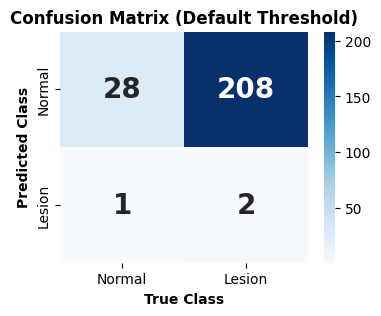


Adjusted Threshold (100% Recall): 0.4500

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


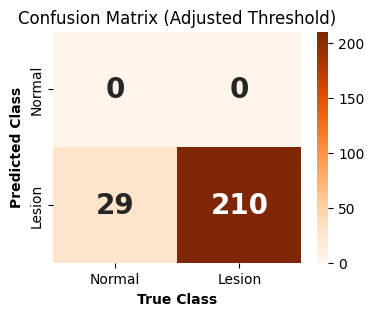

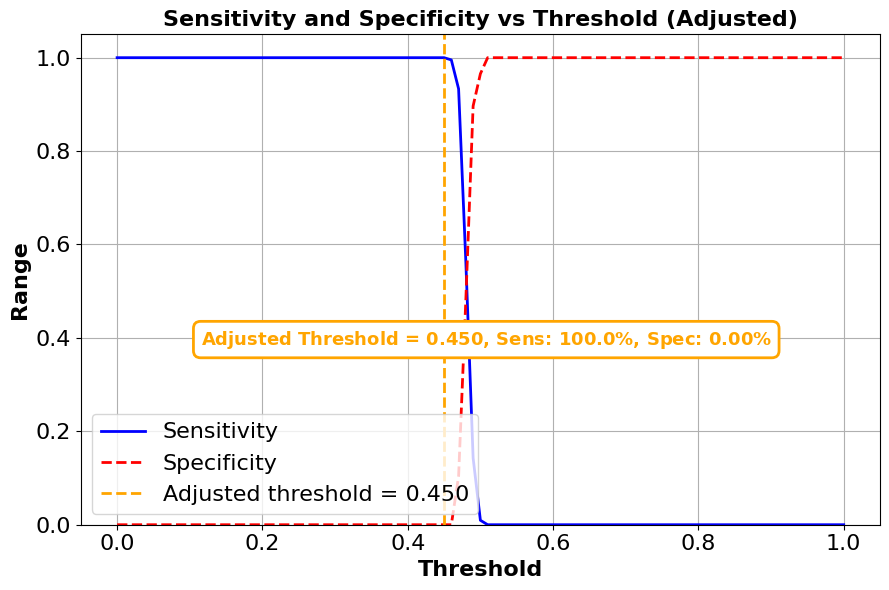


Saved ROC data to: results_100_epochs_lesion_normal/json/MNASNet.json


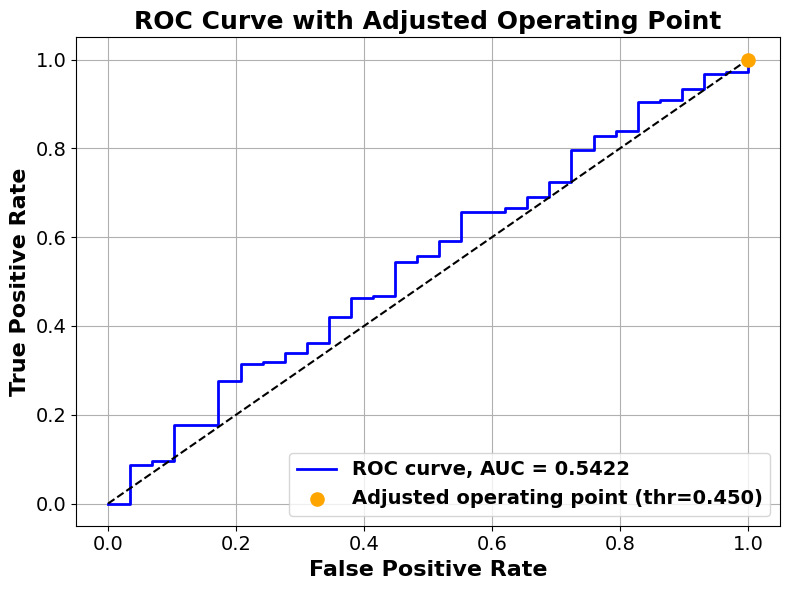

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/MNASNet/


In [86]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/MNASNet.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="MNASNet")

model = disable_inplace_relu(model)

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.layers[-1],  
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/MNASNet/"
)

# ResNext

In [58]:
seeding(1)

## Model

In [59]:
model = resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

# Update the final classification layer
num_classes = len(class_names)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, num_classes)

# Move the model to the specified device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function, optimizer, and learning rate scheduler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

## Train Function

In [60]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the WideResNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path and visualizes training and validation loss.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # WideResNet forward pass
                    _, preds = torch.max(outputs, 1)  # Get predicted classes
                    loss = criterion(outputs, labels)  # Compute loss

                    # Backward pass and optimization in training phase
                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses and accuracies
            if phase == "train":
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc.item())
                scheduler.step()
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc.item())

            # Save the best model based on validation accuracy
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Load the best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eval Function

In [61]:
def evaluate_model(model, dataloader, class_names, place, device, roc_params_file="roc_results.json"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ---- FIX 1: threshold search now tracks the index directly ----
    thresh_grid = np.arange(0.0, 1.01, 0.01)
    best_threshold = None
    best_idx = 0
    for i, t in enumerate(thresh_grid):
        adj_preds = (all_probs > t).astype(int)
        if recall_score(all_labels, adj_preds, zero_division=0) == 1.0:
            best_threshold = t
            best_idx = i
        else:
            break
    final_thresh = best_threshold if best_threshold is not None else 0.5
    final_idx = best_idx

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    print("\nModel Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    print(f"\nAdjusted Threshold (100% Recall): {final_thresh:.4f}")
    print(f"\nAdjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall: {recall_adj:.4f}")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix:")
    print(cm_adj)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    sensitivities, specificities = [], []
    for th in thresh_grid:
        preds = (all_probs > th).astype(int)
        tp = np.sum((all_labels == 1) & (preds == 1))
        fn = np.sum((all_labels == 1) & (preds == 0))
        tn = np.sum((all_labels == 0) & (preds == 0))
        fp = np.sum((all_labels == 0) & (preds == 1))
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    spec_at_thresh = specificities[final_idx]

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2, label=f"Adjusted threshold = {final_thresh:.3f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.3f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs(f'results_100_epochs_lesion_normal/{place}/json', exist_ok=True)
    with open(f"results_100_epochs_lesion_normal/{place}/json/{roc_params_file}", "w") as f:
        json.dump({
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": float(best_threshold) if best_threshold is not None else None,
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: results_100_epochs_lesion_normal/json/{roc_params_file}.json")

    fp_rate_adj = 1 - spec_at_thresh
    tp_rate_adj = recall_adj

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([fp_rate_adj], [tp_rate_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Adjusted Operating Point", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 14})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx

def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

## Print params

In [62]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 22,984,002
Trainable Parameters: 22,984,002
Non-Trainable Parameters: 0


## Train

Epoch 1/100
----------
Train Loss: 0.6762 Acc: 0.5903
Val Loss: 0.6558 Acc: 0.5781
Best model weights saved to results_100_epochs_lesion_normal/models/ResNeXt.pth
Epoch 2/100
----------
Train Loss: 0.6317 Acc: 0.6528
Val Loss: 0.6278 Acc: 0.5938
Best model weights saved to results_100_epochs_lesion_normal/models/ResNeXt.pth
Epoch 3/100
----------
Train Loss: 0.5947 Acc: 0.6806
Val Loss: 0.6326 Acc: 0.5938
Epoch 4/100
----------
Train Loss: 0.5690 Acc: 0.7153
Val Loss: 0.6122 Acc: 0.7188
Best model weights saved to results_100_epochs_lesion_normal/models/ResNeXt.pth
Epoch 5/100
----------
Train Loss: 0.5312 Acc: 0.7778
Val Loss: 0.6106 Acc: 0.5938
Epoch 6/100
----------
Train Loss: 0.4979 Acc: 0.7569
Val Loss: 0.5806 Acc: 0.7031
Epoch 7/100
----------
Train Loss: 0.4491 Acc: 0.8333
Val Loss: 0.5707 Acc: 0.7188
Epoch 8/100
----------
Train Loss: 0.4194 Acc: 0.8333
Val Loss: 0.5674 Acc: 0.7188
Epoch 9/100
----------
Train Loss: 0.4050 Acc: 0.8611
Val Loss: 0.5730 Acc: 0.7188
Epoch 10/100


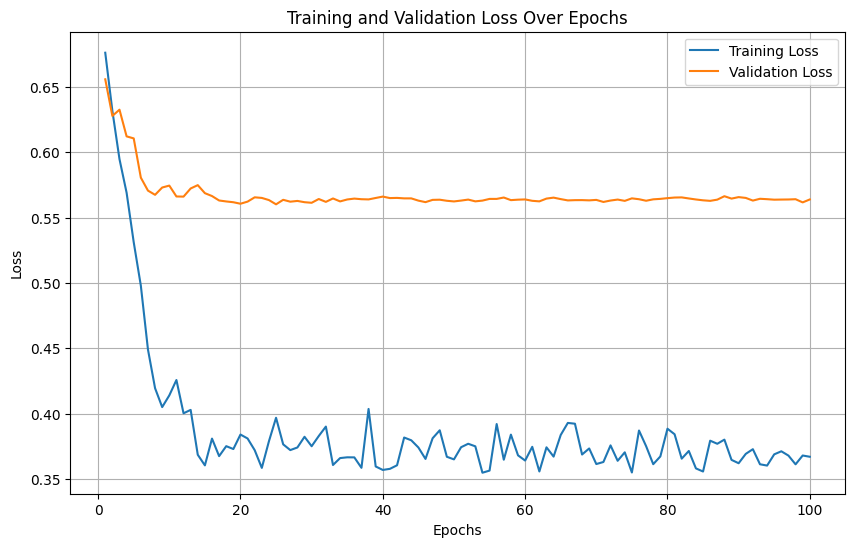

In [63]:
save_path = "results_100_epochs_lesion_normal/models/ResNeXt.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/ResNeXt.pth
Evaluating the model...
Image: Lesion 1.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 16.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 17.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 18.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 19.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesi

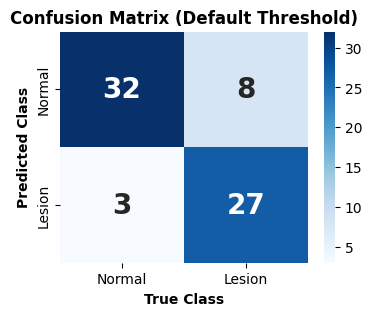


Adjusted Threshold (100% Recall): 0.2000

Adjusted Accuracy: 0.5857
Adjusted Precision: 0.5469
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.7071

Adjusted Confusion Matrix:
[[ 6  0]
 [29 35]]


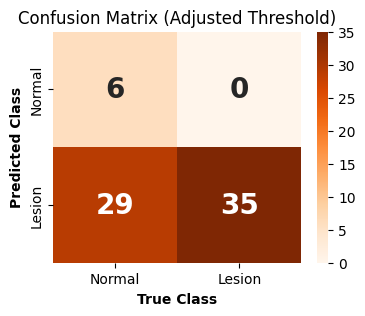

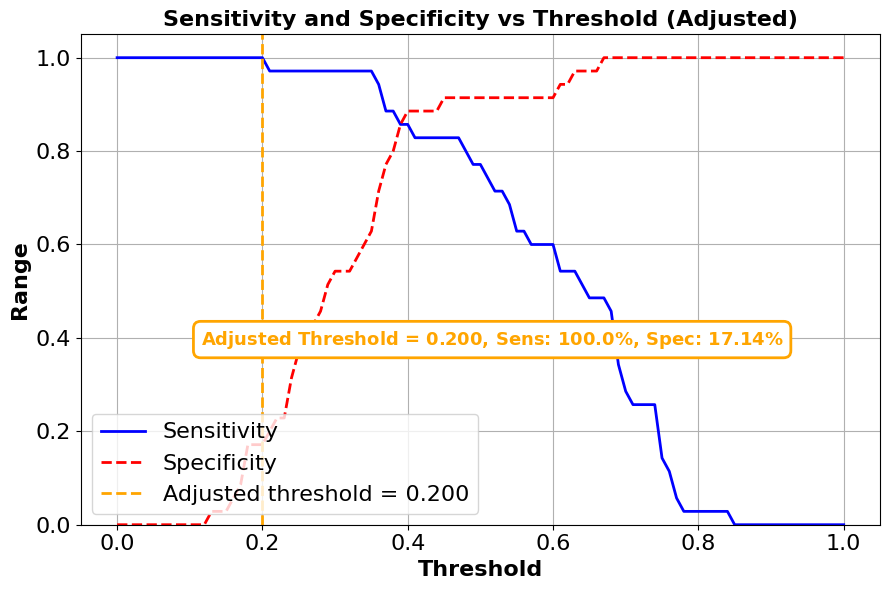


Saved ROC data to: results_100_epochs_lesion_normal/json/ResNeXt.json


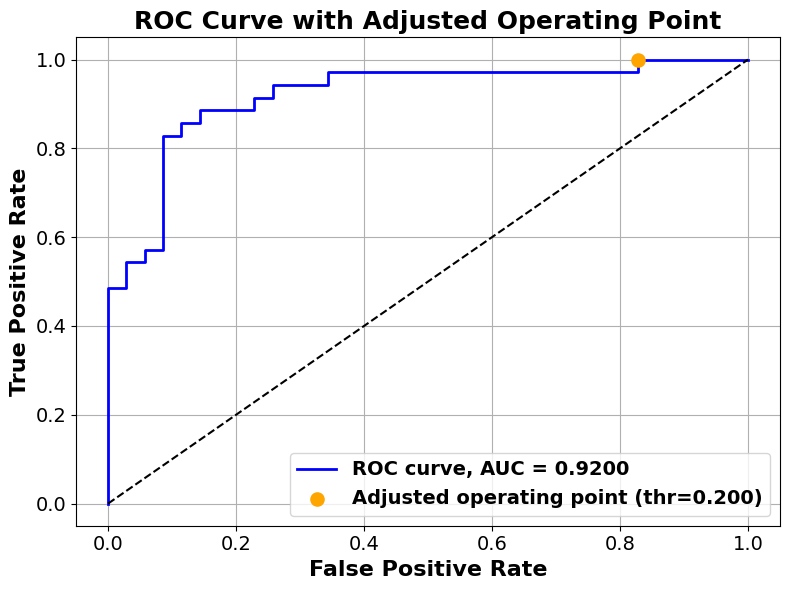

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/ResNeXt/


In [64]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/ResNeXt.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="ResNeXt")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer = model.layer4[-1],  
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/ResNeXt/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/ResNeXt.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, Pred(Def

/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huy/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


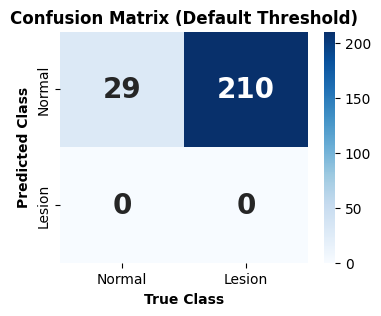


Adjusted Threshold (100% Recall): 0.2400

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


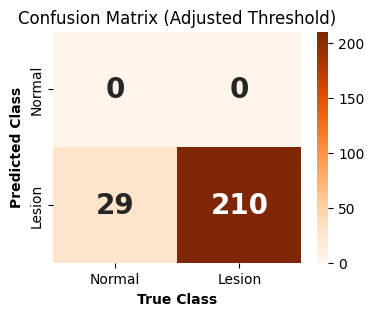

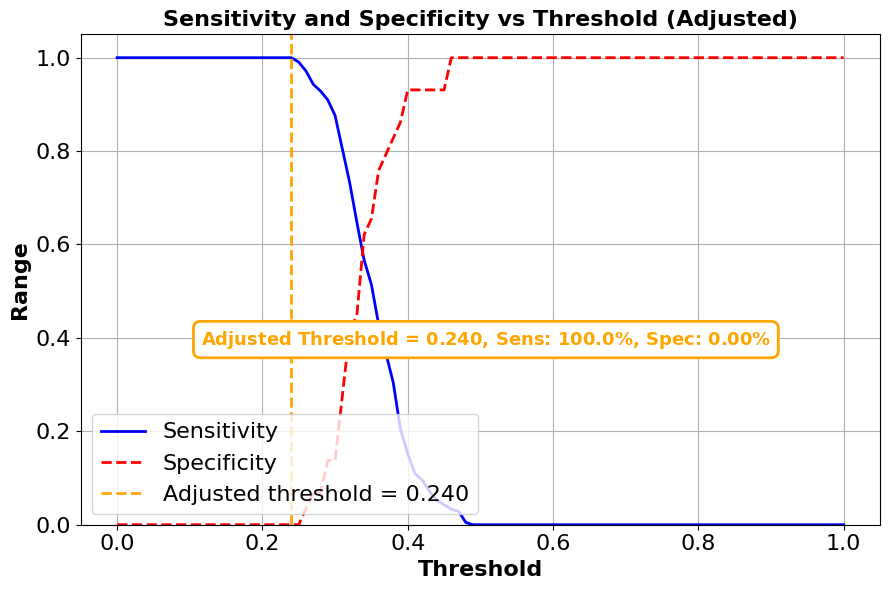


Saved ROC data to: results_100_epochs_lesion_normal/json/ResNeXt.json


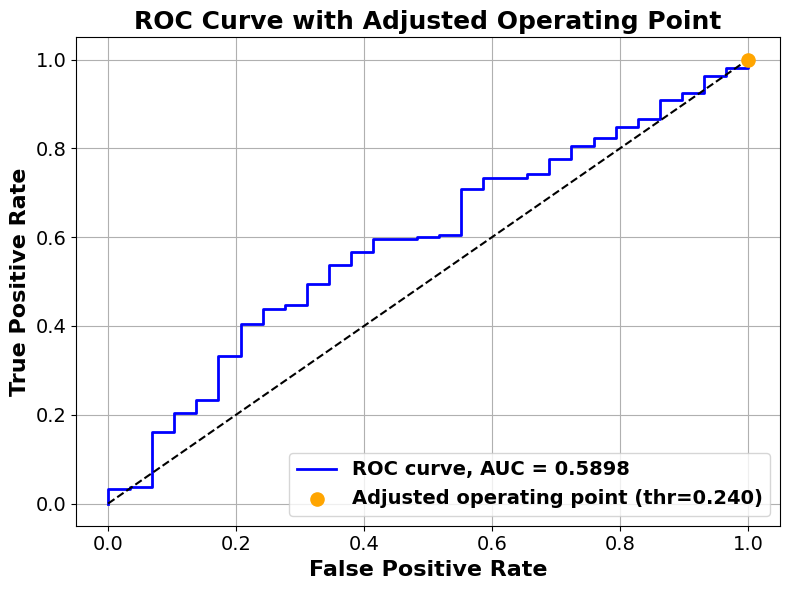

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/ResNeXt/


In [65]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/ResNeXt.pth"
model = load_model_weights(model, weight_path, device)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="ResNeXt")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer = model.layer4[-1],  
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/ResNeXt/"
)

# InceptionAttNet

In [14]:
seeding(34)

## Model

In [15]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths and data directories
data_dir = "Hospital_dataset2+Hospital_dataset1/"

# Data augmentation and preprocessing
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "internal_test": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "external_test": transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [16]:
# Custom Dataset to include image paths
class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Custom dataset that includes image file paths.
    Extends torchvision.datasets.ImageFolder to return image paths as well.
    """
    def __getitem__(self, index):
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        path = self.imgs[index][0]
        return (*original_tuple, path)

# Force lesion = 1, normal = 0
custom_class_to_idx = {'Normal': 0, 'Lesion': 1}

# Load datasets with forced class mapping
image_datasets = {}
for x in ["train", "val","internal_test", "external_test"]:
    dataset = ImageFolderWithPaths(os.path.join(data_dir, x), transform=data_transforms[x])

    # Override class_to_idx and class list
    dataset.class_to_idx = custom_class_to_idx
    dataset.classes = ['Normal', 'Lesion']

    # Fix samples: use folder name from path to reassign labels
    fixed_samples = []
    for path, _ in dataset.samples:
        class_name = os.path.basename(os.path.dirname(path))  # e.g., 'normal' or 'lesion'
        label = custom_class_to_idx[class_name]
        fixed_samples.append((path, label))
    dataset.samples = dataset.imgs = fixed_samples

    image_datasets[x] = dataset

    # ✅ Print check
    print(f"\n==> [{x.upper()} SET] class_to_idx:", dataset.class_to_idx)
    print(f"Sample images in {x} set (label 0 = normal, 1 = lesion):")
    for i in range(min(5, len(dataset.samples))):
        img_path, label = dataset.samples[i]
        print(f"  {os.path.basename(img_path)} -> label: {label}")

# Define dataloaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=(x == "train"), num_workers=4)
    for x in ["train", "val","internal_test", "external_test"]
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val","internal_test", "external_test"]}
class_names = image_datasets["train"].classes


==> [TRAIN SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in train set (label 0 = normal, 1 = lesion):
  B2-10.jpg -> label: 1
  B2-11.jpg -> label: 1
  B2-13.jpg -> label: 1
  B2-16.jpg -> label: 1
  B2-17.jpg -> label: 1

==> [VAL SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in val set (label 0 = normal, 1 = lesion):
  B2-12.jpg -> label: 1
  B2-14.jpg -> label: 1
  B2-15.jpg -> label: 1
  B2-2.jpg -> label: 1
  B2-5.jpg -> label: 1

==> [INTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in internal_test set (label 0 = normal, 1 = lesion):
  Lesion 1.png -> label: 1
  Lesion 10.png -> label: 1
  Lesion 11.png -> label: 1
  Lesion 12.png -> label: 1
  Lesion 13.png -> label: 1

==> [EXTERNAL_TEST SET] class_to_idx: {'Normal': 0, 'Lesion': 1}
Sample images in external_test set (label 0 = normal, 1 = lesion):
  fastMRI_breast_001_MIP.png -> label: 1
  fastMRI_breast_004_MIP.png -> label: 1
  fastMRI_breast_005_MIP.png -> label: 1
  fa

In [17]:

from torchvision.models import inception_v3, Inception_V3_Weights

In [18]:
class FFAB(nn.Module):
    def __init__(self, in_channels):
        super(FFAB, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.spatial_att = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels * 2, kernel_size=1),
            nn.Sigmoid()
        )
        self.fuse_conv = nn.Conv2d(in_channels * 2, in_channels, kernel_size=1)

    def forward(self, cnn_feat, trans_feat):
        trans_feat = F.interpolate(trans_feat, size=cnn_feat.shape[2:], mode='bilinear', align_corners=False)
        fused = torch.cat([cnn_feat, trans_feat], dim=1)
        att = self.spatial_att(fused)
        fused = fused * att
        return self.fuse_conv(fused)


In [19]:
class PatchEmbed(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)


In [20]:
class SimpleTransformerLayer(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        x2 = self.attn(x, x, x)[0]
        x = self.norm1(x + x2)
        x2 = self.mlp(x)
        return self.norm2(x + x2)

In [21]:
class InceptionAttNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = inception_v3(weights=Inception_V3_Weights.DEFAULT, aux_logits=True)

        # Stem + Early Inception modules
        self.layer0 = nn.Sequential(
            base.Conv2d_1a_3x3,
            base.Conv2d_2a_3x3,
            base.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Conv2d_3b_1x1,
            base.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Mixed_5b,
            base.Mixed_5c,
        )
        self.layer1 = base.Mixed_5d      # Output: 288
        self.layer2a = base.Mixed_6a     # 768
        self.layer2b = base.Mixed_6b
        self.layer2c = base.Mixed_6c
        self.layer2d = base.Mixed_6d
        self.layer2 = base.Mixed_6e      # Output: 768
        self.layer3a = base.Mixed_7a     # 1280
        self.layer3 = base.Mixed_7b      # Output: 2048
        self.layer4 = base.Mixed_7c      # Output: 2048

        # Reduction for fusion
        self.reduce1 = nn.Conv2d(288, 64, 1)
        self.reduce2 = nn.Conv2d(768, 128, 1)
        self.reduce3 = nn.Conv2d(1280, 256, 1)
        self.reduce4 = nn.Conv2d(2048, 512, 1)

        # Patch embeddings
        self.patch1 = PatchEmbed(64, 64, 4)
        self.patch2 = PatchEmbed(128, 128, 2)
        self.patch3 = PatchEmbed(256, 256, 2)
        self.patch4 = PatchEmbed(512, 512, 1)

        # Transformers
        self.trans_enc1 = SimpleTransformerLayer(64)
        self.trans_enc2 = SimpleTransformerLayer(128)
        self.trans_enc3 = SimpleTransformerLayer(256)
        self.trans_enc4 = SimpleTransformerLayer(512)

        # FFABs
        self.ffab1 = FFAB(64)
        self.ffab2 = FFAB(128)
        self.ffab3 = FFAB(256)
        self.ffab4 = FFAB(512)

        # Fusion
        self.fuse_proj2 = nn.Conv2d(128, 128, 1)
        self.fuse_proj3 = nn.Conv2d(256, 256, 1)
        self.fuse_proj4 = nn.Conv2d(512, 512, 1)

        self.match_f1 = nn.Conv2d(64, 128, 1)
        self.match_f2 = nn.Conv2d(128, 256, 1)
        self.match_f3 = nn.Conv2d(256, 512, 1)

        # Classifier
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.norm = nn.LayerNorm(512)
        self.classifier = nn.Linear(512, num_classes)

    def trans_fuse(self, c_feat, patch, trans_layer, ffab):
        b, c, h, w = c_feat.shape
        t = patch(c_feat)
        t_h, t_w = t.shape[2], t.shape[3]
        t = t.flatten(2).transpose(1, 2)          # (B, C, H*W) → (B, HW, C)
        t = trans_layer(t)                        # Transformer
        t = t.transpose(1, 2).reshape(b, -1, t_h, t_w)  # (B, HW, C) → (B, C, H, W)
        return ffab(c_feat, t)

    def forward(self, x):
        x = self.layer0(x)         # → [B, 192, 35, 35]
        x1 = self.layer1(x)        # → [B, 288, 35, 35]
        r1 = self.reduce1(x1)
        f1 = self.trans_fuse(r1, self.patch1, self.trans_enc1, self.ffab1)

        x2a = self.layer2a(x1)     # → [B, 768, 17, 17]
        x2b = self.layer2b(x2a)
        x2c = self.layer2c(x2b)
        x2d = self.layer2d(x2c)
        x2 = self.layer2(x2d)      # Final output from 6e

        r2 = self.reduce2(x2)
        f2 = self.trans_fuse(r2, self.patch2, self.trans_enc2, self.ffab2)
        f2 = self.fuse_proj2(f2) + self.match_f1(F.interpolate(f1, size=r2.shape[2:], mode="bilinear", align_corners=False))

        x3a = self.layer3a(x2)
        x3 = self.layer3(x3a)      # → [B, 2048, 8, 8]
        r3 = self.reduce3(x3a)
        f3 = self.trans_fuse(r3, self.patch3, self.trans_enc3, self.ffab3)
        f3 = self.fuse_proj3(f3) + self.match_f2(F.interpolate(f2, size=r3.shape[2:], mode="bilinear", align_corners=False))

        x4 = self.layer4(x3)
        r4 = self.reduce4(x4)
        f4 = self.trans_fuse(r4, self.patch4, self.trans_enc4, self.ffab4)
        f4 = self.fuse_proj4(f4) + self.match_f3(F.interpolate(f3, size=r4.shape[2:], mode="bilinear", align_corners=False))

        pooled = self.pool(f4).flatten(1)
        normed = self.norm(pooled)
        out = self.classifier(normed)
        return out

## Train Function

In [22]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=100, save_path="best_model.pth"):
    """
    Trains the DenseNet model and evaluates it at each epoch.
    Saves the best model weights to the specified path.
    Visualizes training and validation loss over epochs.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track losses for visualization
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over the data
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimization (training phase only)
                    if phase == "train":
                        optimizer.zero_grad()  # Clear gradients
                        loss.backward()  # Compute gradients
                        optimizer.step()  # Update weights

                # Update statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Adjust the learning rate at the end of each epoch (training phase only)
            if phase == "train":
                scheduler.step()

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Record losses
            if phase == "train":
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            # Save the best model weights during validation
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, save_path)
                print(f"Best model weights saved to {save_path}")

    # Training summary
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Visualize training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

    return model

## Eva Function

In [29]:
def evaluate_model(model, dataloader, class_names, place, device,
                   roc_params_file="roc_results.json", manual_threshold=None):
    # ------------------------------------------------------------------
    # Class-mapping guard.
    # Every metric below hardcodes index 1 as positive (probs[:, 1], and
    # sklearn's default pos_label=1). If the dataset ever assigns Lesion
    # to index 0 -- which is what ImageFolder does by default, since
    # 'Lesion' sorts before 'Normal' -- sensitivity and specificity would
    # silently swap and still look publishable. Fail loudly instead.
    # ------------------------------------------------------------------
    assert len(class_names) == 2, f"binary evaluation only, got {class_names}"
    assert class_names[1].strip().lower() == "lesion", (
        f"index 1 must be the positive (Lesion) class, got class_names={class_names}. "
        f"Expected mapping: {{'Normal': 0, 'Lesion': 1}}."
    )

    # class_names is just what the caller passed in -- it does not prove the
    # dataset agrees. Dig out the real mapping (through Subset/ConcatDataset
    # wrappers, which hide .class_to_idx behind .dataset) and cross-check.
    def _find_class_to_idx(ds, depth=0):
        if ds is None or depth > 5:
            return None
        if hasattr(ds, "class_to_idx"):
            return ds.class_to_idx
        if hasattr(ds, "dataset"):
            return _find_class_to_idx(ds.dataset, depth + 1)
        if hasattr(ds, "datasets") and ds.datasets:
            return _find_class_to_idx(ds.datasets[0], depth + 1)
        return None

    class_to_idx = _find_class_to_idx(getattr(dataloader, "dataset", None))
    print(f"dataset.class_to_idx = {class_to_idx}")
    print(f"class_names          = {list(class_names)}")

    if class_to_idx is not None:
        idx_to_name = {v: k for k, v in class_to_idx.items()}
        mismatches = [
            (i, class_names[i], idx_to_name.get(i))
            for i in range(len(class_names))
            if idx_to_name.get(i) is not None
            and idx_to_name[i].strip().lower() != class_names[i].strip().lower()
        ]
        assert not mismatches, (
            f"class_names does not match the dataset's own mapping: {mismatches} "
            f"(index, class_names[index], dataset name). Metrics would be labelled "
            f"for the wrong class. dataset.class_to_idx={class_to_idx}"
        )
    else:
        print("[warn] could not read class_to_idx from the dataset; "
              "positive-class mapping is unverified.")

    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    sample_logs = []
    image_paths, raw_preds, softmax_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, paths in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            image_paths.extend(paths)
            raw_preds.extend(preds.cpu().numpy())
            softmax_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    n_pos = int((all_labels == 1).sum())
    n_neg = int((all_labels == 0).sum())
    print(f"Test set: {n_pos} {class_names[1]} (positive), {n_neg} {class_names[0]} (negative)")

    # ---- ROC (continuous, from raw probabilities) ----
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # ------------------------------------------------------------------
    # Sensitivity / specificity helpers
    # ------------------------------------------------------------------
    # Returns NaN (not 0.0) when a denominator is empty, so an absent class
    # is visibly distinct from a genuine 0.0 and propagates through any
    # downstream averaging instead of quietly dragging it down.
    # ------------------------------------------------------------------
    def sens_spec_from_preds(labels, preds):
        tp = np.sum((labels == 1) & (preds == 1))
        fn = np.sum((labels == 1) & (preds == 0))
        tn = np.sum((labels == 0) & (preds == 0))
        fp = np.sum((labels == 0) & (preds == 1))
        sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        return float(sens), float(spec)

    def sens_spec_at(th):
        return sens_spec_from_preds(all_labels, (all_probs > th).astype(int))

    def wilson_ci(k, n, z=1.96):
        """95% Wilson interval for a proportion. Appropriate at small n,
        where the normal approximation is not."""
        if n == 0:
            return (float("nan"), float("nan"))
        p = k / n
        denom = 1 + z**2 / n
        centre = (p + z**2 / (2 * n)) / denom
        half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
        return (float(max(0.0, centre - half)), float(min(1.0, centre + half)))

    # ------------------------------------------------------------------
    # Threshold selection
    # ------------------------------------------------------------------
    # If manual_threshold is provided, it wins: no search is performed and
    # the value is used exactly as given (not snapped to the 0.01 grid).
    #
    # Otherwise: the HIGHEST threshold that still catches every positive
    # case, with guard rails:
    #   * never accept t = 0.00 -> it labels everything positive, so recall
    #     is trivially 1.0 and specificity is 0. That is not an operating
    #     point, it is a degenerate corner of the ROC curve.
    #   * if 100% recall is only reachable below MIN_THRESHOLD (or only with
    #     zero specificity), fall back to Youden's J.
    # The grid below is only for the sweep plot; sens/spec at the reported
    # operating point are computed at the exact threshold, so a manual value
    # falling between grid points is still scored correctly.
    # ------------------------------------------------------------------
    MIN_THRESHOLD = 0.01

    thresh_grid = np.arange(0.0, 1.01, 0.01)
    grid_vals = np.array([sens_spec_at(th) for th in thresh_grid])
    sensitivities = grid_vals[:, 0]
    specificities = grid_vals[:, 1]

    if manual_threshold is not None:
        final_thresh = float(manual_threshold)
        if not 0.0 <= final_thresh <= 1.0:
            raise ValueError(f"manual_threshold must be in [0, 1], got {final_thresh}")
        best_threshold = None
        threshold_rule = "manual threshold (user-specified)"
    else:
        valid = (sensitivities >= 1.0) & (thresh_grid >= MIN_THRESHOLD) & (specificities > 0)

        if valid.any():
            final_idx = int(np.flatnonzero(valid).max())   # highest qualifying threshold
            best_threshold = float(thresh_grid[final_idx])
            threshold_rule = "max threshold with 100% recall"
        else:
            j_stat = sensitivities + specificities - 1.0
            j_stat[thresh_grid < MIN_THRESHOLD] = -np.inf
            final_idx = int(np.argmax(j_stat))
            best_threshold = None
            threshold_rule = "Youden's J (100% recall unreachable above 0.00)"
            min_pos_prob = float(all_probs[all_labels == 1].min()) if n_pos else float("nan")
            print(f"[warn] 100% recall requires t < {MIN_THRESHOLD:.2f} "
                  f"(lowest positive-class probability = {min_pos_prob:.6f}). "
                  f"Falling back to Youden's J.")

        final_thresh = float(thresh_grid[final_idx])

    # computed at the exact threshold, not snapped to the grid
    sens_at_thresh, spec_at_thresh = sens_spec_at(final_thresh)

    if manual_threshold is not None and sens_at_thresh < 1.0:
        print(f"[warn] manual threshold {final_thresh:.4f} gives recall "
              f"{sens_at_thresh:.4f} — some {class_names[1]} cases are missed.")

    print(f"\nThreshold rule: {threshold_rule}")
    print(f"Selected threshold: {final_thresh:.4f}")

    for i in range(len(image_paths)):
        image_name = os.path.basename(image_paths[i])
        true_label = int(all_labels[i])
        pred_label_default = int(raw_preds[i])
        prob_class_1 = float(softmax_probs[i][1])
        pred_label_adjusted = int(prob_class_1 > final_thresh)

        print(f"Image: {image_name}, Pred(Default) = {class_names[pred_label_default]}, "
              f"Pred(Adj) = {class_names[pred_label_adjusted]}, Actual = {class_names[true_label]}")

        sample_logs.append({
            "image": image_name,
            "true_label": true_label,
            "prob_class_1": prob_class_1,
            "predicted_label_default": pred_label_default,
            "predicted_label_adjusted": pred_label_adjusted
        })

    # ------------------------------------------------------------------
    # Default threshold (argmax over the two logits, i.e. P(Lesion) >= 0.5)
    # ------------------------------------------------------------------
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    sens_default, spec_default = sens_spec_from_preds(all_labels, all_preds)
    cm = sk_confusion_matrix(all_labels, all_preds).T

    tn_def = int(np.sum((all_labels == 0) & (all_preds == 0)))
    tp_def = int(np.sum((all_labels == 1) & (all_preds == 1)))
    sens_ci = wilson_ci(tp_def, n_pos)
    spec_ci = wilson_ci(tn_def, n_neg)

    print("\nModel Evaluation (Default Threshold):")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}  [95% CI {sens_ci[0]:.4f}-{sens_ci[1]:.4f}, n={n_pos}]")
    print(f"Specificity: {spec_default:.4f}  [95% CI {spec_ci[0]:.4f}-{spec_ci[1]:.4f}, n={n_neg}]")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix (rows = predicted, cols = true):")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Default Threshold)", fontweight='bold')
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    # ------------------------------------------------------------------
    # Adjusted threshold
    # ------------------------------------------------------------------
    adjusted_preds = (all_probs > final_thresh).astype(int)
    acc_adj = accuracy_score(all_labels, adjusted_preds)
    precision_adj = precision_score(all_labels, adjusted_preds, zero_division=0)
    recall_adj = recall_score(all_labels, adjusted_preds, zero_division=0)
    f1_adj = f1_score(all_labels, adjusted_preds, zero_division=0)
    cm_adj = sk_confusion_matrix(all_labels, adjusted_preds).T

    tn_adj = int(np.sum((all_labels == 0) & (adjusted_preds == 0)))
    tp_adj = int(np.sum((all_labels == 1) & (adjusted_preds == 1)))
    sens_ci_adj = wilson_ci(tp_adj, n_pos)
    spec_ci_adj = wilson_ci(tn_adj, n_neg)

    print(f"\nModel Evaluation (Adjusted Threshold = {final_thresh:.4f}, rule: {threshold_rule}):")
    print(f"Adjusted Accuracy: {acc_adj:.4f}")
    print(f"Adjusted Precision: {precision_adj:.4f}")
    print(f"Adjusted Recall (Sensitivity): {recall_adj:.4f}  "
          f"[95% CI {sens_ci_adj[0]:.4f}-{sens_ci_adj[1]:.4f}, n={n_pos}]")
    print(f"Adjusted Specificity: {spec_at_thresh:.4f}  "
          f"[95% CI {spec_ci_adj[0]:.4f}-{spec_ci_adj[1]:.4f}, n={n_neg}]")
    print(f"Adjusted F1-Score: {f1_adj:.4f}")
    print("\nAdjusted Confusion Matrix (rows = predicted, cols = true):")
    print(cm_adj)

    print("\nDefault vs Adjusted:")
    print(f"  Sensitivity: {sens_default:.4f} -> {recall_adj:.4f}")
    print(f"  Specificity: {spec_default:.4f} -> {spec_at_thresh:.4f}")

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_adj, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 20, "weight": "bold"})
    plt.title("Confusion Matrix (Adjusted Threshold)")
    plt.xlabel("True Class", fontweight='bold')
    plt.ylabel("Predicted Class", fontweight='bold')
    plt.show()

    plt.figure(figsize=(9, 6))
    plt.plot(thresh_grid, sensitivities, label="Sensitivity", color="blue", linewidth=2)
    plt.plot(thresh_grid, specificities, label="Specificity", color="red", linestyle="--", linewidth=2)
    plt.axvline(x=final_thresh, color='orange', linestyle='--', linewidth=2,
                label=f"Adjusted threshold = {final_thresh:.4f}")
    plt.text(
        0.15, 0.40,
        f"$\\bf{{Adjusted\\ Threshold}}$ = {final_thresh:.4f}, "
        f"$\\bf{{Sens}}$: {recall_adj*100:.1f}%, $\\bf{{Spec}}$: {spec_at_thresh*100:.2f}%",
        transform=plt.gca().transAxes,
        color='orange',
        fontsize=13,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="orange", lw=2)
    )
    plt.xlabel("Threshold", fontsize=16, fontweight='bold')
    plt.ylabel("Range", fontsize=16, fontweight='bold')
    plt.title("Sensitivity and Specificity vs Threshold (Adjusted)", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    json_dir = f'results_100_epochs_lesion_normal/{place}/json'
    os.makedirs(json_dir, exist_ok=True)
    json_path = os.path.join(json_dir, roc_params_file)
    with open(json_path, "w") as f:
        json.dump({
            "class_names": list(class_names),
            "positive_class": class_names[1],
            "n_positive": n_pos,
            "n_negative": n_neg,
            "fpr": [float(x) for x in fpr],
            "tpr": [float(x) for x in tpr],
            "roc_auc": float(roc_auc),
            "threshold_100_recall": best_threshold,   # None when manual, or when not achievable above 0.00
            "adjusted_threshold": float(final_thresh),
            "threshold_rule": threshold_rule,
            "manual_threshold": (float(manual_threshold) if manual_threshold is not None else None),
            # --- default threshold ---
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "sensitivity": float(sens_default),
            "specificity": float(spec_default),
            "sensitivity_ci95": list(sens_ci),
            "specificity_ci95": list(spec_ci),
            "f1_score": float(f1),
            # --- adjusted threshold ---
            "adjusted_accuracy": float(acc_adj),
            "adjusted_precision": float(precision_adj),
            "adjusted_recall": float(recall_adj),
            "adjusted_sensitivity": float(recall_adj),
            "adjusted_f1_score": float(f1_adj),
            "specificity_at_adjusted_threshold": float(spec_at_thresh),
            "adjusted_sensitivity_ci95": list(sens_ci_adj),
            "adjusted_specificity_ci95": list(spec_ci_adj),
            # --- raw ---
            "confusion_matrix": [[int(x) for x in row] for row in cm],
            "adjusted_confusion_matrix": [[int(x) for x in row] for row in cm_adj],
            "labels": [int(x) for x in all_labels],
            "predictions": [int(x) for x in all_preds],
            "probabilities": [float(x) for x in all_probs],
            "sample_predictions": sample_logs
        }, f, indent=4)

    print(f"\nSaved ROC data to: {json_path}")

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve, AUC = {roc_auc:.4f}", color="blue", linewidth=2)
    plt.scatter([1 - spec_default], [sens_default], color="green", zorder=5, s=90, marker="s",
                label="Default operating point (thr=0.50)")
    plt.scatter([1 - spec_at_thresh], [recall_adj], color="orange", zorder=5, s=90,
                label=f"Adjusted operating point (thr={final_thresh:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
    plt.title("ROC Curve with Operating Points", fontsize=18, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=16, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'weight': 'bold', 'size': 12})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1, cm


class GradCAM:
    def __init__(self, model, target_layer, hook_input=False):
        """
        hook_input=True: capture the INPUT to target_layer instead of its
        output. Needed when the true final feature map is computed inline
        in forward() (e.g. f4 = fuse_proj4(f4) + match_f3(...)) right
        before being passed into a fixed module like pool.
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_input = hook_input

        if hook_input:
            self._fwd_handle = target_layer.register_forward_pre_hook(self._save_activation_pre)
        else:
            self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation_pre(self, module, inputs):
        out = inputs[0]
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()

        h, w = input_tensor.shape[2], input_tensor.shape[3]
        cam = cv2.resize(cam, (w, h))
        return cam, class_idx


def overlay_gradcam(image_tensor, cam, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    img_uint8 = (img * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.3 * heatmap + img_uint8).astype(np.uint8)
    return img_uint8, heatmap, overlay


def run_gradcam_all(model, dataloader, class_names, device, target_layer,
                     save_dir="results_100_epochs_lesion_normal/gradcam",
                     hook_input=False):
    os.makedirs(save_dir, exist_ok=True)
    cam_extractor = GradCAM(model, target_layer, hook_input=hook_input)

    total = 0
    for inputs, labels, paths in dataloader:
        for i in range(inputs.size(0)):
            single_input = inputs[i:i+1].to(device)
            true_label = int(labels[i].item())
            image_name = os.path.basename(paths[i])
            image_stem = os.path.splitext(image_name)[0]

            cam, pred_class = cam_extractor.generate(single_input)
            img_uint8, heatmap, overlay = overlay_gradcam(inputs[i], cam)

            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")
            axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
            fig.suptitle(
                f"{image_name} | True: {class_names[true_label]} | Pred: {class_names[pred_class]}",
                fontweight='bold'
            )
            plt.tight_layout()

            out_path = os.path.join(save_dir, f"{image_stem}_true-{class_names[true_label]}_pred-{class_names[pred_class]}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)  # don't plt.show() — with a full dataset this would flood the notebook

            total += 1
            if total % 50 == 0:
                print(f"Saved {total} Grad-CAM images so far...")

    cam_extractor.remove_hooks()
    print(f"\nDone. Saved {total} Grad-CAM images to: {save_dir}")

In [25]:
# Model definition
model = InceptionAttNet(num_classes=2).to(device)

# Loss and optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
step_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()  # For integer labels (0 or 1)



## Print params

In [26]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {total_params - trainable_params:,}")

# Count parameters
count_parameters(model)

Total Parameters: 29,519,578
Trainable Parameters: 29,519,578
Non-Trainable Parameters: 0


In [27]:
import torch
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Pt

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


def export_model_params_to_word(model, output_file="model_parameters.docx", only_with_params=True):
    doc = Document()

    # ---------- Title ----------
    title = doc.add_paragraph("Model Parameter Report")
    title.runs[0].bold = True
    title.runs[0].font.size = Pt(16)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph("")

    # ---------- Total Parameters ----------
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    doc.add_paragraph("Overall Parameter Count:").runs[0].bold = True
    doc.add_paragraph(f"Total Parameters: {total_params:,}")
    doc.add_paragraph(f"Trainable Parameters: {trainable_params:,}")
    doc.add_paragraph(f"Non-Trainable Parameters: {non_trainable_params:,}")
    doc.add_paragraph("")

    # ---------- Create Table ----------
    table = doc.add_table(rows=1, cols=5)
    table.style = "Table Grid"

    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = "Module Name"
    hdr_cells[1].text = "Type"
    hdr_cells[2].text = "Total"
    hdr_cells[3].text = "Trainable"
    hdr_cells[4].text = "Non-Trainable"

    total_all = 0
    trainable_all = 0

    # ---------- Fill Table ----------
    for name, module in model.named_modules():
        params = list(module.parameters(recurse=False))
        total = sum(p.numel() for p in params)
        trainable = sum(p.numel() for p in params if p.requires_grad)
        non_trainable = total - trainable

        if only_with_params and total == 0:
            continue

        total_all += total
        trainable_all += trainable

        row_cells = table.add_row().cells
        row_cells[0].text = name
        row_cells[1].text = module.__class__.__name__
        row_cells[2].text = f"{total:,}"
        row_cells[3].text = f"{trainable:,}"
        row_cells[4].text = f"{non_trainable:,}"

    # ---------- Add SUM Row ----------
    sum_row = table.add_row().cells
    sum_row[0].text = "SUM"
    sum_row[1].text = ""
    sum_row[2].text = f"{total_all:,}"
    sum_row[3].text = f"{trainable_all:,}"
    sum_row[4].text = f"{(total_all - trainable_all):,}"

    for cell in sum_row:
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.bold = True

    # ---------- Save ----------
    doc.save(output_file)
    print(f"✅ Word file saved: {output_file}")


# ===== RUN =====
export_model_params_to_word(model, output_file="model_parameters.docx", only_with_params=True)


✅ Word file saved: model_parameters.docx


## Train

Epoch 1/100
----------
Train Loss: 0.7320 Acc: 0.6181
Val Loss: 0.6665 Acc: 0.6250
Best model weights saved to results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Epoch 2/100
----------
Train Loss: 0.6310 Acc: 0.6667
Val Loss: 1.1239 Acc: 0.4531
Epoch 3/100
----------
Train Loss: 0.3774 Acc: 0.8194
Val Loss: 0.9530 Acc: 0.5938
Epoch 4/100
----------
Train Loss: 0.5379 Acc: 0.7569
Val Loss: 0.8838 Acc: 0.6406
Best model weights saved to results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Epoch 5/100
----------
Train Loss: 0.3008 Acc: 0.8472
Val Loss: 0.9582 Acc: 0.6719
Best model weights saved to results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Epoch 6/100
----------
Train Loss: 0.0694 Acc: 0.9722
Val Loss: 0.7012 Acc: 0.7969
Best model weights saved to results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Epoch 7/100
----------
Train Loss: 0.0627 Acc: 0.9722
Val Loss: 0.6724 Acc: 0.7500
Epoch 8/100
----------
Train Loss: 0.0318 Acc: 0.9861
Val Loss: 0.7

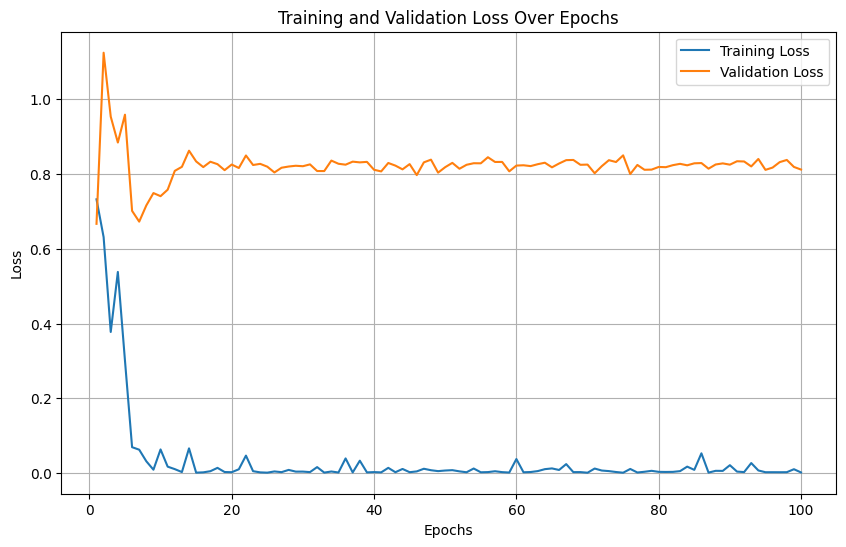

In [56]:
os.makedirs("results_100_epochs_lesion_normal/models", exist_ok=True)
save_path = "results_100_epochs_lesion_normal/models/InceptionAttNet.pth"

# Train the model
model = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=step_lr_scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    num_epochs=100,
    save_path=save_path
)

## Evaluate

### Internal Test

Model weights loaded from results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Evaluating the model...
dataset.class_to_idx = {'Normal': 0, 'Lesion': 1}
class_names          = ['Normal', 'Lesion']
Test set: 35 Lesion (positive), 35 Normal (negative)
[warn] 100% recall requires t < 0.01 (lowest positive-class probability = 0.007781). Falling back to Youden's J.

Threshold rule: Youden's J (100% recall unreachable above 0.00)
Selected threshold: 0.2800
Image: Lesion 1.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 10.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 11.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 12.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 13.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 14.png, Pred(Default) = Lesion, Pred(Adj) = Lesion, Actual = Lesion
Image: Lesion 15.png, Pred(Default) = Lesion, P

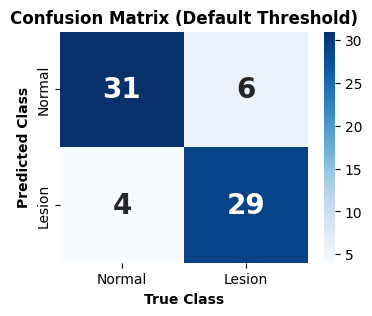


Model Evaluation (Adjusted Threshold = 0.2800, rule: Youden's J (100% recall unreachable above 0.00)):
Adjusted Accuracy: 0.8714
Adjusted Precision: 0.8421
Adjusted Recall (Sensitivity): 0.9143  [95% CI 0.7762-0.9704, n=35]
Adjusted Specificity: 0.8286  [95% CI 0.6732-0.9190, n=35]
Adjusted F1-Score: 0.8767

Adjusted Confusion Matrix (rows = predicted, cols = true):
[[29  3]
 [ 6 32]]

Default vs Adjusted:
  Sensitivity: 0.8286 -> 0.9143
  Specificity: 0.8857 -> 0.8286


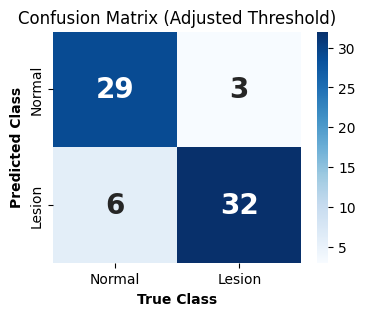

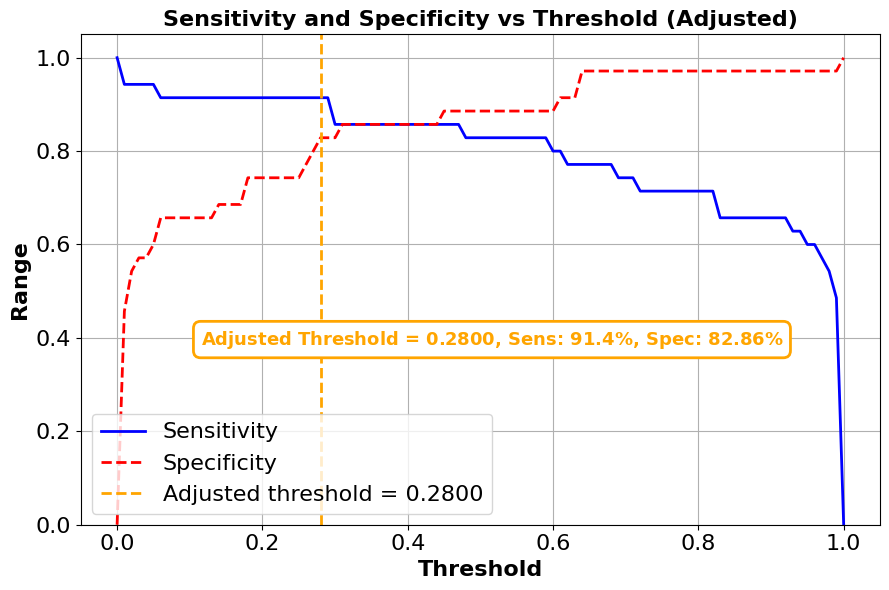


Saved ROC data to: results_100_epochs_lesion_normal/internal_test/json/InceptionAttNet


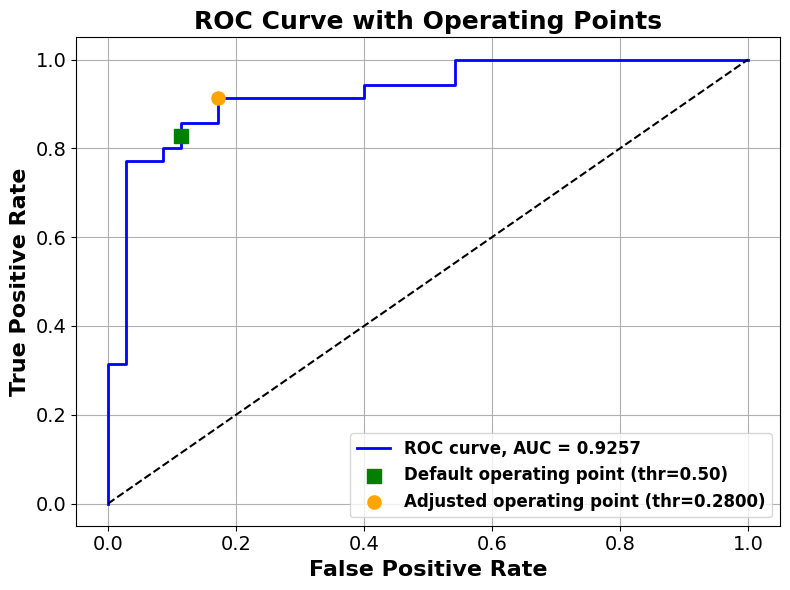

Saved 50 Grad-CAM images so far...

Done. Saved 70 Grad-CAM images to: results_100_epochs_lesion_normal/internal_test/gradcam/InceptionAttNet/


In [30]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/InceptionAttNet.pth"
model = load_model_weights(model, weight_path, device)

model = clear_all_hooks(model)

print("Evaluating the model...")
evaluate_model(model, dataloaders["internal_test"], class_names, "internal_test", device, roc_params_file="InceptionAttNet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["internal_test"],
    class_names=class_names,
    device=device,
    target_layer=model.pool,
    hook_input=True,          # ← quan trọng: bắt input, không phải output
    save_dir="results_100_epochs_lesion_normal/internal_test/gradcam/InceptionAttNet/"
)

### External Test

Model weights loaded from results_100_epochs_lesion_normal/models/InceptionAttNet.pth
Evaluating the model...
Image: fastMRI_breast_001_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_004_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_005_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_006_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_007_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_008_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_009_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_010_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_011_MIP.png, Pred(Default) = Normal, Pred(Adj) = Lesion, Actual = Lesion
Image: fastMRI_breast_013_MIP.png, 

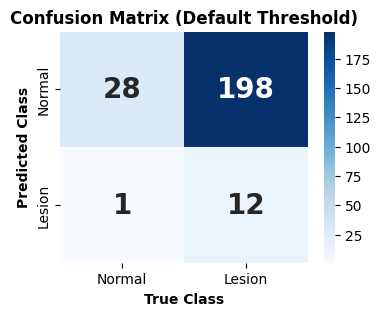


Adjusted Threshold (100% Recall): 0.0000

Adjusted Accuracy: 0.8787
Adjusted Precision: 0.8787
Adjusted Recall: 1.0000
Adjusted F1-Score: 0.9354

Adjusted Confusion Matrix:
[[  0   0]
 [ 29 210]]


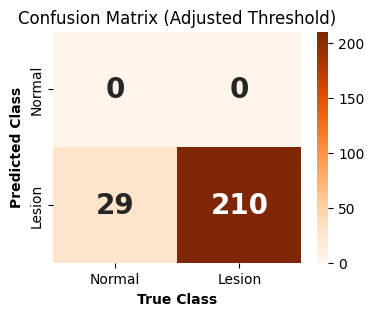

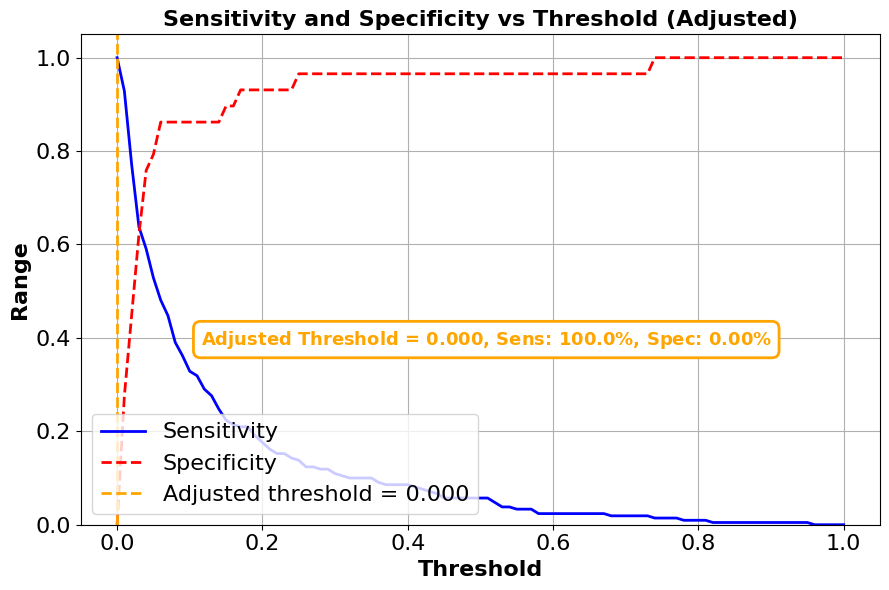


Saved ROC data to: results_100_epochs_lesion_normal/json/InceptionAttNet.json


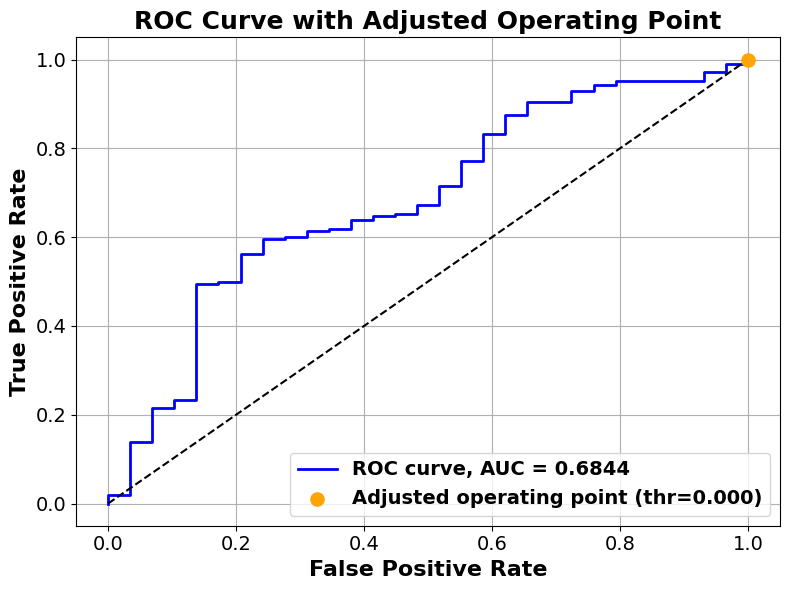

Saved 50 Grad-CAM images so far...
Saved 100 Grad-CAM images so far...
Saved 150 Grad-CAM images so far...
Saved 200 Grad-CAM images so far...

Done. Saved 239 Grad-CAM images to: results_100_epochs_lesion_normal/external_test/gradcam/InceptionAttNet/


In [217]:
model = clear_all_hooks(model)
# Load the saved weights
weight_path = "results_100_epochs_lesion_normal/models/InceptionAttNet.pth"
model = load_model_weights(model, weight_path, device)

model = clear_all_hooks(model)

print("Evaluating the model...")
evaluate_model(model, dataloaders["external_test"], class_names, "external_test", device, roc_params_file="InceptionAttNet")

run_gradcam_all(
    model=model,
    dataloader=dataloaders["external_test"],
    class_names=class_names,
    device=device,
    target_layer=model.pool,
    hook_input=True,        
    save_dir="results_100_epochs_lesion_normal/external_test/gradcam/InceptionAttNet/"
)

# Final ROC

### ROC Internal dataset

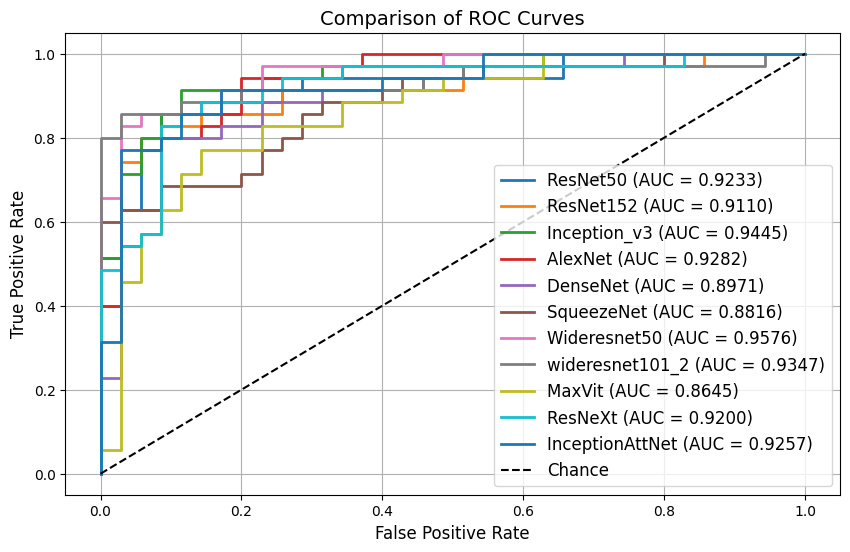

In [103]:
def load_roc_data(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)
    return {
        "fpr": data["fpr"],
        "tpr": data["tpr"],
        "roc_auc": data["roc_auc"]
    }

def compare_roc_curves():

    # Paths to the JSON files
    resnet50_file = "results_100_epochs_lesion_normal/internal_test/json/resnet50"
    resnet152_file = "results_100_epochs_lesion_normal/internal_test/json/resnet152"
    inception_file = "results_100_epochs_lesion_normal/internal_test/json/inception_v3"
    alexnet_file = "results_100_epochs_lesion_normal/internal_test/json/alexnet"
    densenet_file = "results_100_epochs_lesion_normal/internal_test/json/densenet"
    squeezenet_file = "results_100_epochs_lesion_normal/internal_test/json/squeezenet"
    wideresnet50_file = "results_100_epochs_lesion_normal/internal_test/json/wideresnet50"
    wideresnet101_2_file = "results_100_epochs_lesion_normal/internal_test/json/wideresnet101"
    maxvit_file = "results_100_epochs_lesion_normal/internal_test/json/MaxVit"
    resnext_file = "results_100_epochs_lesion_normal/internal_test/json/ResNeXt"
    inceptionAttNet_file = "results_100_epochs_lesion_normal/internal_test/json/InceptionAttNet"
    
    # Load ROC data
    resnet50_roc = load_roc_data(resnet50_file)
    resnet152_roc = load_roc_data(resnet152_file)
    inception_roc = load_roc_data(inception_file)
    alexnet_roc = load_roc_data(alexnet_file)
    densenet_roc = load_roc_data(densenet_file)
    squeezenet_roc = load_roc_data(squeezenet_file)
    wideresnet50_roc = load_roc_data(wideresnet50_file)
    wideresnet101_2_roc = load_roc_data(wideresnet101_2_file)
    maxvit_roc = load_roc_data(maxvit_file)
    resnext_roc = load_roc_data(resnext_file)
    inceptionAttNet_roc = load_roc_data(inceptionAttNet_file)
    
    # Plot ROC curves
    plt.figure(figsize=(10, 6))
    plt.plot(resnet50_roc["fpr"], resnet50_roc["tpr"], label=f"ResNet50 (AUC = {resnet50_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(resnet152_roc["fpr"], resnet152_roc["tpr"], label=f"ResNet152 (AUC = {resnet152_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(inception_roc["fpr"], inception_roc["tpr"], label=f"Inception_v3 (AUC = {inception_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(alexnet_roc["fpr"], alexnet_roc["tpr"], label=f"AlexNet (AUC = {alexnet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(densenet_roc["fpr"], densenet_roc["tpr"], label=f"DenseNet (AUC = {densenet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(squeezenet_roc["fpr"], squeezenet_roc["tpr"], label=f"SqueezeNet (AUC = {squeezenet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(wideresnet50_roc["fpr"], wideresnet50_roc["tpr"], label=f"Wideresnet50 (AUC = {wideresnet50_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(wideresnet101_2_roc["fpr"], wideresnet101_2_roc["tpr"], label=f"wideresnet101_2 (AUC = {wideresnet101_2_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(maxvit_roc["fpr"], maxvit_roc["tpr"], label=f"MaxVit (AUC = {maxvit_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(resnext_roc["fpr"], resnext_roc["tpr"], label=f"ResNeXt (AUC = {resnext_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(inceptionAttNet_roc["fpr"], inceptionAttNet_roc["tpr"], label=f"InceptionAttNet (AUC = {inceptionAttNet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    
    # Add labels and legend
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("Comparison of ROC Curves", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.show()

# Compare and visualize ROC curves
compare_roc_curves()

### ROC External dataset

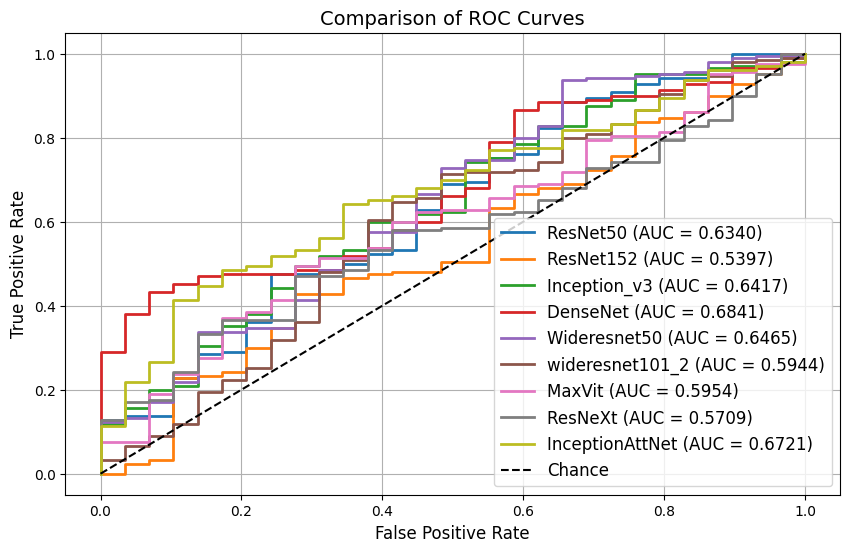

In [111]:
def load_roc_data(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)
    return {
        "fpr": data["fpr"],
        "tpr": data["tpr"],
        "roc_auc": data["roc_auc"]
    }

def compare_roc_curves():
    # Paths to the JSON files
    resnet50_file = "results_100_epochs_lesion_normal/external_test/json/resnet50"
    resnet152_file = "results_100_epochs_lesion_normal/external_test/json/resnet152"
    inception_file = "results_100_epochs_lesion_normal/external_test/json/inception_v3"
    alexnet_file = "results_100_epochs_lesion_normal/external_test/json/alexnet"
    densenet_file = "results_100_epochs_lesion_normal/external_test/json/densenet"
    squeezenet_file = "results_100_epochs_lesion_normal/external_test/json/squeezenet"
    wideresnet50_file = "results_100_epochs_lesion_normal/external_test/json/wideresnet50"
    wideresnet101_2_file = "results_100_epochs_lesion_normal/external_test/json/wideresnet101"
    maxvit_file = "results_100_epochs_lesion_normal/external_test/json/MaxVit"
    resnext_file = "results_100_epochs_lesion_normal/external_test/json/ResNeXt"
    inceptionAttNet_file = "results_100_epochs_lesion_normal/external_test/json/InceptionAttNet"
    
    # Load ROC data
    resnet50_roc = load_roc_data(resnet50_file)
    resnet152_roc = load_roc_data(resnet152_file)
    inception_roc = load_roc_data(inception_file)
    alexnet_roc = load_roc_data(alexnet_file)
    densenet_roc = load_roc_data(densenet_file)
    squeezenet_roc = load_roc_data(squeezenet_file)
    wideresnet50_roc = load_roc_data(wideresnet50_file)
    wideresnet101_2_roc = load_roc_data(wideresnet101_2_file)
    maxvit_roc = load_roc_data(maxvit_file)
    resnext_roc = load_roc_data(resnext_file)
    inceptionAttNet_roc = load_roc_data(inceptionAttNet_file)
    
    # Plot ROC curves
    plt.figure(figsize=(10, 6))
    plt.plot(resnet50_roc["fpr"], resnet50_roc["tpr"], label=f"ResNet50 (AUC = {resnet50_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(resnet152_roc["fpr"], resnet152_roc["tpr"], label=f"ResNet152 (AUC = {resnet152_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(inception_roc["fpr"], inception_roc["tpr"], label=f"Inception_v3 (AUC = {inception_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(densenet_roc["fpr"], densenet_roc["tpr"], label=f"DenseNet (AUC = {densenet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(wideresnet50_roc["fpr"], wideresnet50_roc["tpr"], label=f"Wideresnet50 (AUC = {wideresnet50_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(wideresnet101_2_roc["fpr"], wideresnet101_2_roc["tpr"], label=f"wideresnet101_2 (AUC = {wideresnet101_2_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(maxvit_roc["fpr"], maxvit_roc["tpr"], label=f"MaxVit (AUC = {maxvit_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(resnext_roc["fpr"], resnext_roc["tpr"], label=f"ResNeXt (AUC = {resnext_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot(inceptionAttNet_roc["fpr"], inceptionAttNet_roc["tpr"], label=f"InceptionAttNet (AUC = {inceptionAttNet_roc['roc_auc']:.4f})", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    
    # Add labels and legend
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("Comparison of ROC Curves", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.show()

# Compare and visualize ROC curves
compare_roc_curves()

## Comparision

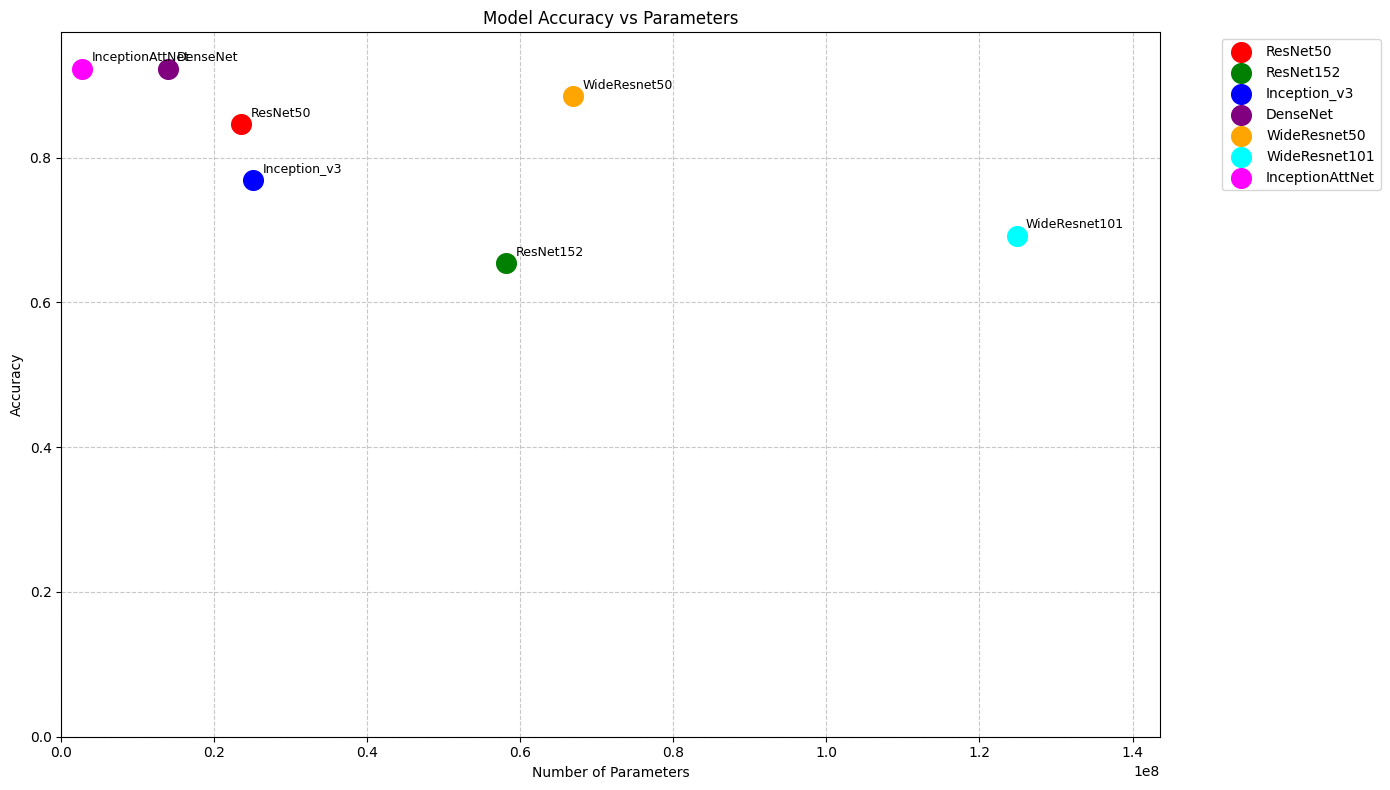

In [112]:
import matplotlib.pyplot as plt

# Data for the models
models = ['ResNet50', 'ResNet152', 'Inception_v3', 'DenseNet', 'WideResnet50', 'WideResnet101', 'InceptionAttNet',]
accuracy = [0.8462, 0.6538, 0.7692, 0.9231, 0.8846, 0.6923, 0.9231]  # Accuracy of each model
parameters = [23512130, 58147906, 25116362, 13889146, 66838338, 124841794, 2677692]  # Number of parameters in each model

# Colors to ensure all models have unique colors
colors = ['red', 'green', 'blue', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

# Plotting the data as a scatter plot
plt.figure(figsize=(14, 8))  # Increased chart size for better label visibility

# Scatter plot for models
for i, model in enumerate(models):
    plt.scatter(parameters[i], accuracy[i], color=colors[i], s=200, label=model)
    # Offset label for better visibility
    x_offset = 0.01 * max(parameters)
    y_offset = 0.01
    plt.text(parameters[i] + x_offset, accuracy[i] + y_offset, model, fontsize=9, ha='left')

# Set axis limits
plt.ylim(0, max(accuracy) + 0.05)
plt.xlim(0, max(parameters) + max(parameters) * 0.15)

# Set plot labels and title
plt.xlabel('Number of Parameters')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Parameters')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position

# Final layout
plt.tight_layout()
plt.show()

### Delong Test

#### Internal Delong Test

In [113]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# ------------------------------------------------------------------ #
DATA_DIR  = f'results_100_epochs_lesion_normal/internal_test/json'   # folder holding the per-model JSON files
REFERENCE = "InceptionAttNet"          # model everything is compared against

LABEL_KEY = "labels"
SCORE_KEY = "probabilities"            # continuous scores, NOT binarised predictions
ALPHA     = 0.05
# ------------------------------------------------------------------ #

In [114]:
def compute_midrank(x):
    """Mid-ranks of x, averaging ranks within each group of ties."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def fast_delong(scores_sorted, m):
    """
    Parameters
    ----------
    scores_sorted : (k, n_samples) array, columns ordered positives first
    m             : number of positive samples

    Returns
    -------
    aucs : (k,)   empirical AUCs
    cov  : (k, k) DeLong covariance matrix of those AUCs
    """
    n = scores_sorted.shape[1] - m
    positive = scores_sorted[:, :m]
    negative = scores_sorted[:, m:]
    k = scores_sorted.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive[r, :])
        ty[r, :] = compute_midrank(negative[r, :])
        tz[r, :] = compute_midrank(scores_sorted[r, :])

    # Mann-Whitney U form of the empirical AUC
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n

    # structural components (placement values)
    v01 = (tz[:, :m] - tx[:, :]) / n          # positives
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m    # negatives

    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)

In [115]:
def delong_roc_test(y_true, score_a, score_b):
    """Paired DeLong comparison of two correlated ROC curves on the same cases."""
    y_true = np.asarray(y_true).astype(int)
    m = int(y_true.sum())
    if m == 0 or m == len(y_true):
        raise ValueError("y_true must contain both classes.")

    order  = (-y_true).argsort(kind="mergesort")   # positives first, stable
    scores = np.vstack([np.asarray(score_a, dtype=float),
                        np.asarray(score_b, dtype=float)])[:, order]

    aucs, cov = fast_delong(scores, m)

    var_delta = cov[0, 0] + cov[1, 1] - 2.0 * cov[0, 1]
    se_delta  = float(np.sqrt(max(var_delta, 0.0)))
    delta     = float(aucs[0] - aucs[1])
    zc        = stats.norm.ppf(1 - ALPHA / 2)

    if se_delta == 0.0:
        z = 0.0 if delta == 0.0 else np.inf * np.sign(delta)
        p = 1.0 if delta == 0.0 else 0.0
    else:
        z = delta / se_delta
        p = 2.0 * stats.norm.sf(abs(z))

    return {
        "auc_a": float(aucs[0]), "se_a": float(np.sqrt(cov[0, 0])),
        "auc_b": float(aucs[1]), "se_b": float(np.sqrt(cov[1, 1])),
        "delta_auc": delta, "se_delta": se_delta,
        "ci_low":  delta - zc * se_delta,
        "ci_high": delta + zc * se_delta,
        "z": float(z), "p": float(p),
    }


def auc_ci(auc, se, alpha=ALPHA):
    """Wald CI for a single AUC, clipped to [0, 1]."""
    zc = stats.norm.ppf(1 - alpha / 2)
    return max(0.0, auc - zc * se), min(1.0, auc + zc * se)


def holm_bonferroni(pvals):
    """Holm step-down adjusted p-values (controls family-wise error rate)."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    adj = np.empty(n, dtype=float)
    running = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, (n - rank) * p[idx])
        adj[idx] = min(1.0, running)
    return adj

In [116]:
def load_model_json(path):
    with open(path, "r") as f:
        d = json.load(f)
    if LABEL_KEY not in d or SCORE_KEY not in d:
        raise KeyError(f"missing '{LABEL_KEY}' or '{SCORE_KEY}'")
    y = np.asarray(d[LABEL_KEY], dtype=int)
    s = np.asarray(d[SCORE_KEY], dtype=float)
    if s.ndim == 2:                      # (n, 2) softmax -> keep positive class
        s = s[:, 1]
    if len(y) != len(s):
        raise ValueError(f"{len(y)} labels vs {len(s)} scores")
    return y, s


def load_all(data_dir):
    models = {}
    for name in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, name)
        if not os.path.isfile(path):
            continue
        try:
            models[os.path.splitext(name)[0]] = load_model_json(path)
        except (json.JSONDecodeError, KeyError, ValueError, UnicodeDecodeError) as e:
            print(f"  [skip] {name}: {e}")
    return models


models = load_all(DATA_DIR)
print(f"Loaded {len(models)} models: {', '.join(sorted(models))}")

Loaded 12 models: InceptionAttNet, MNASNet, MaxVit, ResNeXt, alexnet, densenet, inception_v3, resnet152, resnet50, squeezenet, wideresnet101, wideresnet50


In [117]:
y_ref, s_ref = models[REFERENCE]

# 1) paired design
mismatched = [n for n, (y, _) in models.items() if not np.array_equal(y, y_ref)]
assert not mismatched, f"Label vectors differ from {REFERENCE}: {mismatched}"

# 2) scores must be continuous, not binarised
binarised = [n for n, (_, s) in models.items() if len(np.unique(s)) <= 2]
if binarised:
    print(f"WARNING - these look thresholded, not continuous: {binarised}")

n_pos, n_neg = int(y_ref.sum()), int((1 - y_ref).sum())
print(f"Paired test set: n = {len(y_ref)}  (positive = {n_pos}, negative = {n_neg})")
print(f"Reference model: {REFERENCE}")
print(f"Comparisons to run: {len(models) - 1}")

Paired test set: n = 70  (positive = 35, negative = 35)
Reference model: InceptionAttNet
Comparisons to run: 11


In [118]:
rows = []
for name, (_, s_other) in models.items():
    if name == REFERENCE:
        continue
    r = delong_roc_test(y_ref, s_ref, s_other)
    lo_a, hi_a = auc_ci(r["auc_a"], r["se_a"])
    lo_b, hi_b = auc_ci(r["auc_b"], r["se_b"])
    rows.append({
        "Model": name,
        f"AUC_{REFERENCE}": r["auc_a"],
        f"CI_{REFERENCE}": f"[{lo_a:.3f}, {hi_a:.3f}]",
        "AUC_comparator": r["auc_b"],
        "CI_comparator": f"[{lo_b:.3f}, {hi_b:.3f}]",
        "Delta_AUC": r["delta_auc"],
        "SE_Delta": r["se_delta"],
        "CI_Delta": f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
        "ci_low": r["ci_low"], "ci_high": r["ci_high"],
        "z": r["z"], "p": r["p"],
    })

df = pd.DataFrame(rows).sort_values("AUC_comparator", ascending=False).reset_index(drop=True)
df["p_Bonferroni"] = np.minimum(1.0, df["p"] * len(df))
df["p_Holm"]       = holm_bonferroni(df["p"].values)
df["Significant"]  = np.where(df["p_Holm"] < ALPHA, "yes", "no")

df

,Model,AUC_InceptionAttNet,CI_InceptionAttNet,AUC_comparator,CI_comparator,Delta_AUC,SE_Delta,CI_Delta,ci_low,ci_high,z,p,p_Bonferroni,p_Holm,Significant
0,wideresnet50,0.930612,"[0.874, 0.987]",0.957551,"[0.917, 0.998]",-0.026939,0.017250,"[-0.061, 0.007]",-0.060748,0.006871,-1.561669,1.183661e-01,1.000000e+00,9.469285e-01,no
1,inception_v3,0.930612,"[0.874, 0.987]",0.944490,"[0.893, 0.996]",-0.013878,0.017363,"[-0.048, 0.020]",-0.047909,0.020154,-0.799249,4.241462e-01,1.000000e+00,1.000000e+00,no
2,alexnet,0.930612,"[0.874, 0.987]",0.928163,"[0.871, 0.986]",0.002449,0.019094,"[-0.035, 0.040]",-0.034975,0.039873,0.128257,8.979456e-01,1.000000e+00,1.000000e+00,no
3,wideresnet101,0.930612,"[0.874, 0.987]",0.923265,"[0.857, 0.989]",0.007347,0.025086,"[-0.042, 0.057]",-0.041821,0.056515,0.292870,7.696213e-01,1.000000e+00,1.000000e+00,no
4,resnet50,0.930612,"[0.874, 0.987]",0.923265,"[0.860, 0.987]",0.007347,0.028128,"[-0.048, 0.062]",-0.047783,0.062477,0.261194,7.939428e-01,1.000000e+00,1.000000e+00,no
5,ResNeXt,0.930612,"[0.874, 0.987]",0.923265,"[0.863, 0.983]",0.007347,0.020546,"[-0.033, 0.048]",-0.032922,0.047616,0.357585,7.206539e-01,1.000000e+00,1.000000e+00,no
6,resnet152,0.930612,"[0.874, 0.987]",0.911020,"[0.839, 0.983]",0.019592,0.023906,"[-0.027, 0.066]",-0.027263,0.066446,0.819543,4.124766e-01,1.000000e+00,1.000000e+00,no
7,densenet,0.930612,"[0.874, 0.987]",0.897143,"[0.822, 0.972]",0.033469,0.030091,"[-0.026, 0.092]",-0.025508,0.092447,1.112274,2.660204e-01,1.000000e+00,1.000000e+00,no
8,squeezenet,0.930612,"[0.874, 0.987]",0.881633,"[0.804, 0.959]",0.048980,0.024768,"[0.000, 0.098]",0.000435,0.097525,1.977509,4.798409e-02,5.278250e-01,4.798409e-01,no
9,MaxVit,0.930612,"[0.874, 0.987]",0.864490,"[0.778, 0.951]",0.066122,0.039540,"[-0.011, 0.144]",-0.011375,0.143620,1.672284,9.446826e-02,1.000000e+00,8.502144e-01,no


In [119]:
def fmt_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

table = pd.DataFrame({
    "Model":            df["Model"],
    "AUC (95% CI)":     df["AUC_comparator"].map("{:.3f}".format) + " " + df["CI_comparator"],
    "ΔAUC (95% CI)":    df["Delta_AUC"].map("{:+.3f}".format) + " " + df["CI_Delta"],
    "z":                df["z"].map("{:.3f}".format),
    "p":                df["p"].map(fmt_p),
    "p (Holm)":         df["p_Holm"].map(fmt_p),
    "Sig.":             df["Significant"],
})

ref_auc = df[f"AUC_{REFERENCE}"].iloc[0]
ref_ci  = df[f"CI_{REFERENCE}"].iloc[0]
print(f"{REFERENCE}: AUC = {ref_auc:.3f} {ref_ci}\n")
print(table.to_string(index=False))

InceptionAttNet: AUC = 0.931 [0.874, 0.987]

        Model         AUC (95% CI)          ΔAUC (95% CI)      z      p p (Holm) Sig.
 wideresnet50 0.958 [0.917, 0.998] -0.027 [-0.061, 0.007] -1.562  0.118    0.947   no
 inception_v3 0.944 [0.893, 0.996] -0.014 [-0.048, 0.020] -0.799  0.424    1.000   no
      alexnet 0.928 [0.871, 0.986] +0.002 [-0.035, 0.040]  0.128  0.898    1.000   no
wideresnet101 0.923 [0.857, 0.989] +0.007 [-0.042, 0.057]  0.293  0.770    1.000   no
     resnet50 0.923 [0.860, 0.987] +0.007 [-0.048, 0.062]  0.261  0.794    1.000   no
      ResNeXt 0.923 [0.863, 0.983] +0.007 [-0.033, 0.048]  0.358  0.721    1.000   no
    resnet152 0.911 [0.839, 0.983] +0.020 [-0.027, 0.066]  0.820  0.412    1.000   no
     densenet 0.897 [0.822, 0.972] +0.033 [-0.026, 0.092]  1.112  0.266    1.000   no
   squeezenet 0.882 [0.804, 0.959]  +0.049 [0.000, 0.098]  1.978  0.048    0.480   no
       MaxVit 0.864 [0.778, 0.951] +0.066 [-0.011, 0.144]  1.672  0.094    0.850   no
      MNA

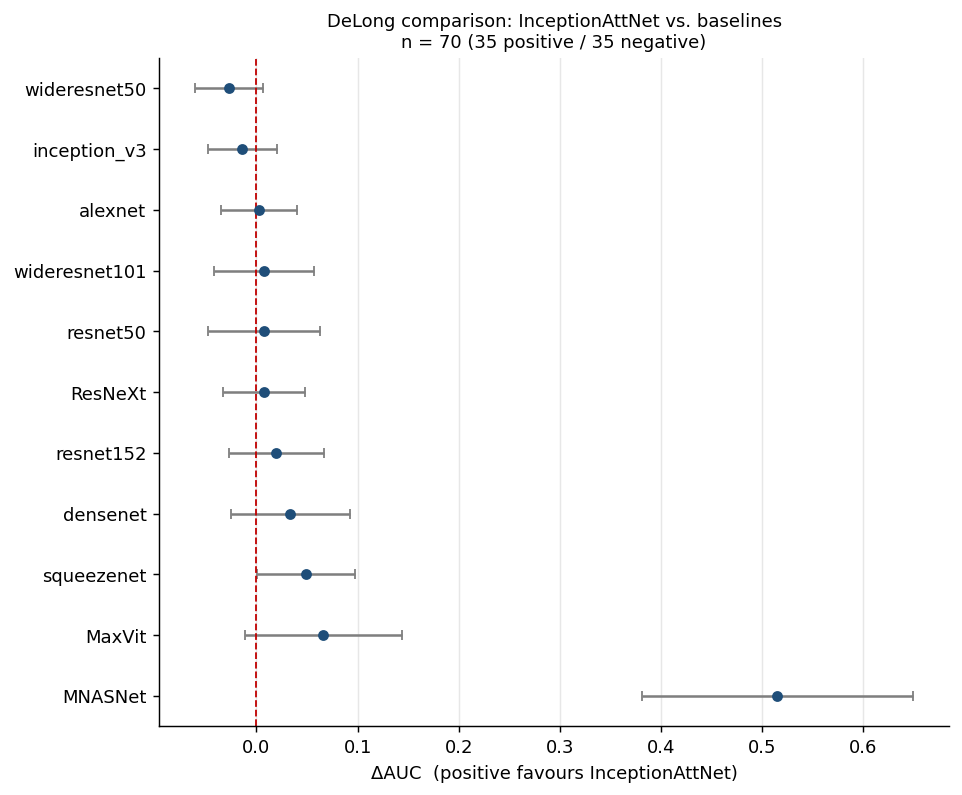

In [120]:
fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(df) + 1.6), dpi=130)
ypos = np.arange(len(df))[::-1]

ax.errorbar(df["Delta_AUC"], ypos,
            xerr=[df["Delta_AUC"] - df["ci_low"], df["ci_high"] - df["Delta_AUC"]],
            fmt="o", ms=5, lw=1.4, capsize=3, color="#1f4e79", ecolor="#7f7f7f")
ax.axvline(0, ls="--", lw=1, color="#c00000")

ax.set_yticks(ypos)
ax.set_yticklabels(df["Model"])
ax.set_xlabel(f"ΔAUC  (positive favours {REFERENCE})")
ax.set_title(f"DeLong comparison: {REFERENCE} vs. baselines\n"
             f"n = {len(y_ref)} ({n_pos} positive / {n_neg} negative)", fontsize=10)
ax.grid(axis="x", alpha=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig("delong_forest.png", dpi=300, bbox_inches="tight")
plt.show()

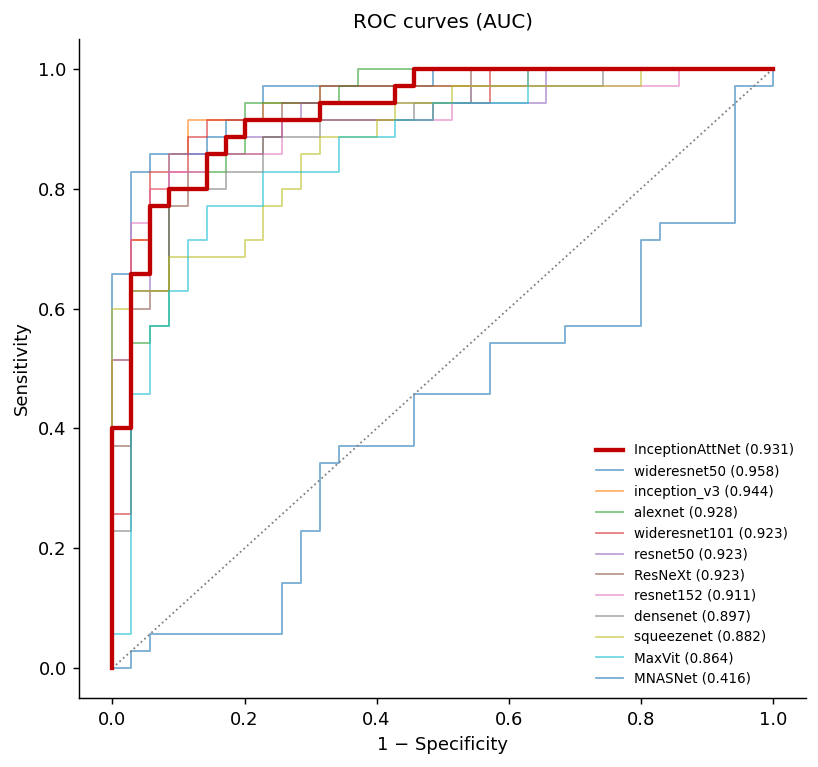

In [121]:
fig, ax = plt.subplots(figsize=(6.4, 6.0), dpi=130)

for name in [REFERENCE] + list(df["Model"]):
    _, s = models[name]
    fpr, tpr, _ = roc_curve(y_ref, s)
    is_ref = name == REFERENCE
    auc_v  = ref_auc if is_ref else df.loc[df["Model"] == name, "AUC_comparator"].iloc[0]
    ax.plot(fpr, tpr,
            lw=2.4 if is_ref else 1.0,
            color="#c00000" if is_ref else None,
            alpha=1.0 if is_ref else 0.6,
            zorder=3 if is_ref else 2,
            label=f"{name} ({auc_v:.3f})")

ax.plot([0, 1], [0, 1], ls=":", lw=1, color="grey")
ax.set_xlabel("1 − Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC curves (AUC)", fontsize=11)
ax.legend(fontsize=7.5, loc="lower right", frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

In [122]:
# --- p-value annotation to the right of each interval ---
P_COL = "p_Holm"            # switch to "p" to annotate the unadjusted values
xmax = float(df["ci_high"].max())
pad  = 0.06 * (xmax - float(df["ci_low"].min()))
ax.set_xlim(right=xmax + 5.5 * pad)

for y, (_, row) in zip(ypos, df.iterrows()):
    star = "*" if row[P_COL] < ALPHA else ""
    txt  = "p < 0.001" if row[P_COL] < 0.001 else f"p = {row[P_COL]:.3f}"
    ax.text(xmax + pad, y, txt + star,
            va="center", ha="left", fontsize=8.5,
            color="#1f4e79" if row[P_COL] < ALPHA else "#555555")

ax.text(xmax + pad, len(df) - 0.35,
        f"{'Holm-adjusted' if P_COL == 'p_Holm' else 'unadjusted'} p",
        va="center", ha="left", fontsize=8, style="italic", color="#555555")

Text(0.6919433091502526, 10.65, 'Holm-adjusted p')

In [123]:
df.to_csv("delong_internal_results.csv", index=False)
table.to_csv("delong_internal_table_formatted.csv", index=False)

try:
    with pd.ExcelWriter("delong_internal_results.xlsx", engine="openpyxl") as xl:
        df.to_excel(xl, sheet_name="full", index=False)
        table.to_excel(xl, sheet_name="manuscript", index=False)
    print("Wrote: delong_internal_results.csv, delong_internal_table_formatted.csv, delong_internal_results.xlsx")
except ImportError:
    print("Wrote: delong_internal_results.csv, delong_internal_table_formatted.csv  (openpyxl missing, skipped .xlsx)")

Wrote: delong_internal_results.csv, delong_internal_table_formatted.csv, delong_internal_results.xlsx


#### External Delong Test

In [124]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# ------------------------------------------------------------------ #
DATA_DIR  = f'results_100_epochs_lesion_normal/external_test/json'   # folder holding the per-model JSON files
REFERENCE = "InceptionAttNet"          # model everything is compared against

LABEL_KEY = "labels"
SCORE_KEY = "probabilities"            # continuous scores, NOT binarised predictions
ALPHA     = 0.05
# ------------------------------------------------------------------ #

In [125]:
def compute_midrank(x):
    """Mid-ranks of x, averaging ranks within each group of ties."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def fast_delong(scores_sorted, m):
    """
    Parameters
    ----------
    scores_sorted : (k, n_samples) array, columns ordered positives first
    m             : number of positive samples

    Returns
    -------
    aucs : (k,)   empirical AUCs
    cov  : (k, k) DeLong covariance matrix of those AUCs
    """
    n = scores_sorted.shape[1] - m
    positive = scores_sorted[:, :m]
    negative = scores_sorted[:, m:]
    k = scores_sorted.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive[r, :])
        ty[r, :] = compute_midrank(negative[r, :])
        tz[r, :] = compute_midrank(scores_sorted[r, :])

    # Mann-Whitney U form of the empirical AUC
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n

    # structural components (placement values)
    v01 = (tz[:, :m] - tx[:, :]) / n          # positives
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m    # negatives

    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)

In [126]:
def delong_roc_test(y_true, score_a, score_b):
    """Paired DeLong comparison of two correlated ROC curves on the same cases."""
    y_true = np.asarray(y_true).astype(int)
    m = int(y_true.sum())
    if m == 0 or m == len(y_true):
        raise ValueError("y_true must contain both classes.")

    order  = (-y_true).argsort(kind="mergesort")   # positives first, stable
    scores = np.vstack([np.asarray(score_a, dtype=float),
                        np.asarray(score_b, dtype=float)])[:, order]

    aucs, cov = fast_delong(scores, m)

    var_delta = cov[0, 0] + cov[1, 1] - 2.0 * cov[0, 1]
    se_delta  = float(np.sqrt(max(var_delta, 0.0)))
    delta     = float(aucs[0] - aucs[1])
    zc        = stats.norm.ppf(1 - ALPHA / 2)

    if se_delta == 0.0:
        z = 0.0 if delta == 0.0 else np.inf * np.sign(delta)
        p = 1.0 if delta == 0.0 else 0.0
    else:
        z = delta / se_delta
        p = 2.0 * stats.norm.sf(abs(z))

    return {
        "auc_a": float(aucs[0]), "se_a": float(np.sqrt(cov[0, 0])),
        "auc_b": float(aucs[1]), "se_b": float(np.sqrt(cov[1, 1])),
        "delta_auc": delta, "se_delta": se_delta,
        "ci_low":  delta - zc * se_delta,
        "ci_high": delta + zc * se_delta,
        "z": float(z), "p": float(p),
    }


def auc_ci(auc, se, alpha=ALPHA):
    """Wald CI for a single AUC, clipped to [0, 1]."""
    zc = stats.norm.ppf(1 - alpha / 2)
    return max(0.0, auc - zc * se), min(1.0, auc + zc * se)


def holm_bonferroni(pvals):
    """Holm step-down adjusted p-values (controls family-wise error rate)."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    adj = np.empty(n, dtype=float)
    running = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, (n - rank) * p[idx])
        adj[idx] = min(1.0, running)
    return adj

In [127]:
def load_model_json(path):
    with open(path, "r") as f:
        d = json.load(f)
    if LABEL_KEY not in d or SCORE_KEY not in d:
        raise KeyError(f"missing '{LABEL_KEY}' or '{SCORE_KEY}'")
    y = np.asarray(d[LABEL_KEY], dtype=int)
    s = np.asarray(d[SCORE_KEY], dtype=float)
    if s.ndim == 2:                      # (n, 2) softmax -> keep positive class
        s = s[:, 1]
    if len(y) != len(s):
        raise ValueError(f"{len(y)} labels vs {len(s)} scores")
    return y, s


def load_all(data_dir):
    models = {}
    for name in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, name)
        if not os.path.isfile(path):
            continue
        try:
            models[os.path.splitext(name)[0]] = load_model_json(path)
        except (json.JSONDecodeError, KeyError, ValueError, UnicodeDecodeError) as e:
            print(f"  [skip] {name}: {e}")
    return models


models = load_all(DATA_DIR)
print(f"Loaded {len(models)} models: {', '.join(sorted(models))}")

Loaded 12 models: InceptionAttNet, MNASNet, MaxVit, ResNeXt, alexnet, densenet, inception_v3, resnet152, resnet50, squeezenet, wideresnet101, wideresnet50


In [128]:
y_ref, s_ref = models[REFERENCE]

# 1) paired design
mismatched = [n for n, (y, _) in models.items() if not np.array_equal(y, y_ref)]
assert not mismatched, f"Label vectors differ from {REFERENCE}: {mismatched}"

# 2) scores must be continuous, not binarised
binarised = [n for n, (_, s) in models.items() if len(np.unique(s)) <= 2]
if binarised:
    print(f"WARNING - these look thresholded, not continuous: {binarised}")

n_pos, n_neg = int(y_ref.sum()), int((1 - y_ref).sum())
print(f"Paired test set: n = {len(y_ref)}  (positive = {n_pos}, negative = {n_neg})")
print(f"Reference model: {REFERENCE}")
print(f"Comparisons to run: {len(models) - 1}")

Paired test set: n = 239  (positive = 210, negative = 29)
Reference model: InceptionAttNet
Comparisons to run: 11


In [129]:
rows = []
for name, (_, s_other) in models.items():
    if name == REFERENCE:
        continue
    r = delong_roc_test(y_ref, s_ref, s_other)
    lo_a, hi_a = auc_ci(r["auc_a"], r["se_a"])
    lo_b, hi_b = auc_ci(r["auc_b"], r["se_b"])
    rows.append({
        "Model": name,
        f"AUC_{REFERENCE}": r["auc_a"],
        f"CI_{REFERENCE}": f"[{lo_a:.3f}, {hi_a:.3f}]",
        "AUC_comparator": r["auc_b"],
        "CI_comparator": f"[{lo_b:.3f}, {hi_b:.3f}]",
        "Delta_AUC": r["delta_auc"],
        "SE_Delta": r["se_delta"],
        "CI_Delta": f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
        "ci_low": r["ci_low"], "ci_high": r["ci_high"],
        "z": r["z"], "p": r["p"],
    })

df = pd.DataFrame(rows).sort_values("AUC_comparator", ascending=False).reset_index(drop=True)
df["p_Bonferroni"] = np.minimum(1.0, df["p"] * len(df))
df["p_Holm"]       = holm_bonferroni(df["p"].values)
df["Significant"]  = np.where(df["p_Holm"] < ALPHA, "yes", "no")

df

,Model,AUC_InceptionAttNet,CI_InceptionAttNet,AUC_comparator,CI_comparator,Delta_AUC,SE_Delta,CI_Delta,ci_low,ci_high,z,p,p_Bonferroni,p_Holm,Significant
0,densenet,0.672085,"[0.578, 0.767]",0.684072,"[0.593, 0.775]",-0.011987,0.060327,"[-0.130, 0.106]",-0.130225,0.106251,-0.198700,0.842498,1.000000,1.000000,no
1,wideresnet50,0.672085,"[0.578, 0.767]",0.646470,"[0.532, 0.761]",0.025616,0.071794,"[-0.115, 0.166]",-0.115099,0.166330,0.356794,0.721246,1.000000,1.000000,no
2,inception_v3,0.672085,"[0.578, 0.767]",0.641708,"[0.533, 0.750]",0.030378,0.067008,"[-0.101, 0.162]",-0.100956,0.161711,0.453343,0.650302,1.000000,1.000000,no
3,resnet50,0.672085,"[0.578, 0.767]",0.633990,"[0.522, 0.746]",0.038095,0.075209,"[-0.109, 0.186]",-0.109313,0.185503,0.506522,0.612490,1.000000,1.000000,no
4,squeezenet,0.672085,"[0.578, 0.767]",0.600821,"[0.499, 0.702]",0.071264,0.065648,"[-0.057, 0.200]",-0.057403,0.199931,1.085559,0.277674,1.000000,1.000000,no
5,MaxVit,0.672085,"[0.578, 0.767]",0.595402,"[0.491, 0.699]",0.076683,0.069896,"[-0.060, 0.214]",-0.060310,0.213676,1.097110,0.272593,1.000000,1.000000,no
6,wideresnet101,0.672085,"[0.578, 0.767]",0.594417,"[0.475, 0.714]",0.077668,0.081491,"[-0.082, 0.237]",-0.082050,0.237387,0.953094,0.340542,1.000000,1.000000,no
7,alexnet,0.672085,"[0.578, 0.767]",0.573727,"[0.459, 0.688]",0.098358,0.076186,"[-0.051, 0.248]",-0.050963,0.247679,1.291030,0.196693,1.000000,1.000000,no
8,ResNeXt,0.672085,"[0.578, 0.767]",0.570936,"[0.474, 0.668]",0.101149,0.064140,"[-0.025, 0.227]",-0.024563,0.226862,1.577003,0.114795,1.000000,1.000000,no
9,MNASNet,0.672085,"[0.578, 0.767]",0.542200,"[0.429, 0.655]",0.129885,0.078170,"[-0.023, 0.283]",-0.023325,0.283095,1.661579,0.096597,1.000000,0.965972,no


In [130]:
def fmt_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

table = pd.DataFrame({
    "Model":            df["Model"],
    "AUC (95% CI)":     df["AUC_comparator"].map("{:.3f}".format) + " " + df["CI_comparator"],
    "ΔAUC (95% CI)":    df["Delta_AUC"].map("{:+.3f}".format) + " " + df["CI_Delta"],
    "z":                df["z"].map("{:.3f}".format),
    "p":                df["p"].map(fmt_p),
    "p (Holm)":         df["p_Holm"].map(fmt_p),
    "Sig.":             df["Significant"],
})

ref_auc = df[f"AUC_{REFERENCE}"].iloc[0]
ref_ci  = df[f"CI_{REFERENCE}"].iloc[0]
print(f"{REFERENCE}: AUC = {ref_auc:.3f} {ref_ci}\n")
print(table.to_string(index=False))

InceptionAttNet: AUC = 0.672 [0.578, 0.767]

        Model         AUC (95% CI)          ΔAUC (95% CI)      z     p p (Holm) Sig.
     densenet 0.684 [0.593, 0.775] -0.012 [-0.130, 0.106] -0.199 0.842    1.000   no
 wideresnet50 0.646 [0.532, 0.761] +0.026 [-0.115, 0.166]  0.357 0.721    1.000   no
 inception_v3 0.642 [0.533, 0.750] +0.030 [-0.101, 0.162]  0.453 0.650    1.000   no
     resnet50 0.634 [0.522, 0.746] +0.038 [-0.109, 0.186]  0.507 0.612    1.000   no
   squeezenet 0.601 [0.499, 0.702] +0.071 [-0.057, 0.200]  1.086 0.278    1.000   no
       MaxVit 0.595 [0.491, 0.699] +0.077 [-0.060, 0.214]  1.097 0.273    1.000   no
wideresnet101 0.594 [0.475, 0.714] +0.078 [-0.082, 0.237]  0.953 0.341    1.000   no
      alexnet 0.574 [0.459, 0.688] +0.098 [-0.051, 0.248]  1.291 0.197    1.000   no
      ResNeXt 0.571 [0.474, 0.668] +0.101 [-0.025, 0.227]  1.577 0.115    1.000   no
      MNASNet 0.542 [0.429, 0.655] +0.130 [-0.023, 0.283]  1.662 0.097    0.966   no
    resnet152 0.540 

In [131]:
df.to_csv("delong_external_results.csv", index=False)
table.to_csv("delong_external_table_formatted.csv", index=False)

try:
    with pd.ExcelWriter("delong_external_results.xlsx", engine="openpyxl") as xl:
        df.to_excel(xl, sheet_name="full", index=False)
        table.to_excel(xl, sheet_name="manuscript", index=False)
    print("Wrote: delong_external_results.csv, delong_external_table_formatted.csv, delong_external_results.xlsx")
except ImportError:
    print("Wrote: delong_external_results.csv, delong_external_table_formatted.csv  (openpyxl missing, skipped .xlsx)")

Wrote: delong_external_results.csv, delong_external_table_formatted.csv, delong_external_results.xlsx
